# **Project title:** Predicting expenditure of overseas travellers in Ireland using Regression Machine Learning Algorithms

### **Project Description**

This project aims to develop a predictive model that estimates travel expenditure based on the average number of nights and trips by foreign visitors in Ireland by using machine learning algorithm. The dataset is obtained from the Central Statistic Office of the Republic of Ireland. The link of dataset is avaliable [(here)](https://data.gov.ie/dataset/tmq09-overseas-trips-incl-expenditure-to-ireland).

### **Importing and loading required libraries, packages and dataset**

In [1568]:
#Data Analytics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

#Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LinearRegression
from sklearn import linear_model

#Statistics
from scipy.stats import binom
from scipy.stats import kurtosis


#To ignore warning
import warnings
warnings.filterwarnings("ignore")

#### **Importing Dataset: Description of Dataset**

The dataset contains the facts about quarterly expenditure, average length of stay, and number of trips in Ireland by non-residents from 2012 to 2019. The data is obtained from the Central Statistics Office of Ireland website.   

In [1570]:
#pandas.read_csv read the comma separated values 
oversea_trip = pd.read_csv('TMQ09.20250322224126.csv')

### **Exploratory Data Analysis**

#### *Inspection on original dataset*


In [1573]:
#.head()function loads the first few rows of the dataset
oversea_trip.head()

,C02173V02619,Area of Residence,TLIST(Q1),Quarter,STATISTIC,Statistic Label,UNIT,VALUE
0,-,All Countries,20121,2012Q1,TMQ09C1,Overseas Trips to Ireland by Non-Residents,Thousand,1167.0
1,-,All Countries,20121,2012Q1,TMQ09C2,Average Length of Stay by Overseas Travellers ...,Nights,6.8
2,-,All Countries,20121,2012Q1,TMQ09C3,Expenditure by Overseas Travellers in Ireland ...,Euro Million,483.0
3,-,All Countries,20122,2012Q2,TMQ09C1,Overseas Trips to Ireland by Non-Residents,Thousand,1817.0
4,-,All Countries,20122,2012Q2,TMQ09C2,Average Length of Stay by Overseas Travellers ...,Nights,7.0


.shape attribute shows the number of features and observations. There are total of 848 observations and 8 features in the dataset. 

In [1575]:
oversea_trip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   C02173V02619       864 non-null    object 
 1   Area of Residence  864 non-null    object 
 2   TLIST(Q1)          864 non-null    int64  
 3   Quarter            864 non-null    object 
 4   STATISTIC          864 non-null    object 
 5   Statistic Label    864 non-null    object 
 6   UNIT               864 non-null    object 
 7   VALUE              864 non-null    float64
dtypes: float64(1), int64(1), object(6)
memory usage: 54.1+ KB


.info() method prints the information of the dataframe. The information consists of the number of observations and features, data types, number of cells in each column, rangeindex and memory usage. According to the data, there are a total of 864 non-null values, five features with object data types, one with integer, and one with float. The data takes over 54KB of storage on the local drive. 

The columns this project will target are 'Area of Residence', 'Quarter', 'Statistic Label', 'UNIT', and 'VALUE'. All data types apart from the 'Quarter' feature are in the correct format and ready for analysis. 

In [1577]:
#Detecting null values
oversea_trip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 864 entries, 0 to 863
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   C02173V02619       864 non-null    object 
 1   Area of Residence  864 non-null    object 
 2   TLIST(Q1)          864 non-null    int64  
 3   Quarter            864 non-null    object 
 4   STATISTIC          864 non-null    object 
 5   Statistic Label    864 non-null    object 
 6   UNIT               864 non-null    object 
 7   VALUE              864 non-null    float64
dtypes: float64(1), int64(1), object(6)
memory usage: 54.1+ KB


#### *Checking missing values*

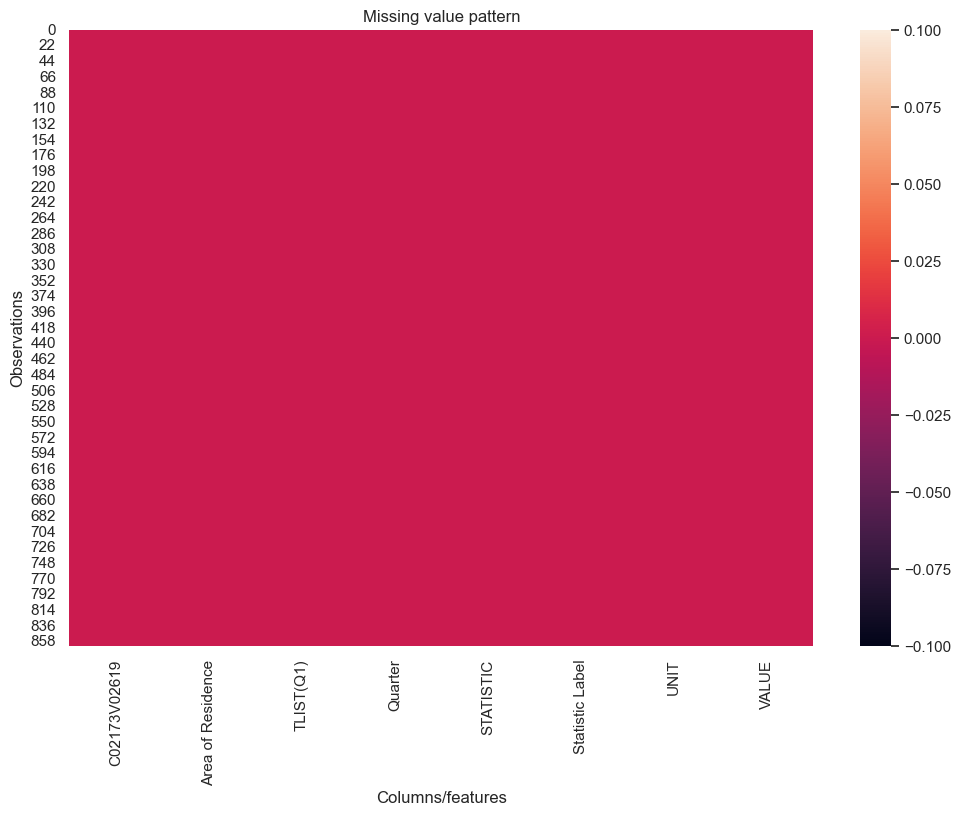

In [1580]:
plt.figure(figsize=(12,8))
sns.heatmap(oversea_trip.isnull())
plt.title('Missing value pattern')
plt.xlabel('Columns/features')
plt.ylabel('Observations')
plt.show()

**Interpretation**: One way to investigate a missing value pattern can be achieved by using the seaborn library's heatmap function.  X-axis shows each feature and Y-axis shows the ranges of records. The patterns were given -0.1 to 0.1 with 0 (red) being no record or patterns found.

#### *Checking duplicate observations*

In [1583]:
num_duplicates = oversea_trip[oversea_trip.duplicated()] 
num_duplicates

,C02173V02619,Area of Residence,TLIST(Q1),Quarter,STATISTIC,Statistic Label,UNIT,VALUE


Null values and duplicate values are not observed in the dataset. 

Text(0, 0.5, 'Count')

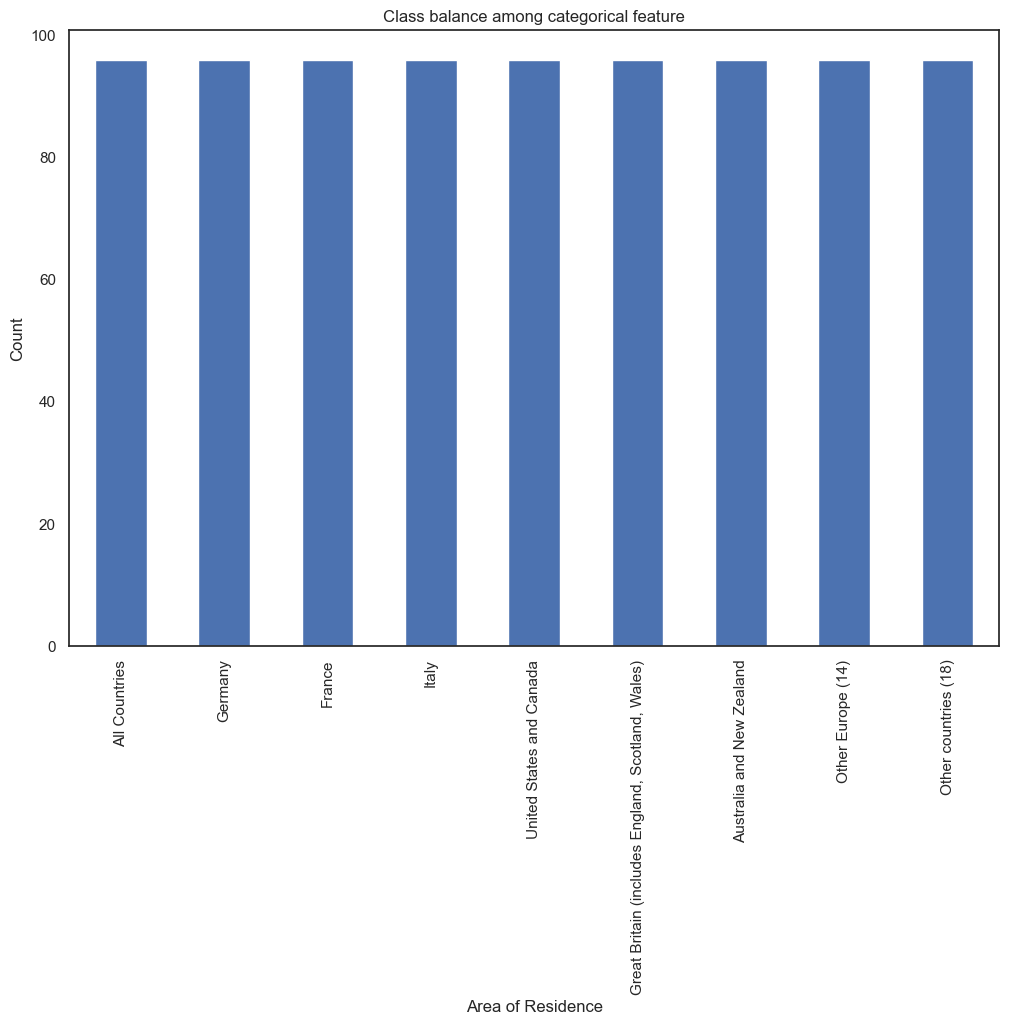

In [1585]:
plt.figure(figsize=(12,8))
oversea_trip['Area of Residence'].value_counts().plot(kind='bar')
plt.title('Class balance among categorical feature')
plt.xlabel('Area of Residence')
plt.ylabel('Count')

Value_counts() method ensures catching class imbalances, inconsistencies. It is one of the essential steps in Exploratory Data Analysis. Class imbalance can lead to bias in machine learning. It is founded that all observations related to 'Area of Residence' features are equally distributed in the dataset.

### *Data Preprocessing*

The step includes Data Cleaning, Preparation and Transformation

In [1588]:
reshape_data = oversea_trip.pivot_table(index=['Area of Residence', 'Quarter'], columns='Statistic Label', values='VALUE')

The project objective is to predict the 'Expenditure' based on two numerical features: 'Average Length of Stay by Overseas Travellers' and 'Overseas Trips to Ireland by Non-Residents'.  


**Programming**: A pivot table extracts the features of interest to prepare for visualization and analysis. 

The dataset is transformed using the .pivot_table () method, converting each observations of 'Statistic Label' into features and assigning values to each feature with the values in the 'VALUE' feature. 

In [1591]:
reshape_data = reshape_data.rename(columns={
    'Overseas Trips to Ireland by Non-Residents': 'Number of trips',
    'Average Length of Stay by Overseas Travellers to Ireland': 'Average Num of Nights',
    'Expenditure by Overseas Travellers in Ireland (excluding fares)': 'Expenditure'
})

reshape_data.head()

Statistic Label            Average Num of Nights  Expenditure  Number of trips
Area of Residence Quarter                                                     
All Countries     2012Q1                     6.8        483.0           1167.0
                  2012Q2                     7.0        816.0           1817.0
                  2012Q3                     8.1        994.0           2095.0
                  2012Q4                     7.2        622.0           1438.0
                  2013Q1                     6.7        541.0           1252.0

**Programming**: Columns are renamed with .rename for readability and will later be used as a variable name for the feature. 

+ the feature name, 'Overseas Trips to Ireland by Non-Residents' is renamed to 'Number of trips',
+ the feature name, 'Average Length of Stay by Overseas Travellers to Ireland' is renamed to 'Average Num of Nights',
+ the feature name, 'Expenditure by Overseas Travellers in Ireland (excluding fares)' is renamed to 'Expenditure'

Although the data has been pivot table, the data needs to be transformed to represent one row for feature rows. 

In [1593]:
reshape_data = reshape_data.rename_axis(None, axis=1)

**Programming**: rename_axis() method changes the name of the row axis or the columns axis [(W3Schools,2025)](https://www.w3schools.com/python/pandas/ref_df_rename_axis.asp). The residual feature names are dropped by defining with 'None', axis=1 is to drop by column. 

In [1595]:
reshape_data = reshape_data.reset_index()

**Programming**: reset_index() method to reset the index of a DataFrame to default index [(DataCamp,2024)](https://www.datacamp.com/tutorial/pandas-reset-index-tutorial). The residual feature names are dropped by defining with 'None', axis=1 is to drop by column. 

In [1597]:
reshape_data.head()

,Area of Residence,Quarter,Average Num of Nights,Expenditure,Number of trips
0,All Countries,2012Q1,6.8,483.0,1167.0
1,All Countries,2012Q2,7.0,816.0,1817.0
2,All Countries,2012Q3,8.1,994.0,2095.0
3,All Countries,2012Q4,7.2,622.0,1438.0
4,All Countries,2013Q1,6.7,541.0,1252.0


In [1598]:
reshape_data['Area of Residence'] = reshape_data['Area of Residence'].replace('Great Britain (includes England, Scotland, Wales)', 'Great Britain')

The observation of 'Area of Residence', 'Great Britain (includes England, Scotland, Wales)' is renamed as 'Great Britain' with .replace() method for readability.

After cleaning and transformation, it is important to double check the cleaning and transformation are done properly. Any null values, duplicated observations contain in the dataset. 

In [1601]:
reshape_data.isnull().sum()

Area of Residence        0
Quarter                  0
Average Num of Nights    0
Expenditure              0
Number of trips          0
dtype: int64

**Interpretation:** It is important to verify that the data cleaning is done properly. No null values are recorded after data transformation.

In [1603]:
reshape_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area of Residence      288 non-null    object 
 1   Quarter                288 non-null    object 
 2   Average Num of Nights  288 non-null    float64
 3   Expenditure            288 non-null    float64
 4   Number of trips        288 non-null    float64
dtypes: float64(3), object(2)
memory usage: 11.4+ KB


**Interpretation**: After transformation, the newly pivoted table contains 288 entries with index range 0 to 287. Three features are now in the float64 data type, while 'Quarter' and 'Area of Residence' are in object data types. The unit  of Number of trips is in thousand which should in integer datatype.

In [1605]:
reshape_data['Number of trips'] = reshape_data['Number of trips'].astype(int)

In [1606]:
reshape_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Area of Residence      288 non-null    object 
 1   Quarter                288 non-null    object 
 2   Average Num of Nights  288 non-null    float64
 3   Expenditure            288 non-null    float64
 4   Number of trips        288 non-null    int32  
dtypes: float64(2), int32(1), object(2)
memory usage: 10.3+ KB


### Counting number of unique instances in every features

In [1608]:
unique_residence = reshape_data['Area of Residence'].unique()
print(f"Unique Values in Residencey: {unique_residence}")
unique_residence_count = reshape_data['Area of Residence'].nunique()
print(f"Count of unique values in 'Residency' feature: {unique_residence_count}")

Unique Values in Residencey: ['All Countries' 'Australia and New Zealand' 'France' 'Germany'
 'Great Britain' 'Italy' 'Other Europe (14)' 'Other countries (18)'
 'United States and Canada']
Count of unique values in 'Residency' feature: 9


In [1609]:
unique_quarter = reshape_data['Quarter'].unique()
print(f"Unique Values in Quarter: {unique_quarter}")
unique_quarter_count = reshape_data['Quarter'].nunique()
print(f"Count of unique values in 'Quarter' feature: {unique_quarter_count}")

Unique Values in Quarter: ['2012Q1' '2012Q2' '2012Q3' '2012Q4' '2013Q1' '2013Q2' '2013Q3' '2013Q4'
 '2014Q1' '2014Q2' '2014Q3' '2014Q4' '2015Q1' '2015Q2' '2015Q3' '2015Q4'
 '2016Q1' '2016Q2' '2016Q3' '2016Q4' '2017Q1' '2017Q2' '2017Q3' '2017Q4'
 '2018Q1' '2018Q2' '2018Q3' '2018Q4' '2019Q1' '2019Q2' '2019Q3' '2019Q4']
Count of unique values in 'Quarter' feature: 32


In [1610]:
unique_night = reshape_data['Average Num of Nights'].unique()
print(f"Unique Values in Night: {unique_night }")
unique_night_count = reshape_data['Average Num of Nights'].nunique()
print(f"Count of unique values in 'Average Num of Nights'feature: {unique_night_count}")

Unique Values in Night: [ 6.8  7.   8.1  7.2  6.7  8.2  6.6  7.1  6.5  7.9  6.4  7.7  6.2  7.6
  6.9  6.3  7.4  6.  16.2 11.6 10.8 10.  11.4 10.7 11.2 15.5 10.1 12.8
 12.7 14.  12.9 12.2 14.2 12.5 11.9 12.3 15.8 12.1 13.8 12.  11.8 11.
 14.3 10.3 11.5  7.8  8.5 10.6  9.6  9.1  9.7  8.4  9.   9.5  8.3  9.8
  9.9  8.6 11.3  8.7  9.2  9.3  9.4 10.4  7.5  8.8  4.3  4.4  5.3  4.5
  5.5  4.2  3.9  4.1  5.1  3.6  3.8  4.   5.   5.2  4.8  3.7  4.9  3.5
  5.7 10.9  8.9  7.3  8.  16.3 13.7 13.9 15.7 15.6 13.5 16.  17.4 13.
 14.8 15.2 15.9 18.  15.3 14.5 16.5 14.7 20.3 19.1 13.4 11.7 13.1  5.9]
Count of unique values in 'Average Num of Nights'feature: 112


In [1611]:
unique_expenditure = reshape_data['Expenditure'].unique()
print(f"Unique Values in Expenditure: {unique_expenditure}")
unique_expenditure_count = reshape_data['Expenditure'].nunique()
print(f"Count of unique values in 'Expenditure'feature: {unique_expenditure_count}")

Unique Values in Expenditure: [ 483.  816.  994.  622.  541.  870. 1186.  665.  534. 1001. 1303.  711.
  590. 1194. 1551.  873.  693. 1261. 1693.  930.  684. 1408. 1736. 1046.
  795. 1475. 1832. 1047.  763. 1513. 1824.   18.   36.   49.   30.   24.
   47.   61.   37.   29.   45.   67.   27.   52.   79.   42.   31.   76.
   38.   53.   41.   35.   56.   83.   44.   54.   40.   63.   66.   60.
   72.   25.   64.   78.   34.   33.   84.   92.  103.   51.   82.   99.
   48.  104.   97.   43.   81.   98.   46.   71.   94.  101.  122.  124.
  146.  144.  159.  135.   55.  153.  175.   85.  150.  163.   80.  168.
  218.  246.  186.  176.  194.  281.  196.  171.  223.  280.  212.  181.
  309.  236.  214.  269.  337.  241.  198.  267.  303.  239.  206.  262.
  292.  221.  195.  254.  305.   39.   20.   19.   32.   23.   70.   26.
   22.   88.   21.   90.   28.   96.  145.  177.  125.  120.  226.  131.
  117.  192.  301.  161.  137.  208.  324.  151.  121.  250.  316.  300.
  148.  285.  323.  2

In [1612]:
unique_trip = reshape_data['Number of trips'].unique()
print(f"Unique Values in Night: {unique_expenditure}")
unique_trip_count = reshape_data['Number of trips'].nunique()
print(f"Count of unique values in Residencey: {unique_trip_count}")

Unique Values in Night: [ 483.  816.  994.  622.  541.  870. 1186.  665.  534. 1001. 1303.  711.
  590. 1194. 1551.  873.  693. 1261. 1693.  930.  684. 1408. 1736. 1046.
  795. 1475. 1832. 1047.  763. 1513. 1824.   18.   36.   49.   30.   24.
   47.   61.   37.   29.   45.   67.   27.   52.   79.   42.   31.   76.
   38.   53.   41.   35.   56.   83.   44.   54.   40.   63.   66.   60.
   72.   25.   64.   78.   34.   33.   84.   92.  103.   51.   82.   99.
   48.  104.   97.   43.   81.   98.   46.   71.   94.  101.  122.  124.
  146.  144.  159.  135.   55.  153.  175.   85.  150.  163.   80.  168.
  218.  246.  186.  176.  194.  281.  196.  171.  223.  280.  212.  181.
  309.  236.  214.  269.  337.  241.  198.  267.  303.  239.  206.  262.
  292.  221.  195.  254.  305.   39.   20.   19.   32.   23.   70.   26.
   22.   88.   21.   90.   28.   96.  145.  177.  125.  120.  226.  131.
  117.  192.  301.  161.  137.  208.  324.  151.  121.  250.  316.  300.
  148.  285.  323.  203.   

*Interpretation*: .unique() method is used to check non-repeated entries within a dataset. The dataset contains following unique values: 

+ 'Area of Residence': 9
+ 'Quarter': 32
+ 'Average Num of Nights': 112
+ 'Expenditure': 185
+ 'Number of trips': 217

#### Verifying the non-duplicated values in the pivoted dataset

In [1615]:
#checking the number of duplicates in the dataset
num_duplicates = reshape_data[reshape_data.duplicated()] 
num_duplicates

,Area of Residence,Quarter,Average Num of Nights,Expenditure,Number of trips


### **Exploratory Data Analysis**


In [1617]:
reshape_data.head()

,Area of Residence,Quarter,Average Num of Nights,Expenditure,Number of trips
0,All Countries,2012Q1,6.8,483.0,1167
1,All Countries,2012Q2,7.0,816.0,1817
2,All Countries,2012Q3,8.1,994.0,2095
3,All Countries,2012Q4,7.2,622.0,1438
4,All Countries,2013Q1,6.7,541.0,1252


In [1618]:
reshape_data.shape

(288, 5)

### **Early Data Analysis and Visualization for Business Insights**

#### 1.0: Expenditure by nationality

In [1621]:
expenditure_residence = reshape_data.groupby(["Area of Residence", "Quarter"])["Expenditure"].agg(["sum"]).reset_index()
expenditure_residence.head()

,Area of Residence,Quarter,sum
0,All Countries,2012Q1,483.0
1,All Countries,2012Q2,816.0
2,All Countries,2012Q3,994.0
3,All Countries,2012Q4,622.0
4,All Countries,2013Q1,541.0


*Programming*: The variable 'expenditure_residence' is declared to aggregate the sum of expenditure by each residence across all quarters. 
.reset_index() rearranges the row indexies in correct orders. 

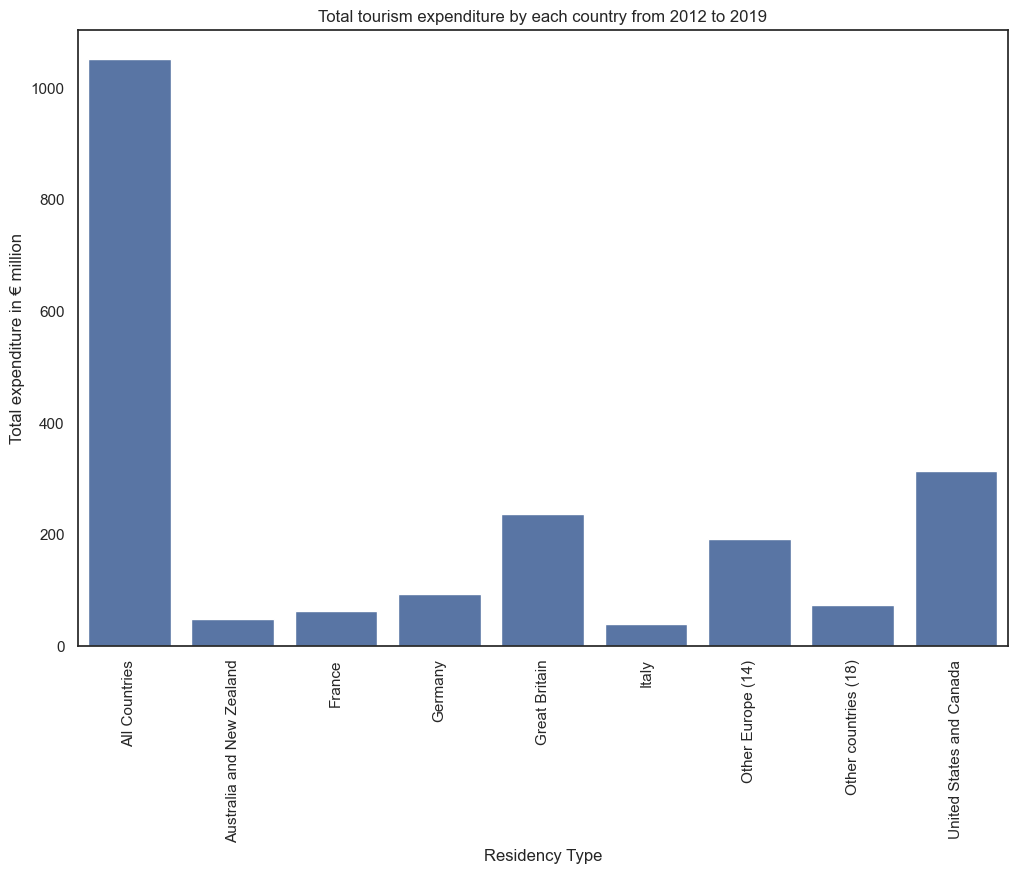

In [1623]:
plt.figure(figsize=(12,8))
sns.barplot(data=expenditure_residence,  x="Area of Residence", y="sum", ci=None)
plt.title("Total tourism expenditure by each country from 2012 to 2019")
plt.xlabel("Residency Type")
plt.ylabel("Total expenditure in € million")
plt.xticks(rotation=90)
plt.show()

**Interpretation**: The bar plot shows that the expenditure from all countries was the highest among all categories in the 'Area of Residence' feature. 

The United States and Canada were the second largest spenders, approximately €300 million spent in Ireland from 2012 to 2019. It is followed by travellers from Great Britain who spent nearly €200 million. However, travellers from Italy spent the least, around € 50 million during the period.


*Programming*: Matplotlib and seaborn libraries are used to visualize the graph. The seaborn's bar graph helps visualize the comparison and different types of traveller expenditure. plt.figure(figsize) sets the weight and height of the graph. Seaborn barplot takes data='expenditure' as a dataframe. x = 'Area of Residence' is to plot the x-axis label, and y='sum' is to plot the total expenditure of each residence across all quarters. ci=None is assigned to remove the error bar. 

plt.title() set the title of bar graph. plt.xlabel() and plt.ylabel() name x-axis and y-axis labels respectively. plt.xticks is assigned with rotation of 90 degrees to rotate the each variable name vertically. plt.show() display the result.

#### 1.1: Average number of nights by nationality

In [1627]:
night_residence = reshape_data.groupby(["Area of Residence", "Quarter"])["Average Num of Nights"].agg(["sum"]).reset_index()
night_residence.head()

,Area of Residence,Quarter,sum
0,All Countries,2012Q1,6.8
1,All Countries,2012Q2,7.0
2,All Countries,2012Q3,8.1
3,All Countries,2012Q4,7.2
4,All Countries,2013Q1,6.7


*Programming*: The variable 'night_residence' is declared to aggregate the sum of average number of nights by each residence across all quarters. 

.reset_index() rearranges the row indexies in correct orders. 

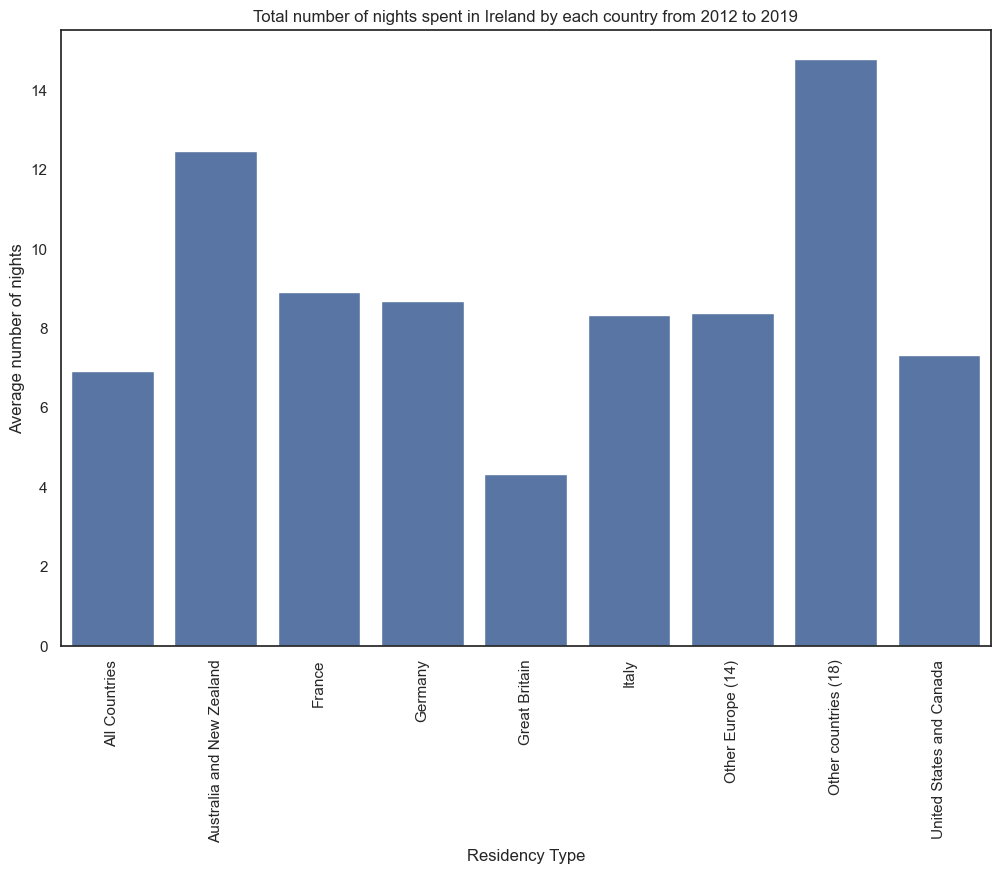

In [1629]:
plt.figure(figsize=(12,8))
sns.barplot(data=night_residence,  x="Area of Residence", y="sum", ci=None)
plt.title("Total number of nights spent in Ireland by each country from 2012 to 2019")
plt.xlabel("Residency Type")
plt.ylabel("Average number of nights")
plt.xticks(rotation=90)
plt.show()

**Interpretation**: The bar plot shows that the average number of nights spent in Ireland from the other countries was the highest among all categories in the 'Area of Residence' feature. 

Australia and New Zealand spent a longer time in Ireland, over 12 nights on average. People from France, Germany, Italy, and other parts of Europe's average number of nights spent in Ireland was relatively the same ranging from 8 to 9 nights. The length of stay for British travellers was the shortest, having 4 nights on average for the period from 2012 to 2019.

**Programming**: Matplotlib and seaborn libraries are used to visualize the graph. The seaborn's bar graph helps visualize the comparison and different types of traveller's length of stay. plt.figure(figsize) sets the weight and height of the graph. Seaborn barplot takes data='expenditure' as a dataframe. x = 'Area of Residence' is to plot the x-axis label, and y='sum' is to plot the total number of nights by each residence across all quarters. ci=None is assigned to remove the error bar. 

plt.title() set the title of bar graph. plt.xlabel() and plt.ylabel() name x-axis and y-axis labels respectively. plt.xticks is assigned with rotation of 90 degrees to rotate the each variable name vertically. plt.show() display the result.

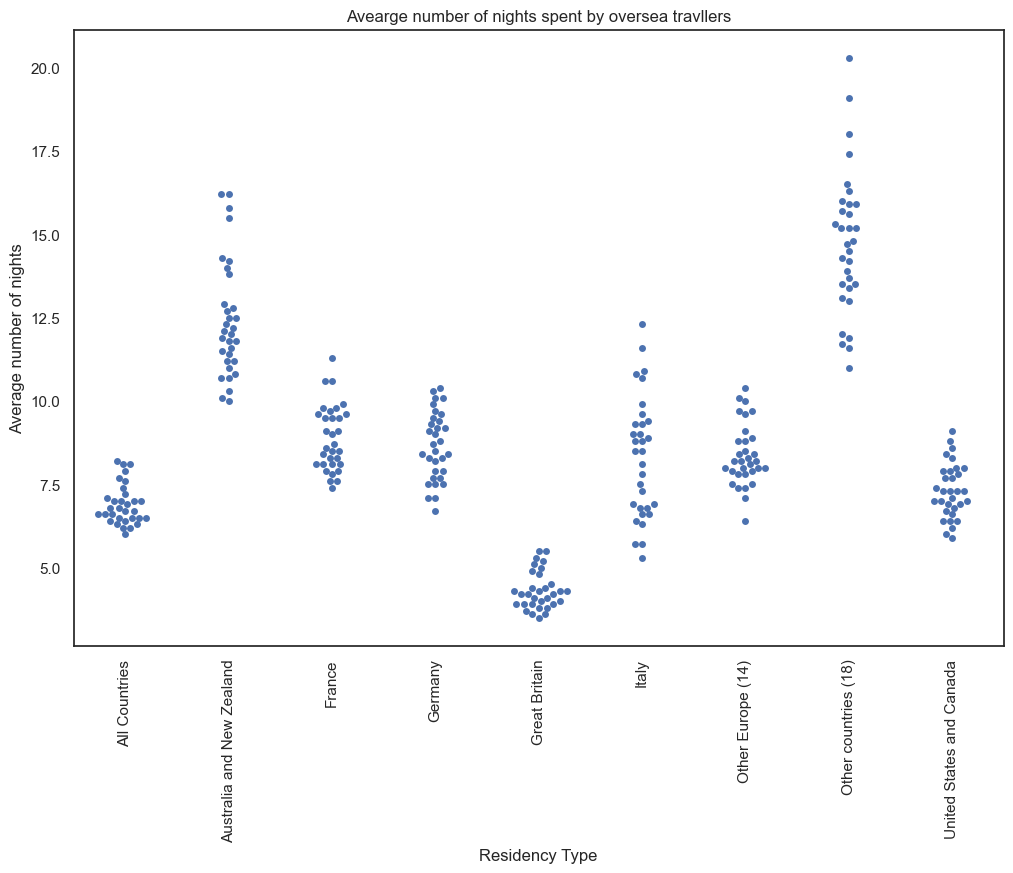

In [1632]:
plt.figure(figsize=(12,8))
sns.swarmplot(data=reshape_data, x='Area of Residence', y='Average Num of Nights')
plt.title('Avearge number of nights spent by oversea travllers')
plt.xlabel("Residency Type")
plt.ylabel("Average number of nights")
plt.xticks(rotation=90)
plt.show()

**Interpretation:** The swarmplot shows that Australia and New Zealand, Germany and France are the important market apart from other countries. The trends of Italian travellers in Ireland should also be investigated further. 

**Programming:** The swarmplot draws a categorical scatterplot with points adjusted to be non-overlapping [(Seaborn, 2012-2024)](https://seaborn.pydata.org/generated/seaborn.swarmplot.html) 

plt.title() sets the width and length of the graph. sns.swarmplot takes 'data' argument from the reshape_data, 'Area of Residence' on the x_axis to plot against the average number of nights on the y-axis. x_label and ylabel name the axis labels of the graph. plt.xticks takes rotation as 90 degree to not overlap the label names and display the name vertically. 

#### 1.2: Number of trips by nationality

In [1636]:
trip_residence = reshape_data.groupby(["Area of Residence", "Quarter"])["Number of trips"].agg(["sum"]).reset_index()
trip_residence.head()

,Area of Residence,Quarter,sum
0,All Countries,2012Q1,1167
1,All Countries,2012Q2,1817
2,All Countries,2012Q3,2095
3,All Countries,2012Q4,1438
4,All Countries,2013Q1,1252


*Programming*: The variable 'trip_residence' is declared to aggregate the sum, average, and median value of 'Number of trips' feature by each residence across all quarters. 

.reset_index() rearranges the row indexies in correct orders. 

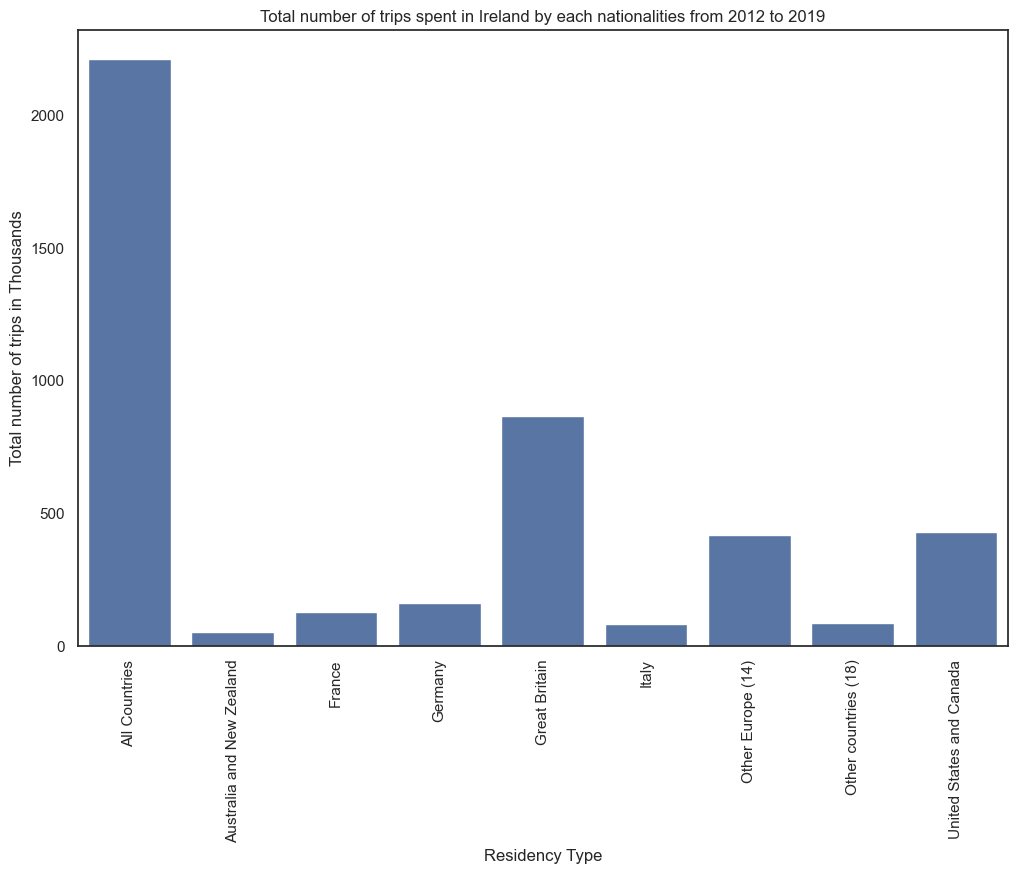

In [1638]:
plt.figure(figsize=(12,8))
sns.barplot(data=trip_residence,  x="Area of Residence", y="sum", ci=None)
plt.title("Total number of trips spent in Ireland by each nationalities from 2012 to 2019")
plt.xlabel("Residency Type")
plt.ylabel("Total number of trips in Thousands")
plt.xticks(rotation=90)
plt.show()

**Interpretation**: The bar plot shows that the number of trips spent in Ireland from all countries was the highest among all categories in the 'Area of Residence' feature. 

Travellers from Great Britain had the largest number of trips, taking 900,000 number of trips from 2012 to 2019. Trips by the travellers from the United States and Canada, and other European countries corresponded to 400,000 trips. 

The count of trips from Australia and New Zealand visitors were lowest, around 50,000 trips in the period.

**Programming**: Matplotlib and seaborn libraries visualize the graph. The seaborn bar graph helps visualize the total trip counts by different types of travellers. plt.figure(figsize) sets the weight and height of the graph. Seaborn barplot takes data='expenditure' as a dataframe. x = 'Area of Residence' is to plot the x-axis label, and y='sum' is to plot the total number of nights by each residence across all quarters. ci=None is assigned to remove the error bar. 

plt.title() sets the title of the bar graph. plt.xlabel() and plt.ylabel() name x-axis and y-axis labels respectively. plt.xticks is assigned with a rotation of 90 degrees to rotate the each variable name vertically. plt.show() display the result.

#### 1.3: Histograms  of each nationalities

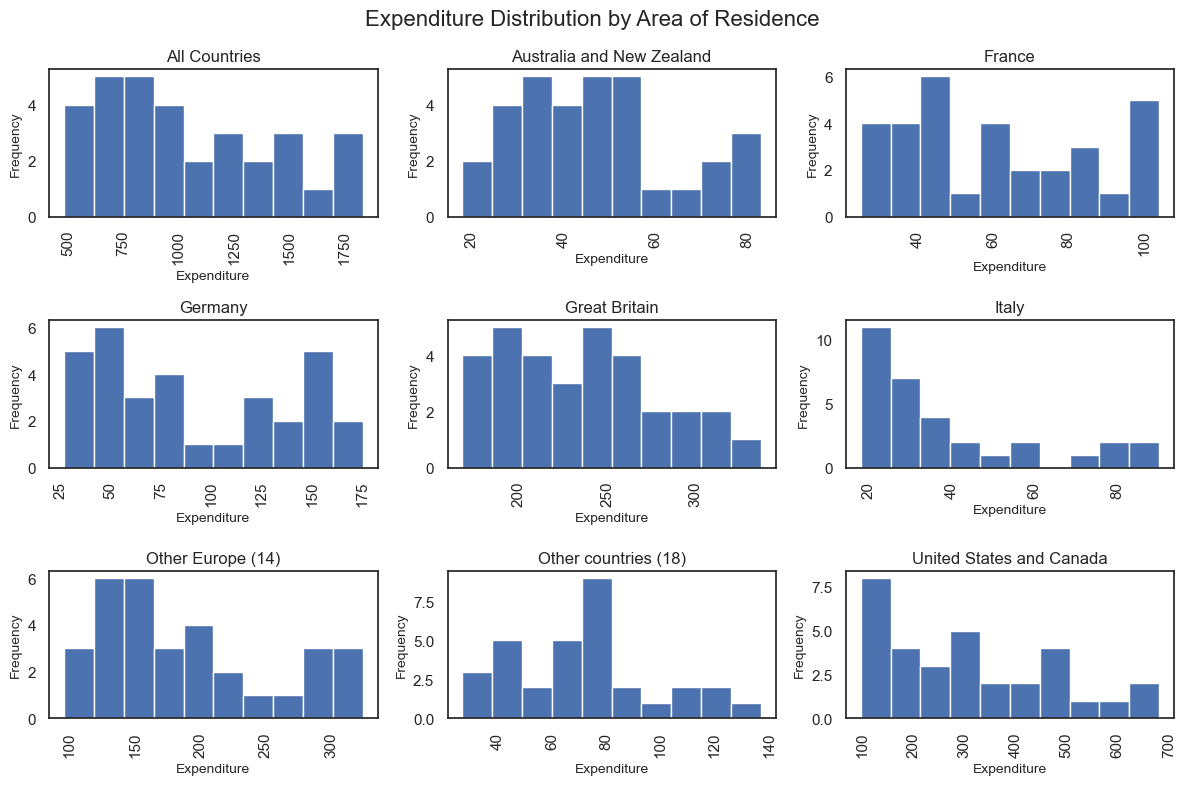

In [1642]:
ax = reshape_data.hist(by='Area of Residence', column='Expenditure', figsize=(12,8))
ax = ax.flatten()

for i in ax:
    i.set_xlabel('Expenditure', fontsize=10)
    i.set_ylabel('Frequency', fontsize=10)
plt.suptitle("Expenditure Distribution by Area of Residence", fontsize=16)
plt.tight_layout()

plt.show()

**Interpretation**: Nine histograms are plotted to show each nationality's expenditure during the eight-year period. The purpose of the histogram is to see which nationalities tend to fall into the high spending category. 

Categories of 'All Countries', 'Australia and New Zealand', 'Great Britain', 'Italy', 'Other Europe', and 'United States and Canada' fall into a right-skewed distribution. This means that people who spend less tend to cluster around the right side of the distribution. 
Studying of  ‘All countries’ categories expenditure from 50 to 70 million can give a better idea to promote a marketing campaign because the distribution is peak in that range.  

Likewise, the market should also be targeted to British travellers who spend between 200 and 260 million Euros as the frequency is highest during this range. 
Another important market is travellers from the United States and Canada, whose expenditure was 100 million, having the highest peak, observing the occurrence can provide the traveller’s expenditure pattern.

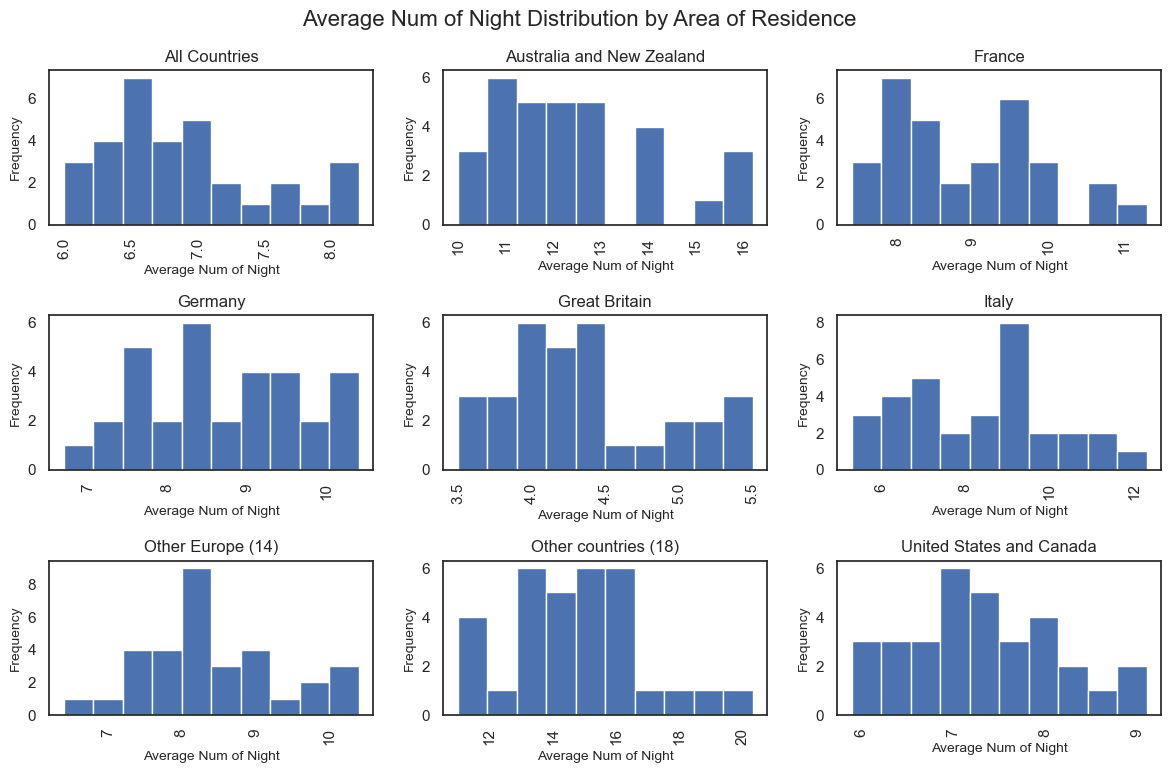

In [1644]:
ax = reshape_data.hist(by='Area of Residence', column='Average Num of Nights', figsize=(12,8))
ax = ax.flatten()

for i in ax:
    i.set_xlabel('Average Num of Night', fontsize=10)
    i.set_ylabel('Frequency', fontsize=10)
plt.suptitle("Average Num of Night Distribution by Area of Residence", fontsize=16)
plt.tight_layout()

plt.show()

**Interpretation:**  Nine histograms are plotted to show each nationalities length of stay during the eight-year period. The purpose of the histogram is to see which nationalities tend to stay longer and how to attract more stay for specific category. 

Categories of 'All Countries', 'Australian and New Zealand', 'Other countries' fall into right-skew distribution which means people who spend fewer nights are clustered around the right side of the distribution. 

The category of 'All Countries' in general spent 6 to 7 nights in average. The length of stay over 7.5 nights decreased in general.
Australia and New Zealand travellers stayed longer, staying up to 12.5 nights. Fewer travellers spent more than 15 nights on average in that category. 
French and German visitors' range of stay falls between 8 and 10 nights on average. The shortest length of stay can be observed in British travellers, staying between 4 and 5 nights. 

In Italian travellers' histogram, the sharp peak can be seen on 8-9 nights, as more travellers in the category stay for 8 nights. People from other parts of Europe have similar length of stay, living up to 9 nights as peak in the distribution. 

Other countries have more length of stay on average than any other category, spending 15 nights. The United States and Canada stayed 6 to 8 nights in average, where the common length of stay for the traveller's category was 7 nights. No USA and Canadian travellers spent more than 9 nights. 

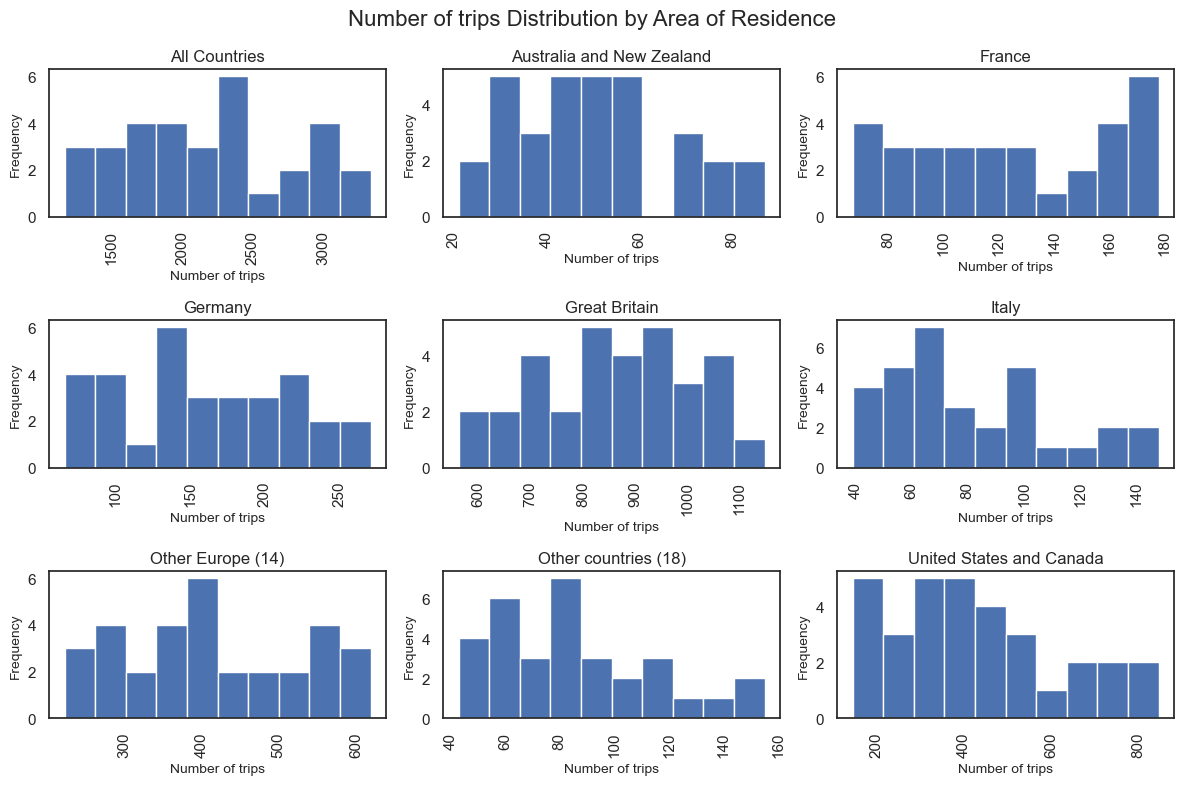

In [1646]:
ax = reshape_data.hist(by='Area of Residence', column='Number of trips', figsize=(12,8))
ax = ax.flatten()

for i in ax:
    i.set_xlabel('Number of trips', fontsize=10)
    i.set_ylabel('Frequency', fontsize=10)
plt.suptitle("Number of trips Distribution by Area of Residence", fontsize=16)
plt.tight_layout()

plt.show()

**Interpretation**: Nine histograms are plotted to show each nationalities taking number of trips during the eight years. The purpose of the histogram is to see which nationalities tend to have more frequency in travelling to Ireland.

The category of 'All Countries' in general spent 2000,000 to over 3000,000 trips. The number of trips over 3000,000 was less in general.

Australia and New Zealand travellers had 25,000 to 75,000 trips. 50,000 trips were a common occurrence. Fewer travellers took more than 75,000 trips in that category.

French travellers took the number of trips between 100,000 and 150,000. The peak after 150,000 trips in French is affecting the distribution.  

German visitors showed up between 100,000 and 150,000 times in Ireland. The British travellers frequently visited Ireland most recording over 1,000,000 trips.

Italian travellers were observed to take 60,000 and 100,000 trips. Figure below 100,000 trips becomes less. 

People from other parts of Europe had 400,000 trips as the shape peak occured at 400,000 point. 

Other countries took the number of trips between 50,000 and 150,000. The common frequency of trips in this category is 80,000 trips. 

The travellers from United States and Canada took the number of trips from 250,000 and 750,000. However, the number become less after 750,000 trips. 


#### 1.4: Expenditure in each quarter

In [1649]:
#Yearly average expenditure
quarterly_expenditure = reshape_data.groupby('Quarter')['Expenditure'].agg(["sum", "mean", "median"]).reset_index()

**Programming**: The variable 'quarterly_expenditure' is declared to aggregate the sum of expenditure in every quarter from 2012 to 2019. 
.reset_index() rearranges the row indexies in correct order. 

In [1651]:
quarterly_expenditure

,Quarter,sum,mean,median
0,2012Q1,966.0,107.333333,30.0
1,2012Q2,1631.0,181.222222,71.0
2,2012Q3,1988.0,220.888889,82.0
3,2012Q4,1244.0,138.222222,47.0
4,2013Q1,1082.0,120.222222,37.0
5,2013Q2,1740.0,193.333333,94.0
6,2013Q3,2373.0,263.666667,101.0
7,2013Q4,1330.0,147.777778,54.0
8,2014Q1,1068.0,118.666667,44.0
9,2014Q2,2001.0,222.333333,122.0


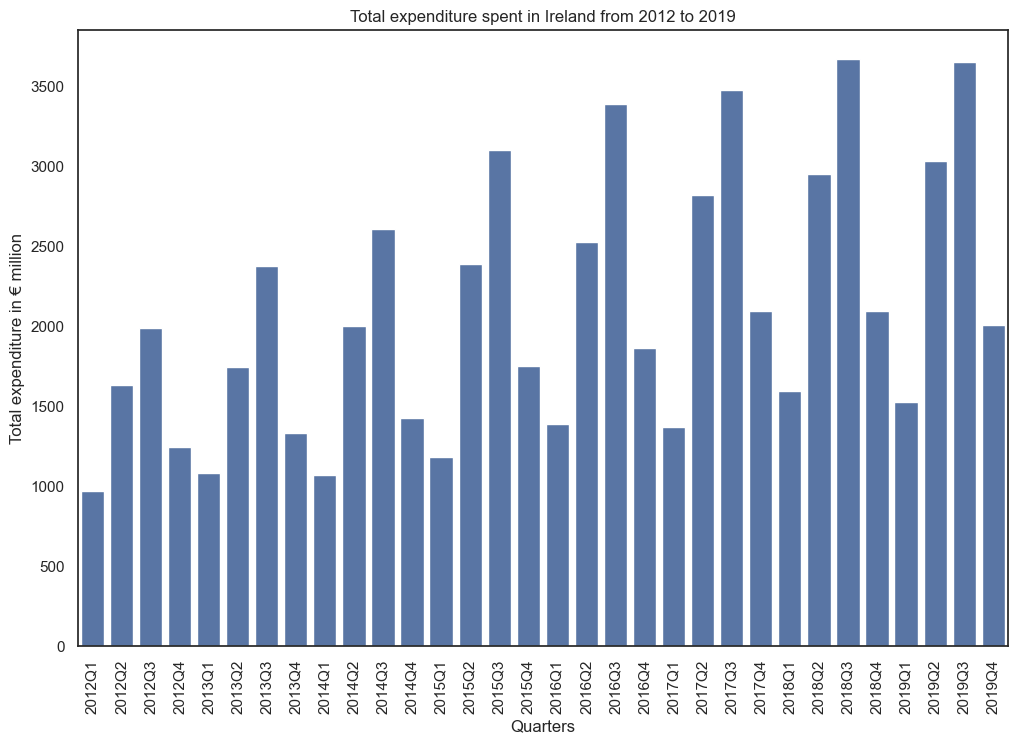

In [1652]:
plt.figure(figsize=(12,8))
sns.barplot(data=quarterly_expenditure,  x="Quarter", y="sum", ci=None)
plt.title("Total expenditure spent in Ireland from 2012 to 2019")
plt.xlabel("Quarters")
plt.ylabel("Total expenditure in € million")
plt.xticks(rotation=90)
plt.show()

**Interpretation**: The bar plot shows the total expenditure gains in Ireland from all countries in every quarter.  

2018Q3 attracted the most tourism income with 3,665 million euros spent in Ireland by all travellers. The lowest amount was recorded in 2012Q1 with 966 million euros. 

The amount of expenditure spent in every Q3 was steadily increasing year-on-year.  

**Programming**: Bar graph is used to compare the total expenditure among quarters. Matplotlib and seaborn libraries are used to visualize the bar graph. 

plt.figure(figsize) sets the weight and height of the graph. Seaborn barplot takes data='quarterly_expenditure' as a dataframe. x = 'Quarter' is to plot the x-axis label, and y='sum' is to plot the total expenditure in each quarter. confidence interval, ci=None is assigned to remove the error bar. 

plt.title() sets the title of the bar graph. plt.xlabel() and plt.ylabel() name x-axis and y-axis labels respectively. plt.xticks is assigned a rotation of 90 degrees to rotate each variable name vertically. plt.show() display the result.

#### 1.5: Average number of nights in each quarter

In [1656]:
#Average number of nights in quarters
quarterly_nights = reshape_data.groupby('Quarter')['Average Num of Nights'].agg(["sum", "mean", "median"]).reset_index()

**Programming**: The variable 'quarterly_nights' is declared to aggregate the average number of nights in every quarter from 2012 to 2019. 
.reset_index() rearranges the row indexies in correct orders. 

In [1658]:
quarterly_nights

,Quarter,sum,mean,median
0,2012Q1,83.4,9.266667,8.0
1,2012Q2,78.1,8.677778,8.3
2,2012Q3,87.6,9.733333,10.4
3,2012Q4,82.6,9.177778,9.3
4,2013Q1,82.4,9.155556,7.9
5,2013Q2,77.1,8.566667,8.5
6,2013Q3,89.1,9.900000,10.0
7,2013Q4,78.8,8.755556,8.8
8,2014Q1,81.0,9.000000,7.6
9,2014Q2,82.5,9.166667,9.0


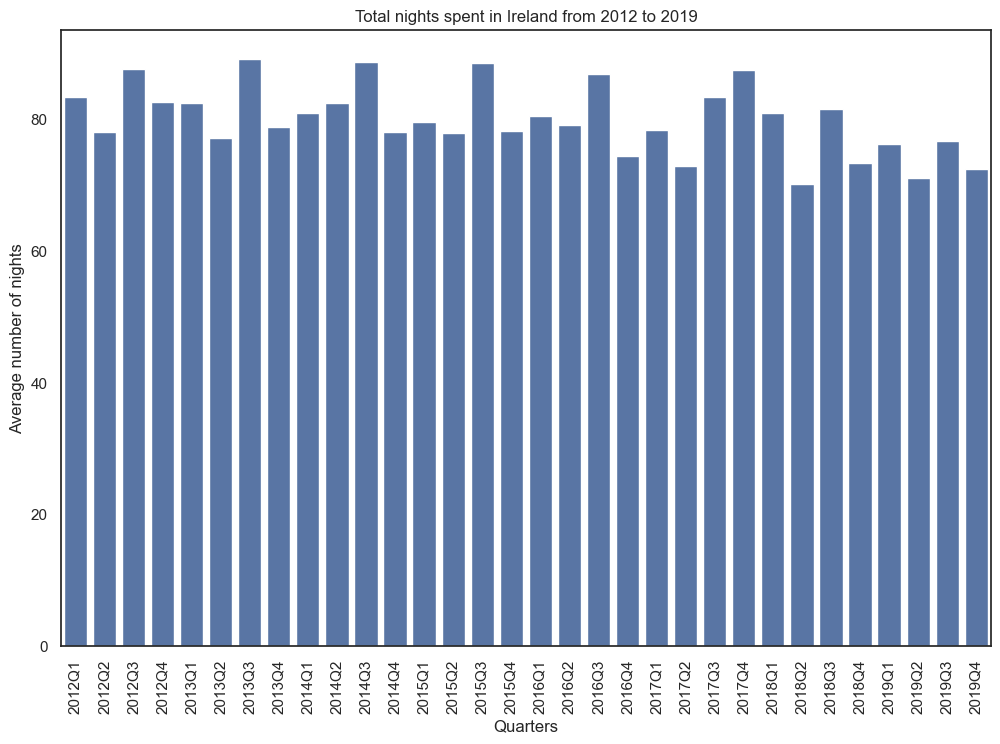

In [1659]:
plt.figure(figsize=(12,8))
sns.barplot(data=quarterly_nights,  x="Quarter", y="sum", ci=None)
plt.title("Total nights spent in Ireland from 2012 to 2019")
plt.xlabel("Quarters")
plt.ylabel("Average number of nights")
plt.xticks(rotation=90)
plt.show()

**Interpretation**: The bar plot shows the comparison of quarterly gains in the average number of nights in Ireland from all countries. 

The number of trips soared in quarter 3 of 2013, obtaining 89.1 nights. However, travellers spent the least number of nights in quarter 2 of 2018 with 70.1 length of stay. 

Q3 was consistently a popular time of the year. The number of nights spent fluctuated from 2012 to 2019.

**Programming**: Bar graph is used to compare the total number of trips among quarters. Matplotlib and seaborn libraries are used to visualize the bar graph. 

plt.figure(figsize) sets the weight and height of the graph. Seaborn barplot takes data='quarterly_nights' as a dataframe. x = 'Quarter' is to plot the x-axis label, and y='sum' is to plot the total number of nights in each quarter. confidenec interval, ci=None is assigned to remove the error bar. 

plt.title() sets the title of the bar graph. plt.xlabel() and plt.ylabel() name x-axis and y-axis labels respectively. plt.xticks is assigned with a rotation of 90 degrees to rotate each variable name vertically. plt.show() display the result.

#### 1.6 Number of trips in each quarter

In [1663]:
#Average number of nights in quarters
quarterly_trips = reshape_data.groupby('Quarter')['Number of trips'].agg(["sum", "mean", "median"]).reset_index()

*Programming*: The variable 'quarterly_trips' is declared to aggregate the number of trips in every quarter from 2012 to 2019. 
.reset_index() rearranges the row indexies in correct orders. 

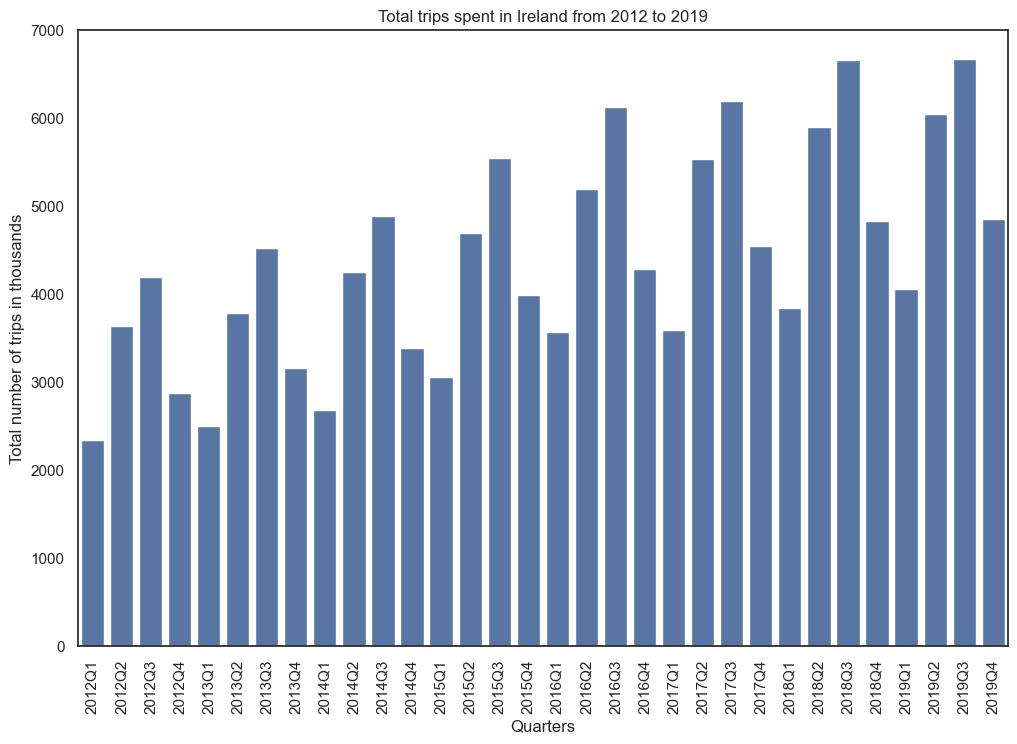

In [1665]:
plt.figure(figsize=(12,8))
sns.barplot(data=quarterly_trips,  x="Quarter", y="sum", ci=None)
plt.title("Total trips spent in Ireland from 2012 to 2019")
plt.xlabel("Quarters")
plt.ylabel("Total number of trips in thousands")
plt.xticks(rotation=90)
plt.show()

**Interpretation**: The bar plot shows the comparison of quarterly gains in the number of trips in Ireland from all countries. 

Ireland attracted the highest number of trips in quarter 3 of 2019 with 6,669 trips. However, 2012Q1 was the lowest in getting trip frequencies. 

Q3 was consistently a popular time of the year. Although the number of trips in every Q1 remained lowest, the figures continued increasing every year within a study period.

**Programming**: Bar graph is used to compare the total number of trips among quarters. Matplotlib and seaborn libraries are used to visualize the bar graph. 

plt.figure(figsize) sets the weight and height of the graph. Seaborn barplot takes data='quarterly_nights' as a dataframe. x = 'Quarter' is to plot the x-axis label, and y='sum' is to plot the total number of nights in each quarter. confidence interval, ci=None is assigned to remove the error bar. 

plt.title() sets the title of the bar graph. plt.xlabel() and plt.ylabel() name x-axis and y-axis labels respectively. plt.xticks is assigned a rotation of 90 degrees to rotate each variable name vertically. plt.show() display the result.

**Conclusion on business analysis and insights**

To summarize, based on the period from 2012 to 2019, the positive outlook on Irish tourism can be seen as figure relating to expenditure, number of trips and nights were growing year-on-year. 

Q3 was the period that received the most visitors, receiving the largest number of trips, nights and expenditure. All countries and other countries were high spenders. People from other countries spent more time in Ireland than people from Europe, and USA and Canada. Looking at the travelling patterns of other countries category, business ought to make marketing plan to encourage people stay longer and grow tourism business in Ireland. 

## **EDA: Statistics**

### **Univariate Analysis: Descriptive Statistics**

Univariate Analysis attempts to explore each variable in a data set, separately. It looks at the range of values, as well as the central tendency of the values. 

#### **Performing Descriptive Statistics**

In [1672]:
print(reshape_data[['Expenditure', 'Average Num of Nights','Number of trips']].describe())

       Expenditure  Average Num of Nights  Number of trips
count   288.000000             288.000000       288.000000
mean    233.576389               8.885764       490.913194
std     337.344654               3.161987       692.958543
min      18.000000               3.500000        21.000000
25%      48.750000               6.900000        83.000000
50%     102.000000               8.200000       170.500000
75%     239.500000              10.300000       576.750000
max    1832.000000              20.300000      3334.000000


In [1673]:
reshape_data[['Expenditure', 'Average Num of Nights','Number of trips']].describe()

,Expenditure,Average Num of Nights,Number of trips
count,288.000000,288.000000,288.000000
mean,233.576389,8.885764,490.913194
std,337.344654,3.161987,692.958543
min,18.000000,3.500000,21.000000
25%,48.750000,6.900000,83.000000
50%,102.000000,8.200000,170.500000
75%,239.500000,10.300000,576.750000
max,1832.000000,20.300000,3334.000000


**Interpretation**: All features have the total count of 288 which means that there is 288 observations in the dataset. 

Average Num of Nights: The travellers that visited Ireland stayed 8.88 nights in average. ±3.16 nights deviated away from the avearge number of nights. The least length of stay was 3.5 nights. On the other hand, the highest number of nights observed was 20.3 nights. 25th percentile of visitors stayed in Ireland for 6.9 nights in average. The median or 50th percentile of travallers had 8.2 average length of stay. People who stayed for over 10 nights fell into 75th percentile category. The spread of data can be estimated by looking at the mean, median, and 25th percentile position. Since the mean is greater than 50th percentile (median) and the median is close to 25th percentile means that the data distribution is positively skewed. 

Expenditure: The travellers that visited Ireland spent 233 million Euros in average. ±337 million Euros were away from the avearge travel expenditure. The least expenditure recorded was 18 million Euros. On the other hand, the highest tourism income generated by oversea travellers in Ireland observed was 1832 million Euros. 25th percentile of traveller spent 48millions. The median or 50th percentile of travallers had spent 102 million Euros. 75th percentile of foreign visitors generated toursim revenue for 239 millions. The spread of data can be estimated by looking at the mean, median, and 25th percentile position. Since the mean is greater than 50th percentile (median) and the median is closer to 25th percentile means that the data distribution has strong right skewness. 

Number of trips: The number of trips were recorded in thousands. The average number of trips recorded during the period was 490,000 trips. 692 thousands trips  were away from the avearge number of trip. The least number of trips was 21,000. On the other hand, the highest number of trips by oversea travellers in Ireland observed was 3,334,000 trips. 25th percentile of traveller took 83,000 trips. The median or 50th percentile of travallers had spent 170,000 trips. 75th percentile of trip data is 576,000. The spread of data can be estimated by looking at the mean, median, and 25th percentile position. Since the mean is greater than 50th percentile (median) and the median is even closer to 25th percentile means that the data distribution is strong indication of right skewed data. 

**Programming:** .describe() method is used to calculate descriptive statistics include those that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN values [(Pandas,2025)](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html). 

#### **Measures of central tendency** 

The measures of central tendency such as mean, median, and mode can be calculated seperately in alternative way.

#### Mean

In [1679]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        mean = reshape_data[features].mean()
        print(f"Mean of {features}: {mean:.2f}")        

Mean of Average Num of Nights: 8.89
Mean of Expenditure: 233.58
Mean of Number of trips: 490.91


**Interpretation:** 

Average Number of Nights recorded during eight years from 2012 to 2019 was 8.89 nights. Average traveller expenditure is 233.6 million Euros and the avearge number of trips recorded was 490,000 trips.

**Programming:** Python's for loop through every feature when feature name is not equal to 'Quarter' and 'Area of Residence'. 'mean' variable access and store the feature index and calculates the mean of every feature. 

#### 25th Percentile

In [1683]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        Q1 = reshape_data[features].quantile(0.25)
        print(f"Q1 of {features}: {Q1:.2f}")        

Q1 of Average Num of Nights: 6.90
Q1 of Expenditure: 48.75
Q1 of Number of trips: 83.00


#### 75th Percentile

In [1685]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        Q3 = reshape_data[features].quantile(0.75)
        print(f"Q3 of {features}: {Q3:.2f}")        

Q3 of Average Num of Nights: 10.30
Q3 of Expenditure: 239.50
Q3 of Number of trips: 576.75


#### Median

In [1687]:
for features in reshape_data.select_dtypes(include=['number']).columns:
    median = reshape_data[features].median()
    print(f"Median of {features}: {median}")

Median of Average Num of Nights: 8.2
Median of Expenditure: 102.0
Median of Number of trips: 170.5


**Interpretation:** 

Travellers who spent 8.2 nights are in the range of 50th percentile. 50th percentile travellers spend 102 million Euros and 170,000 number of trips are in the median range. 

Average Num of Nights: The median is closer to the 25th percentile, Q1 than to the 75th percentile of the data, which means that the distribution of the data is positively skewed. This is due to moderate variation in the data. 
Expenditure: The median is 102, and it is closer to the 25th percentile than to the 75th percentile of the data. The distribution of the data is positively skewed. 
Number of trips: The median is 170, it is closer to the 25th percentile than to the 75th percentile of the data. The distribution of the data is positively skewed.


**Programming:** Python's for loop through every feature when feature data types contain number. 'median' variable access and store the feature index and calculates the median of every feature. 

#### Mode

In [1691]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        mode=  reshape_data[features].mode()   
        print(f"Median of {features}: {mode}")

Median of Average Num of Nights: 0    7.9
Name: Average Num of Nights, dtype: float64
Median of Expenditure: 0    18.0
1    30.0
2    31.0
3    36.0
4    44.0
5    52.0
6    78.0
Name: Expenditure, dtype: float64
Median of Number of trips: 0    98
Name: Number of trips, dtype: int32


**Interpretation**:

Mode or the frequency of values appears are calculated for the categorical, discrete, qualitative data. However, each values are calculated to demonstrate the measure of tendency. 

The mode of Average number of night is 7.9 where the mean of the feature is 8.89. Therefore, the target promotion should be on people who are likely to stay 7 nights and longer and below 8 nights. 

Expenditure feature contains several frequent values. This can help analyst to track the spending behavior 18 million euro as economy, 78 million euro as business or high spending category.

The highly frequency occuring value for trip is 98,000 which is lower than mean and 50th percentile for the number of trip. Promotional campaigns should be carried out to people tends to visit the country less frequently. 

**Programming:** Python's for loop through every feature when feature name is not equal to 'Quarter' and 'Area of Residence'. 'mode' variable access and store the feature index and calculates the frequency of every feature. 

#### Minimum value

In [1695]:
for features in reshape_data.select_dtypes(include=['number']).columns:
    min = reshape_data[features].min()
    print(f"Minimum of {features}: {min}")

Minimum of Average Num of Nights: 3.5
Minimum of Expenditure: 18.0
Minimum of Number of trips: 21


**Programming:** Python's for loop through every feature when feature name is not equal to 'Quarter' and 'Area of Residence'. 'min' variable access and store the feature index and calculates the lowest value found in the data.

#### Maximum value

In [1698]:
for features in reshape_data.select_dtypes(include=['number']).columns:
    max = reshape_data[features].max()
    print(f"Maximum of {features}: {max}")

Maximum of Average Num of Nights: 20.3
Maximum of Expenditure: 1832.0
Maximum of Number of trips: 3334


**Programming:** Python's for loop through every feature when feature name is not equal to 'Quarter' and 'Area of Residence'. 'max' variable access and store the feature index and calculates the highest value found in the data.

#### Range

In [1701]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        range_1 = reshape_data[features].max() - reshape_data[features].min()
        print(f"Range of {features}: {range_1}")

Range of Average Num of Nights: 16.8
Range of Expenditure: 1814.0
Range of Number of trips: 3313


**Interpretation:** The range is the difference between the lowest and highest values. It can be observed that although the average number of night feature does not have big range, the large gap between highest and lowest number can be seen in Expenditure and Number of trips feature. 

**Programming:** Python's for loop through every feature when feature name is not equal to 'Quarter' and 'Area of Residence'. 'range' variable access and store the feature index and calculates the difference between maximum and minimum value in the data.

#### Variance

In [1705]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        variance = reshape_data[features].var()
        print(f"Variance of {features}: {variance:.2f}")   

Variance of Average Num of Nights: 10.00
Variance of Expenditure: 113801.42
Variance of Number of trips: 480191.54


#### Standard Deviation

In [1707]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        deviation = reshape_data[features].std()
        print(f"Standard Deviation of {features}: {deviation:.2f}")        

Standard Deviation of Average Num of Nights: 3.16
Standard Deviation of Expenditure: 337.34
Standard Deviation of Number of trips: 692.96


**Interpretation:** 

Standard deviation is a statistical measurement that looks at how far individual points in a dataset are dispersed from the mean of that set. If data points are further from the mean, there is a higher deviation within the data set. It is calculated as the square root of the variance[(Investopedia,2024)](https://www.investopedia.com/terms/s/standarddeviation.asp). 

3.16 nights is deviated from 8.89 average number of nights.  337 million of expenditure is away from the average expenditure of 233.58 euros, while 692960 trips are deviated from 490910 trips.

**Programming**: Python's for loop through every feature when feature name is not equal to 'Quarter' and 'Area of Residence'. 'deviation' variable access and store the feature index and calculates the standard deviation of each feature.


In [1710]:
for features in reshape_data.columns:
    if features != 'Quarter' and features != 'Area of Residence': 
        Q1 = reshape_data[features].quantile(0.25)
        print(f"Q1 of {features}: {Q1:.2f}")        

Q1 of Average Num of Nights: 6.90
Q1 of Expenditure: 48.75
Q1 of Number of trips: 83.00


#### **Skewness**

Skewness measures the asymmetry of the probability distribution of a real-valued random variable.

#### Interpretation:
- **Positive Skewness** (\( > 0 \)): Indicates that the tail on the right side of the distribution is longer or fatter than the left side. This often suggests that there are a few high-value outliers. For example, income distribution in a population often shows positive skewness due to a small number of very high incomes.
- **Negative Skewness** (\( < 0 \)): Indicates that the tail on the left side of the distribution is longer or fatter than the right side. This means there are a few low-value outliers. For example, the age of retirement could show negative skewness if a significant number of individuals retire earlier than average.
- **Zero Skewness**: Indicates a symmetrical distribution, such as a normal distribution.

#### Formula:
$$
\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum \left( \frac{x_i - \bar{x}}{s} \right)^3
$$

#### Limitations:
- Skewness alone does not indicate the presence of outliers; further analysis is often needed.
- Interpretation can be subjective; a skewness value close to zero may still indicate a practical asymmetry in some contexts.


In [1712]:
features = ['Average Num of Nights', 'Expenditure', 'Number of trips']
for i in features:
    skew = reshape_data[i].skew()
    print(f"Skewness for {i}: {skew:.2f}")

Skewness for Average Num of Nights: 0.87
Skewness for Expenditure: 2.77
Skewness for Number of trips: 2.27


**Interpretation:**

1. Skewness of Average Num of Nights: 0.87

A skewness value indicates that the distribution of 'Average Num of Nights' is moderately right-skewed (or positively skewed). This means that the right tail of the distribution is longer or fatter than the left tail. The moderate right skewness suggests that the distribution is close to normal distribution but not very near to the normal distribution. This is because the frequency of shorter length of stay is bigger than the longer stay. 

2. Skewness of Expenditure: 2.77

A skewness value for expenditure says that the distribution is also exactly positively-skewed. This means that the right tail of the distribution is way longer than the left tail. As majority of people are less spender, high spender are at the right end.

3. Skewness of Number of trips: 2.27

Similarly, the number of trips data has right-skewed data distribution. As more people taking few and fewer than the average number of trips tends to be on the left on the histrogram, the number of trips taken by anomaly travellers exists on the right higher end. As it can be seen on the data that 98,000 trips is mode the number of trips, 490,000 trips as mean while the maximum value of the feature is 3,334,000 trips.

#### **Kurtosis**

Kurtosis measures the "tailedness" of a probability distribution and indicates the presence of outliers in the dataset.

#### Interpretation:
- **High Kurtosis** (> 3): Indicates that the dataset has heavy tails or outliers. This means that extreme values are more frequent than expected in a normal distribution. For example, financial datasets often show high kurtosis due to the presence of extreme losses or gains.
- **Low Kurtosis** (< 3): Indicates that the dataset has lighter tails than a normal distribution. This implies that extreme values are less frequent, which is common in datasets with bounded or limited range.

#### Formula:
$$
\text{Kurtosis} = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum \left( \frac{x_i - \bar{x}}{s} \right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}
$$

#### Limitations:
- Kurtosis can be affected by outliers themselves, leading to misleading interpretations.
- Interpretation can vary; what is considered "high" or "low" kurtosis may depend on the context of the data.

Depending on the degree, distributions have three types of kurtosis [(DataCamp,2023)](https://www.datacamp.com/tutorial/understanding-skewness-and-kurtosis):

+ Mesokurtic distribution (kurtosis = 3, excess kurtosis = 0): perfect normal distribution or very close to it.
+ Leptokurtic distribution (kurtosis > 3, excess kurtosis > 0): sharp peak, heavy tails
+ Platykurtic distribution (kurtosis < 3, excess kurtosis < 0): flat peak, light tails 


In [1715]:
from scipy.stats import kurtosis

features = ['Average Num of Nights', 'Expenditure', 'Number of trips']
for i in features:
    k = kurtosis(reshape_data[i])
    print(f"Kurtosis for {i}: {k:.2f}")

Kurtosis for Average Num of Nights: 0.68
Kurtosis for Expenditure: 7.77
Kurtosis for Number of trips: 4.67


**Interpretation of Kurtosis Values**

1. Kurtosis for Average Num of Nights: 0.68

Normal distribution has zero kurtosis for excessive kurtosis or kurtosis at 3. Value below 3 or a positive kurtosis value with moderate skewness 0.87 indicates that the distribution of Average Num of Nights is Platykurtic. The distribution is broader than a normal distribution. Fewer outliers or extreme values are the end of right tail. 

2. Kurtosis of Expenditure: 7.77

The exccessive kurtosis value or value above 3 represents that the distribution is Leptokurtic with heavy tails.  

3. Kurtosis for Number of trips: 4.67

The kurtosis  value value above 3 represents that the distribution is Leptokurtic with heavy tails.  


#### **Statistics: Plotting Binomial Distributions**

**The binomial distribution** is a discrete probability distribution that models the count of successes in a set number of independent trials. Each trial in this scenario has only two possible outcomes, often labeled as "success" and "failure," with a consistent probability of success across all trials [(DataCamp,2024)](https://www.datacamp.com/tutorial/binomial-distribution).

It is not typically used to model continuous data, as it's primarily suited for modeling discrete outcomes with a fixed number of trials (e.g., success or failure, heads or tails, etc.) The following application of binomal distribution attempts to demonstrate the possibility of getting successful trips which are above threshold, 50th percentile.

Maximum_value: 3334
Mininum_value: 21
Threshold: 170.5
Probability of success: 0.5


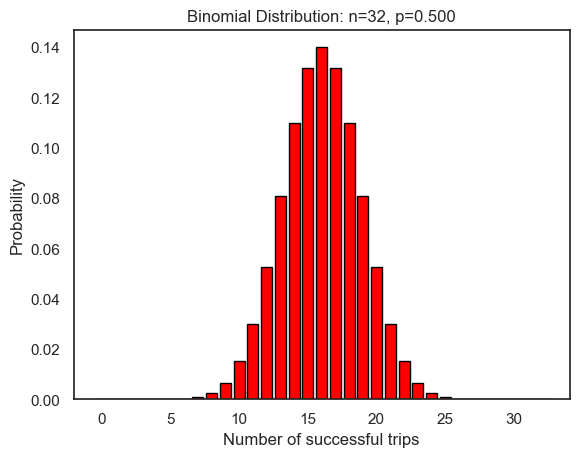

In [1719]:
from scipy.stats import binom

min_value = reshape_data["Number of trips"].min()
max_value = reshape_data["Number of trips"].max()

threshold = np.median(reshape_data['Number of trips'])

df_success = reshape_data[reshape_data['Number of trips']>threshold]
probability_success = len(df_success['Number of trips'])/len(reshape_data['Number of trips'])

num_quarters = reshape_data['Quarter'].nunique()
n = num_quarters 
p = probability_success 
k = np.arange(0, n+1) 

probability = binom.pmf(k,n,p)

print(f"Maximum_value: {max_value}")
print(f"Mininum_value: {min_value}")
print(f"Threshold: {threshold}")
print(f"Probability of success: {probability_success}")

#plot the distribution
plt.bar(k,probability, color='red', edgecolor ='black')
plt.title(f"Binomial Distribution: n={n}, p={p:.3f}")
plt.xlabel(f"Number of successful trips")
plt.ylabel("Probability")
plt.show()

**Interpretation**: The possibility of obtaining number of successful trips that are above 170500 trips in 32 quarters is 50 percent. 

The shape of the distribution is bell-shaped, with the highest number of successful outcomes observed at the 16th quarter, or 16 trials.

### **Statistics: Plotting Normal distribution: Applying Central Limit Theorem**

**Central Limit Theorem (CLT)**


The Central Limit Theorem (CLT) is a fundamental theorem in probability theory and statistics. It states that the distribution of the sample mean of a random variable approaches a normal distribution as the sample size increases, regardless of the shape of the original distribution, under certain conditions. In simpler terms, it asserts that the sampling distribution of the mean tends to be normally distributed even if the population distribution is not.

Key aspects of the Central Limit Theorem include:

**Sample Size:** The theorem applies when the sample size is sufficiently large. As a rule of thumb, a sample size of at least 30 is often considered large enough for the CLT to hold.

**Independence:** The individual observations in the sample must be independent of each other.

**Population Distribution:** The original population distribution may be of any shape, as long as it has a finite mean and variance. It doesn't need to be normally distributed.

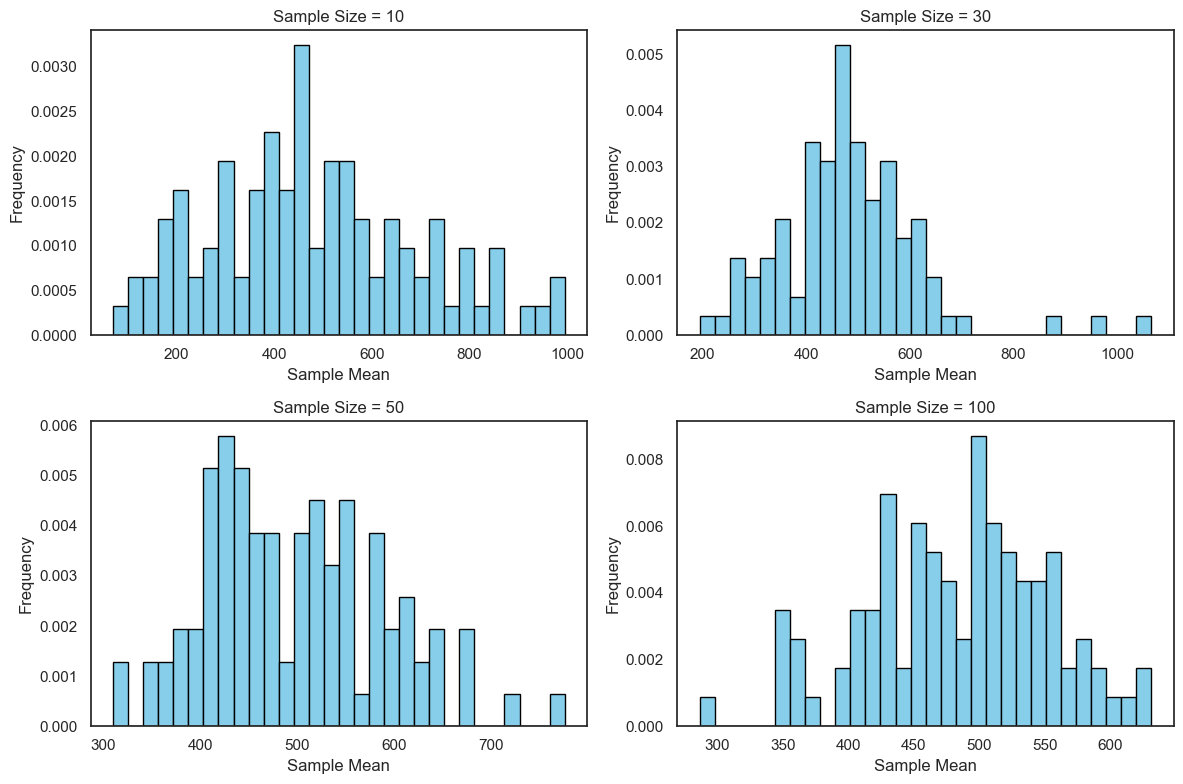

In [1723]:
normal_exp = reshape_data['Number of trips'] 

sample_sizes = [10, 30, 50, 100]
num_samples = 100

plt.figure(figsize=(12,8))

for i, sample_size in enumerate(sample_sizes,1): 
    sample_means = np.zeros(num_samples)

    for j in range(num_samples):
        sample = np.random.choice(normal_exp, size=sample_size, replace=True)
        sample_means[j] = np.mean(sample)
    plt.subplot(2,2,i)
    plt.hist(sample_means, bins=30, density=True, color = 'skyblue', edgecolor='black')
    plt.title(f"Sample Size = {sample_size}")
    plt.ylabel('Frequency')
    plt.xlabel('Sample Mean')

plt.tight_layout()
plt.show()

**Interpretation:** 

Sample size = 10: When the sample size was 30, the histogram was positively skewed. When the sample size increased up to 100, the distribution became closer to normal distribution. According to the central limit theorem, as the sample size increases, the possibility of reaching normal distribution increases even if the population's distribution is not normally distributed or not. 

**Programming:** normal_exp variable stores the number of trips from reshape_data. 

sample_sizes is defined to plot four histograms with different sample sizes. 

plt.figure() determines the width and length of figure. 

for is used to iterate over the sample_size variable and 1 is the index position to begin the loop at 1 index and ignore 0 index. 

sample_means variable is used to initialize the zero array to accumulate sample_mean. Inside the for loop, another for loop is nested to iterate over num_samples, 100 samples.

np.random.choice picks the random sample value from the 'Expenditure' feature, with sample_size [30,50,100,200]. replace = True means that the picks are independent of each other. 

sample_means[j] stores mean of randomly picked sample at an index every time for loop runs. plt.subplot append until the list of sample_size is fully looped. 

plt.hist() is used to get the histogram. 



### **EDA: Univariate Analysis: Plotting Distribution**

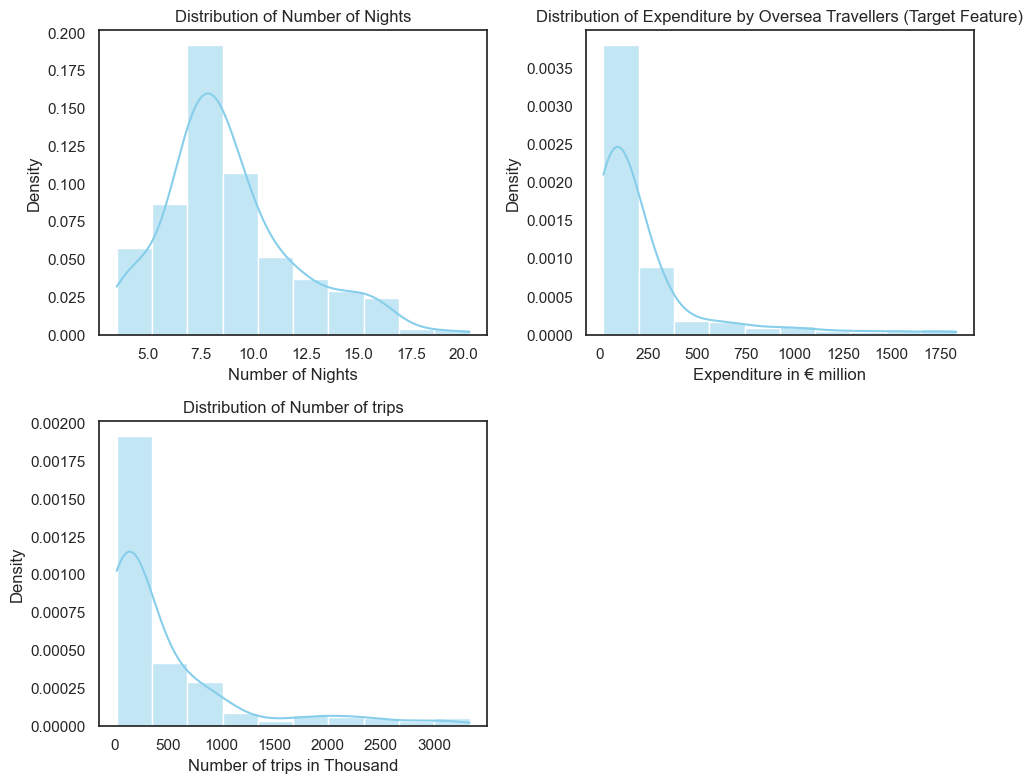

In [1727]:
# Set the style of the visualizations
sns.set(style="white")

# Create a figure with subplots
plt.figure(figsize=(10, 8))

# Plot for number of nights
plt.subplot(2, 2, 1)  # (rows, columns, panel number)
sns.histplot(reshape_data['Average Num of Nights'], bins=10, kde=True, color='skyblue', stat="density")
plt.title('Distribution of Number of Nights')
plt.xlabel('Number of Nights')
plt.ylabel('Density')

# Plot for expenditure 
plt.subplot(2, 2, 2) # (rows, columns, panel number)
sns.histplot(reshape_data['Expenditure'], bins=10, kde=True, color='skyblue', stat="density")
plt.title('Distribution of Expenditure by Oversea Travellers (Target Feature)')
plt.xlabel('Expenditure in € million')
plt.ylabel('Density')

# Plot for number of trips
plt.subplot(2, 2, 3)  # (rows, columns, panel number)
sns.histplot(reshape_data['Number of trips'], bins=10, kde=True, color='skyblue', stat="density")
plt.title('Distribution of Number of trips')
plt.xlabel('Number of trips in Thousand')
plt.ylabel('Density')

# Show the plots
plt.tight_layout()
plt.show()

**Interpretation:** It can be seen that the density distribution plot of all features are positively skewed. The 'Expenditure' histogram has longer tails than the histogram of the number of nights and number of trips. The feature, the number of nights is least positively skewed. 

Average Number of Nights: 7.5 average nights is the common length of stay where majority of travellers had. Fewer travellers tend to stay longer than 17.5 nights in average. 

Expenditure: Many travellers spend 100 to 250 million of Euros during the eight year period. Extreme values exists beyond 1000 million of expenditure. 

Number of trips: Shorter trips are clustered around the left side of the distribution. The range between 100,000 and 500,000 had highest peak as more travellers took short trips. 


**Programming:** the original data is plotted to see the data spread using density plot. sns.set(style='white') sets the background to white. sns.histplot is to plot the density of the data and the values are thrown to 10 (default) bins. kde=True, Kernel Density Estimate is to plot the shape of the data and show the smoothness of the curve. plt.xlabel(), plt.ylabel() provides the name of each feature's value. plt.title() name the distribution plot. 

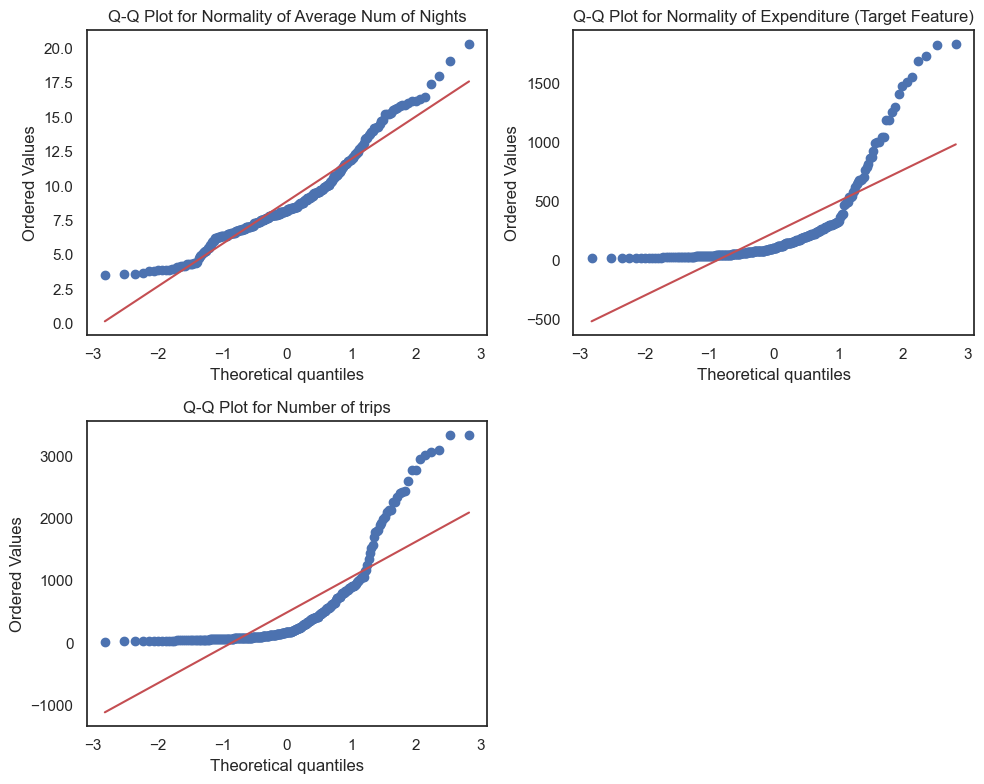

In [1730]:
#checking normality
import scipy.stats as stats

plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)  # (rows, columns, panel number)
stats.probplot(reshape_data['Average Num of Nights'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality of Average Num of Nights')

plt.subplot(2, 2, 2)  # (rows, columns, panel number)
stats.probplot(reshape_data['Expenditure'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality of Expenditure (Target Feature)')

plt.subplot(2, 2, 3)  # (rows, columns, panel number)
stats.probplot(reshape_data['Number of trips'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Number of trips')

plt.tight_layout()
plt.show()

**Interpretation:** Whether the data distribution follows the pattern of normal distribution can be verified by a QQ plot. 

Before machine learning, the feature should be checked to see whether the data points in the dataset passed the normality check or not. The normality check can be conducted by using a Q-Q plot. 

Expenditure: the data points are far away from the theoretical quartile of normal distribution. The data points met with the points of theoretical quartile at -1 and at 1. The remaining data points are away from the points of normally distributed data. This means the influence of outliers is affecting the distribution of data. Therefore, outliers need to be treated. 

Average Num of Nights: Before machine learning, the feature should be checked to see whether the data points in the dataset passed the normality check or not. The normality check can be conducted by using a Q-Q plot. As above in the second figure, the data points that are close to the theoretical quartile of normal distribution can be found from -1.5 to 0. Another overlapping instance can be found at 1. The rest of data points deviate from the line plot of theoretical quantiles.

Number of trips: Before machine learning, the feature should be checked to see whether the data points in the dataset passed the normality check or not. The normality check can be conducted by using a Q-Q plot. As above in the second figure, the data points are far away from theoretical quantiles. The data points overlap with the theoretical quantiles at -1 and 1.3 points. The S-shaped data points mean that the data is skewed due to the presence of outliers. 



**Programming:** Q-Q plot (Quantile-Quantile Plot)'s purpose is to check the normality of data against theretical quantiles. The library scipy.stat is imported from Scipy library. 

plt.figure set the width and size of the figures. plt.subplot is display and compare the plots side by side. stats.probplot generates a probability plot of sample data against the quantiles of a specified theoretical distribution (the normal distribution by default)[(SciPy community, 2025)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html). dist="norm" sets to display normal distribution's quantiles. plot=plt to access matplotlib.pyplot module with given dataset. plt.title sets the title for the Q-Q plots

### **EDA: Bivariate Analysis (Relationships with Target Feature: Expenditure)**

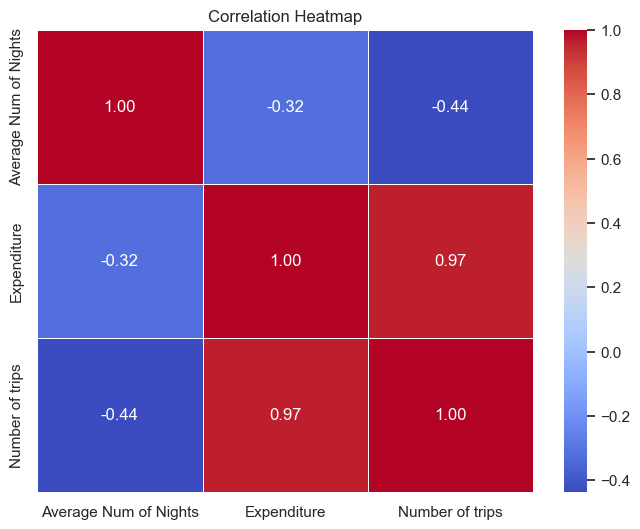

In [1734]:
correlation = reshape_data.drop(columns=["Quarter","Area of Residence"])
corr = correlation.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [1735]:
#  the correlation between Expenditure and Number of trips
correlation1 = reshape_data['Expenditure'].corr(reshape_data['Number of trips'])
print(f"Coefficient of Correlation between Expenditure and Number of trips: {correlation1:.2f}")

Coefficient of Correlation between Expenditure and Number of trips: 0.97


In [1736]:
#  the correlation between Expenditure and Average Num of Nights
correlation2 = reshape_data['Expenditure'].corr(reshape_data['Average Num of Nights'])
print(f"Coefficient of Correlation between Expenditure and Average Number of Nights: {correlation2:.2f}")

Coefficient of Correlation between Expenditure and Average Number of Nights: -0.32


In [1737]:
# the correlation between sepal_length and sepal_width
correlation3 = reshape_data['Number of trips'].corr(reshape_data['Average Num of Nights'])
print(f"Coefficient of Correlation between Expenditure and Average Number of Nights: {correlation3:.2f}")

Coefficient of Correlation between Expenditure and Average Number of Nights: -0.44


**Interpretation:** Correlation values range from -1 to 1, with 1 indicating a positive correlation and -1 indicating a negative correlation. 

The correlation between Expenditure and the Number of trips has a very high positive correlation. The value 0.97 is very close to 1, indicating that as the number of trips increases, the expenditure will also increase.

The correlation between Expenditure and the average num of night feature is weak negative correlation. According to Pearson's correlation, the value -0.32 means that there is weak negative linear relationships between two features.

Similarily, The correlation between nummber of trips and the average num of night feature has a moderately weak negative correlation. The value -0.44 means that there is weak negative linear relationships between two features. As number of trips increases, the average number of nights will decrease.

**Programming:** The correlation between individual features are calcuated using .corr() method. 

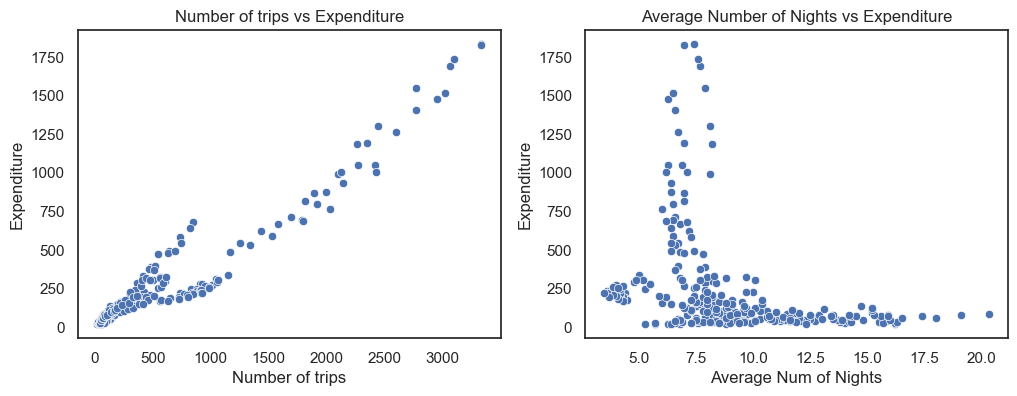

In [1740]:
# Scatterplots: Target Features: Expenditure vs. Other Features
#Number of trips vs Expenditure
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.title('Number of trips vs Expenditure')
sns.scatterplot(x='Number of trips', y='Expenditure', data=reshape_data)

#Number of trips vs Expenditure
plt.subplot(1, 2, 2) ## (rows, columns, panel number)
sns.scatterplot(x='Average Num of Nights', y='Expenditure', data=reshape_data)
plt.title('Average Number of Nights vs Expenditure')
plt.show()

**Interpretation:** The correlation between target feature('Expenditure') and the independent variable can be verified by scatterplot. 

Expenditure vs Number of trips: Strong positive correlation is confirmed as the number increase, the expenditure also increase.

Expenditure vs Number of Nights: the scatterplot shows that the expenditure peak in the short number of stay which indicates strong non-linear and weak negative linear relationship

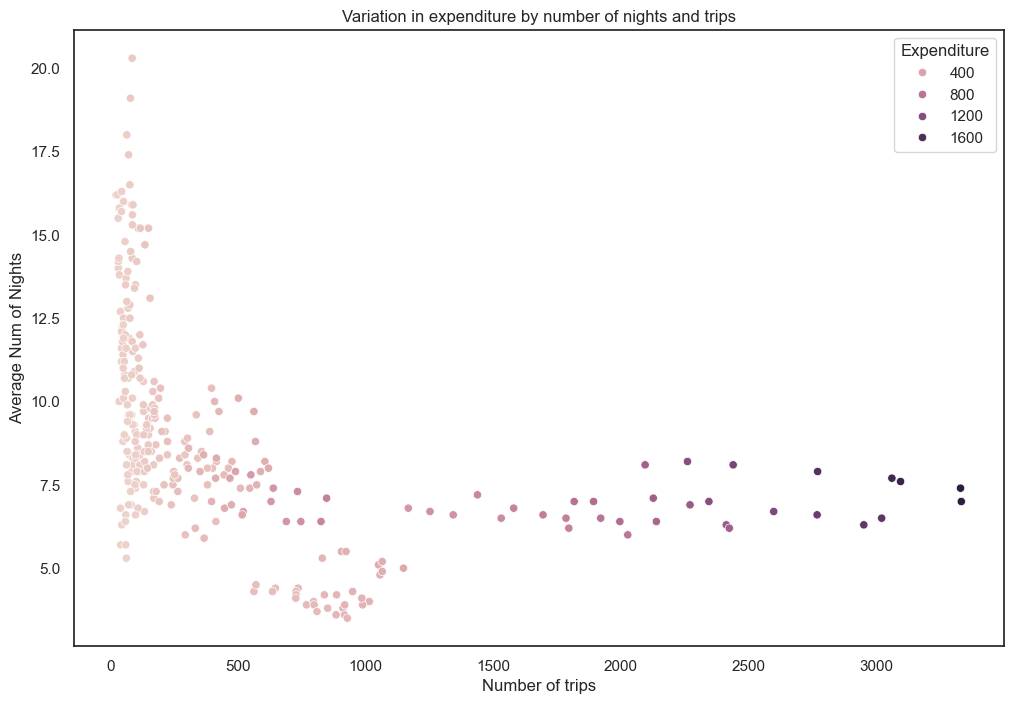

In [1742]:
#Checking the linear relationship
plt.figure(figsize=(12,8))
sns.scatterplot(x=reshape_data['Number of trips'], y=reshape_data['Average Num of Nights'], hue=reshape_data['Expenditure'])
plt.title('Variation in expenditure by number of nights and trips')
plt.show()

**Interpretation:** Plotting three features together can confirm that as the number of trips increases, the expenditure increases, and then, the length of stay decreases. Conversely, when the number of nights increases, the expenditure decreases and the number of trips decreases.

This means that as high spenders tend to have shorter average length of stay and had more trips, while the people who tend to stay longer spent less and and took less trips.  

<Figure size 1200x1200 with 0 Axes>

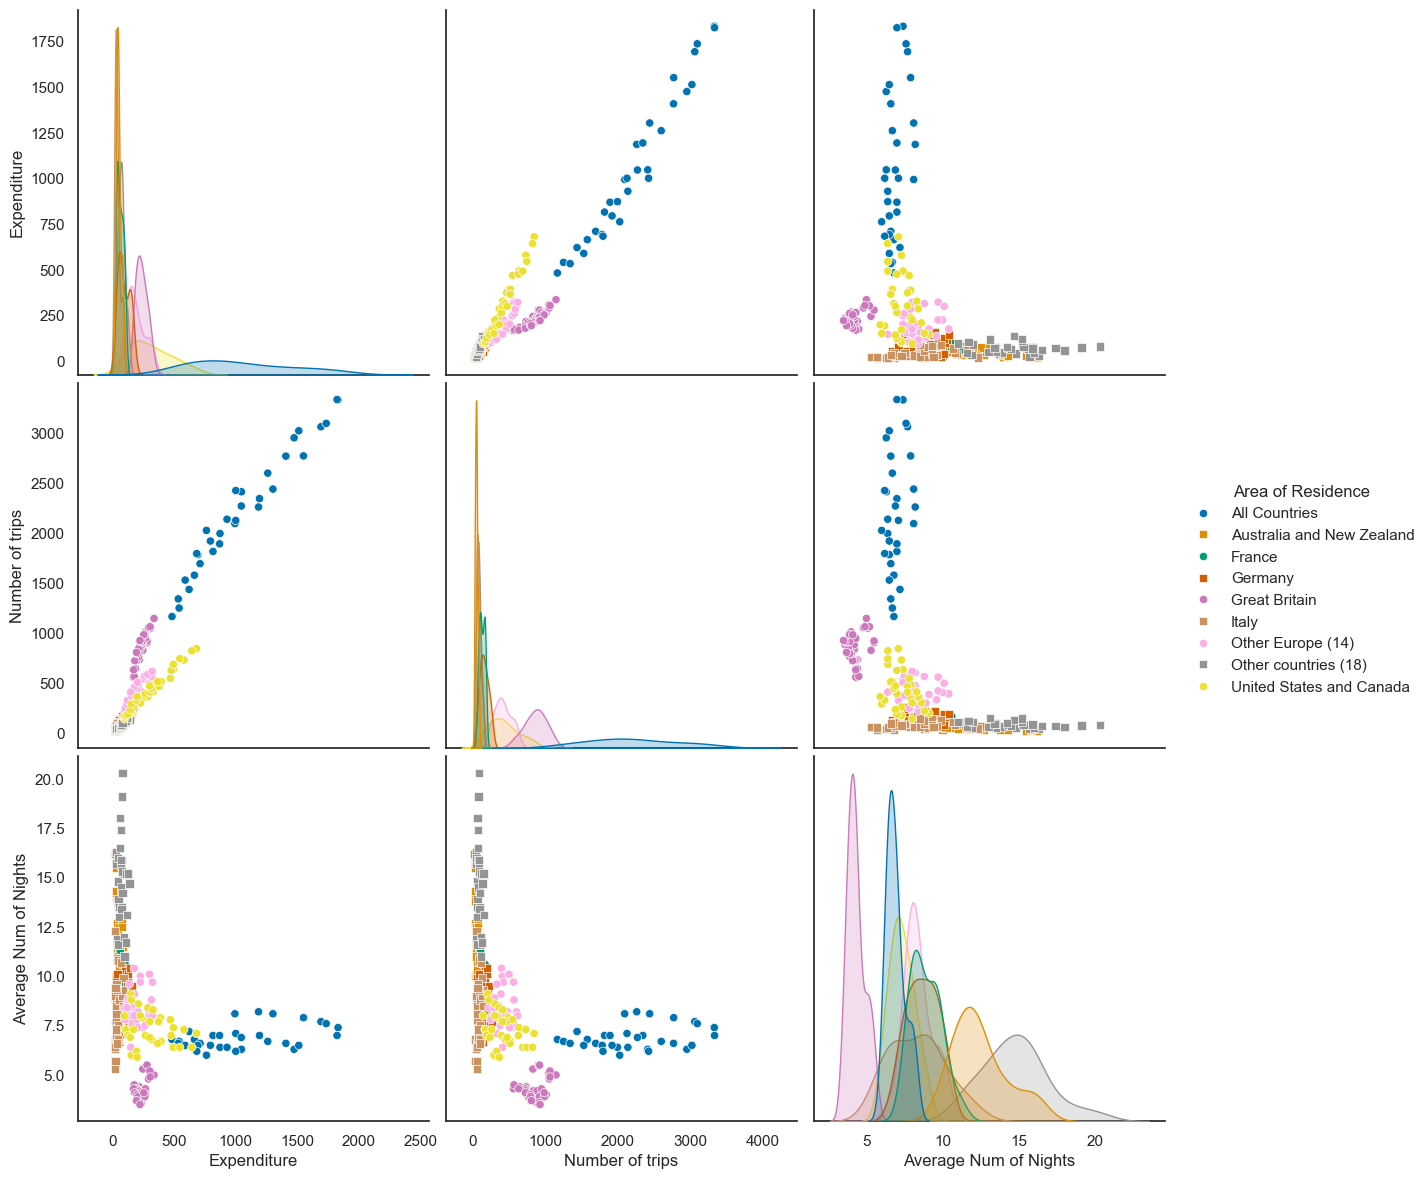

In [1744]:
plt.figure(figsize=(12, 12))
sns.pairplot(
    reshape_data,
    vars=['Expenditure', 'Number of trips', 'Average Num of Nights'],
    hue='Area of Residence', 
    markers=['o', 's'],  
    palette='colorblind',
    height=4,         
    aspect=1, 
   
)
plt.show()

**Interpretation:** pairwise plot shows that each feature's distribution is right-skewed, the a positive correlation between the number of trips and the expenditure.

All Countries are representing high spenders. Since all countries do not equal the sum of all other residence categories, discarding all countries has the potential to lose meaningful observations. 



### **EDA and Statistics: Detecting and Treating outliers**

#### 1.0 Dectecting Outliers

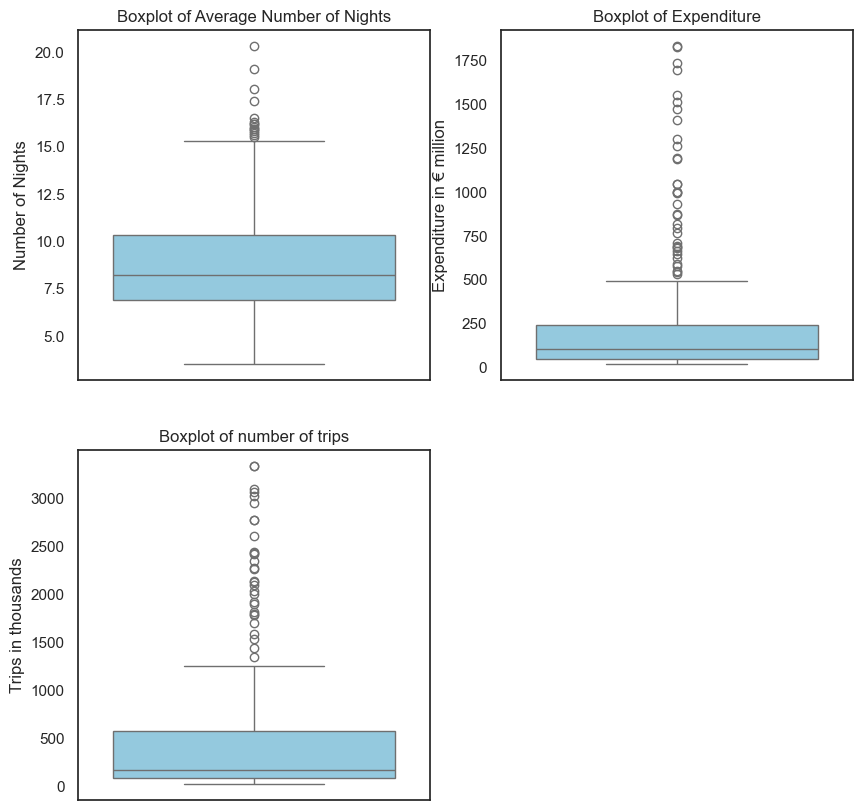

In [1748]:
# Set the style of the visualizations
sns.set_style("white")

# Create a figure with subplots
plt.figure(figsize=(10, 10))

# Boxplot for number of nights
plt.subplot(2, 2, 1) 
sns.boxplot( data= reshape_data['Average Num of Nights'], color='skyblue')
plt.title('Boxplot of Average Number of Nights')
plt.ylabel('Number of Nights')

# Boxplot for expenditure 
plt.subplot(2, 2, 2) 
sns.boxplot(data= reshape_data['Expenditure'], color= 'skyblue')
plt.title('Boxplot of Expenditure')
plt.ylabel('Expenditure in € million')


# Boxplot for number of trips
plt.subplot(2, 2, 3) 
sns.boxplot(data= reshape_data['Number of trips'], color= 'skyblue')
plt.title('Boxplot of number of trips')
plt.ylabel('Trips in thousands')

plt.show()

**Interpretation:** 

Boxplot of Average Number of Nights: 25th percentile of the boxplot begins with 6.6 nights on average, 50th percentile of the data represents 8 nights on average, and 75th percentile of the data falls into the range of 10 nights on average. The lower bound of the data is 2 nights on average, whereas the upper bound is 15 nights on average. Outliers can be observed beyond the upper bound. The distribution is slightly right-skewed because the median is closer to the 25th percentile.

Boxplot of Expenditure: 25th percentile of the boxplot begins with 62 million Euros, 100 million Euros in oversea expenditure can be seen in the 50th percentile of the data, and 75th percentile of the expenditure data is 250 million Euros. The lower bound of the data is approximately 50 million in Euros, while the upper bound is 500 million Euros. Outliers can be observed beyond the upper bound. The distribution is positively-skewed because the median is closer to the 25th percentile or Quartile 1.

Boxplot of Number of trips: 25th percentile of the boxplot begins with 100,000 trips.  The 50th percentile of the data represents 200,000 trips, and 600,000 trips are in 75th percentile of the trip data. The lower bound of the data falls approximately into 50,000 trips, while the upper bound is 1250,000 trips. Outliers can be observed beyond the upper bound. The distribution is positively-skewed because the median is closer to the 25th percentile or Quartile 1.

**Programming:** The boxplot of seaborn library helps to visualise the data distribution, including lower bound (25th percentile), median (50th percentile), upper bound (75th percentile) and outliers. Box plox of each feature is identified using sns.boxplot() method where ylabel show the numerical values of each feature. 

plt.subplot() is used to identify each plot with plt.subplot(number of row, number of column and panel number). plt.show() is to display the plot.

#### 1.1 Detecting Outliers: Interquartile Range Method

In [1752]:
expenditure_iqr = np.array(reshape_data["Expenditure"])
Q1 = np.percentile(expenditure_iqr, 25)
Q3 = np.percentile(expenditure_iqr, 75)
Q2 = reshape_data["Expenditure"].median()
IQR_1 = Q3 - Q1
print(f"IQR for expenditure: {IQR_1:.4f}")

lower_bound = Q1 - 1.5 * IQR_1
upper_bound = Q3 + 1.5* IQR_1
print(f"Lower_bound of Expenditure: {lower_bound:.4f}")
print(f"Upper bound of Expenditure: {upper_bound:.4f}")


dist_to_q1 = abs(Q2 - Q1)
dist_to_q3 = abs(Q3 - Q2)

expenditure_outliers = reshape_data[(reshape_data['Expenditure'] < lower_bound) | (reshape_data['Expenditure'] > upper_bound)]

outlier_percentage = (len(expenditure_outliers)/len(reshape_data))*100
print(f"Percentage of outlier: {outlier_percentage:.4f}") 
print(f"Maximum value of expenditure: {reshape_data['Expenditure'].max()}")
print(f"Minimum value of expenditure: {reshape_data['Expenditure'].min()}")
print(f"Q2 Distance to Q1: {dist_to_q1}")
print(f"Q2 Distance to Q3: {dist_to_q3}")

IQR for expenditure: 190.7500
Lower_bound of Expenditure: -237.3750
Upper bound of Expenditure: 525.6250
Percentage of outlier: 12.1528
Maximum value of expenditure: 1832.0
Minimum value of expenditure: 18.0
Q2 Distance to Q1: 53.25
Q2 Distance to Q3: 137.5


**Interpretation:** 

The value that falls between the 25th and 75th percentile of the data is 190 million Euros, which means 50% of the data fall within the range. The upper bound threshold is 525 million Euros, while the lower bound calculation was -237. This is because the difference between the minimum and maximum value is large or the calculation of range is 1832, making the result of Q1 to negative value. 

The percentage of outliers is 12.15 percent, and the proportion of outliers to the whole data is very high. Since the outliers can hold valuable data. The project will treat the outliers without removing them.

**Programming:** The variable 'expenditure_iqr' is declared to create the numpy array. np.array will transform the 'Expenditure' feature into numpy array. 

Q1 variable is declared to calculate the 25th percentile of the data using np.percentile() function. 
Q3 variable is to calculate the 75th percentile of the data using np.percentile() function. 
IQR_1 will store the difference between 75th percentile of the data and 25th percentile of the data. 

lower_bound is minimum threshold. It is calculated with the formula (Q1−1.5×IQR). However, the minimum threshold of the expenditure data is very low compared to the 75th percentile of expenditure data. The result of the Q1 calculation led to the negative value. 

Since negative expentiure values do not translate to the actual dataset. The calculation is converted to turn 0 when expentiure lower bound becomes negative. The calculation of upper bound is done with (Q1+1.5×IQR_1). 1.5 is the multiplier to calculate the threshold of Q1 and Q3. 

expenditure_outliers variable stores the values below the lower bound and the values above upper bound to extract the outliers to calculate the percentage. 

The percentage of outliers is calculated by the size of outliers divided by the size of the data to decide whether the outliers should be removed or transformed. 

In [1755]:
night_iqr = np.array(reshape_data["Average Num of Nights"])
Q1 = np.percentile(night_iqr, 25)
Q3 = np.percentile(night_iqr, 75)
Q2 = reshape_data["Average Num of Nights"].median()
IQR_2 = Q3 - Q1
print(f"IQR for number of nights: {IQR_2:.4f}")

lower_bound = Q1 - 1.5* IQR_2
upper_bound = Q3 + 1.5* IQR_2
print(f"Lower_bound of avg night: {lower_bound:.4f}")
print(f"Upper bound of avg night: {upper_bound:.4f}")

dist_to_q1 = abs(Q2 - Q1)
dist_to_q3 = abs(Q3 - Q2)

night_outliers = reshape_data[(reshape_data['Average Num of Nights'] < lower_bound) | (reshape_data['Average Num of Nights'] > upper_bound)]

outlier_percentage = (len(night_outliers)/len(reshape_data))*100
print(f"Percentage of outlier: {outlier_percentage:.4f}")  
print(f"Q2 Distance to Q1: {dist_to_q1:.2f}")
print(f"Q2 Distance to Q3: {dist_to_q3:.2f}")

IQR for number of nights: 3.4000
Lower_bound of avg night: 1.8000
Upper bound of avg night: 15.4000
Percentage of outlier: 5.2083
Q2 Distance to Q1: 1.30
Q2 Distance to Q3: 2.10


**Interpretation**:

The value that falls between the 25th and 75th percentile of the data is 3.4 nights on average, which means 50% of the data fall within the range. The upper bound threshold is 15.4 average nights, while the lower bound is 1.8 nights on average. The percentage of outliers is 5.2 percent, and the proportion of outliers to the whole data is high. The distribution of data is skewed distribution is the percentage is above 5 percent. Since the outliers can hold valuable data. The project will treat the outliers without removing them.

**Programming:** The variable 'night_iqr' is declared to create the numpy array. np.array will transform the 'Average Num of Night' feature into numpy array. 

Q1 variable is declared to calculate the 25th percentile of the data using np.percentile() function. 
Q3 variable is to calculate the 75th percentile of the data using np.percentile() function. 

IQR_2 stores the difference between the 75th percentile of the data and 25th percentile of the data. 

lower_bound is the minimum threshold. It is calculated with the formula (Q1−1.5×IQR_2). The calculation of upper bound is done with (Q1+1.5×IQR_2). 1.5 is the multiplier to calculate the threshold of Q1 and Q3. 

'night_outliers' variable stores the values below the lower bound and the values above the upper bound to extract the outliers to calculate the percentage. 

The percentage of outliers is calculated by the size of outliers divided by the size of the data to decide whether the outliers should be removed or transformed. 

In [1758]:
trip_iqr = np.array(reshape_data["Number of trips"])
Q1 = np.percentile(trip_iqr, 25)
Q3 = np.percentile(trip_iqr, 75)
Q2 = reshape_data["Number of trips"].median()
IQR_3 = Q3 - Q1
print(f"IQR for number of trips: {IQR_3:.4f}")

lower_bound = Q1 - 1.5 * IQR_3
upper_bound = Q3 + 1.5* IQR_3
print(f"Lower_bound of trips: {lower_bound:.4f}")
print(f"Upper bound of trips: {upper_bound:.4f}")

dist_to_q1 = abs(Q2 - Q1)
dist_to_q3 = abs(Q3 - Q2)

trip_outliers = reshape_data[(reshape_data['Number of trips'] < lower_bound) | (reshape_data['Number of trips'] > upper_bound)]

outlier_percentage = (len(trip_outliers)/len(reshape_data))*100
print(f"Percentage of outlier: {outlier_percentage:.4f}")

print(f"Maximum value of trips: {reshape_data['Number of trips'].max()}")
print(f"Minimum value of trips: {reshape_data['Number of trips'].min()}")
print(f"Q2 Distance to Q1: {dist_to_q1:.2f}")
print(f"Q2 Distance to Q3: {dist_to_q3:.2f}")

IQR for number of trips: 493.7500
Lower_bound of trips: -657.6250
Upper bound of trips: 1317.3750
Percentage of outlier: 10.4167
Maximum value of trips: 3334
Minimum value of trips: 21
Q2 Distance to Q1: 87.50
Q2 Distance to Q3: 406.25


**Interpretation**:

The value that falls between the 25th and 75th percentile of the data is 493,700 trips, which means 50% of the data fall within the range. The upper bound threshold is 131737.5 trips, while the lower bound is -657. This is because the difference between the minimum and maximum value is large, or the calculation of range is 1267, making the result of Q1 to negative value. 

The percentage of outliers is 10 percent, and the proportion of outliers to the whole data is very high. Since the outliers can hold valuable data. The project will treat the outliers without removing them.

**Programming**: The variable 'trip_iqr' is declared to create the numpy array. np.array will transform the 'Number of trips' feature into numpy array.

Q1 variable is declared to calculate the 25th percentile of the data using the np.percentile() function. Q3 variable is to calculate the 75th percentile of the data using np.percentile() function.

IQR_3 stores the difference between the 75th percentile of the data and the 25th percentile of the data.

lower_bound is the minimum threshold. It is calculated with the formula (Q1−1.5×IQR_1). The calculation of upper bound is done with (Q1+1.5×IQR_1). 1.5 is the multiplier to calculate the threshold of Q1 and Q3. However, the minimum threshold of the number of trip is very low compared to the 75th percentile of data. The result of the Q1 calculation led to the negative value. 

Since negative values in the number of trip do not translate to the actual dataset. The calculation is converted to turn 0 when the lower bound of number of trip becomes negative. 

The calculation of the upper bound is done with (Q1+1.5×IQR_1). 1.5 is the multiplier to calculate the threshold of Q1 and Q3.

'trip_outliers' variable stores the values below the lower bound and the values above the upper bound to extract the outliers to calculate the percentage.

The percentage of outliers is calculated by the size of outliers divided by the size of the data to decide whether the outliers should be removed or transformed.

#### 2.0 Handling Outliers

##### Since the percentage of outliers are greater than 1, the project will handle outliers by conducting four ways of transformation. 

+ Logarithm transformation
+ Square root transformation
+ Cube root transformation
+ Winsorization (Capping outliers to 3rd Standard Deviation)

#### 2.1 Treating outliers: Logarithm Transformation

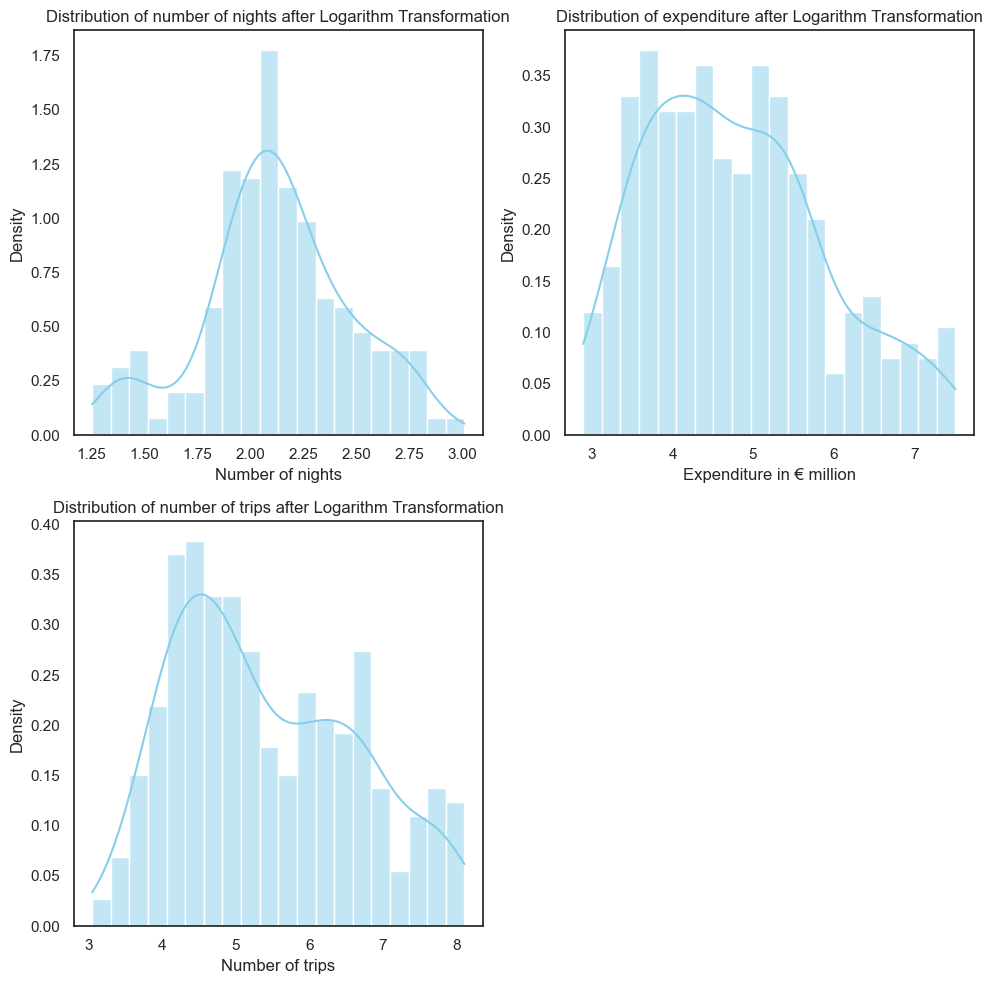

In [1764]:
#Apply a log transformation each feature
log_tf_data = reshape_data.copy()
if (reshape_data['Average Num of Nights'] > 0).all():
    log_tf_data['Average Num of Nights'] = np.log(reshape_data['Average Num of Nights'])
else:
    print("Log transformation cannot be performed.")

if (reshape_data['Expenditure'] > 0).all():
    log_tf_data['Expenditure'] = np.log(reshape_data['Expenditure'])
else:
    print("Log transformation cannot be performed.")

if (reshape_data['Number of trips'] > 0).all():
    log_tf_data['Number of trips'] = np.log(reshape_data['Number of trips'])
else:
    print("Log transformation cannot be performed.")


sns.set(style="white")
plt.figure(figsize=(10, 10))

# Plot for expenditure Length
plt.subplot(2, 2, 1)  # (rows, columns, panel number)
sns.histplot(log_tf_data['Average Num of Nights'], bins=20, kde=True, color='skyblue', stat="density", )
plt.title('Distribution of number of nights after Logarithm Transformation')
plt.xlabel('Number of nights')
plt.ylabel('Density')

# Plot for expenditure Length
plt.subplot(2, 2, 2)  # (rows, columns, panel number)
sns.histplot(log_tf_data['Expenditure'], bins=20, kde=True, color='skyblue', stat="density", )
plt.title('Distribution of expenditure after Logarithm Transformation')
plt.xlabel('Expenditure in € million')
plt.ylabel('Density')

# Plot for expenditure Length
plt.subplot(2, 2, 3)  # (rows, columns, panel number)
sns.histplot(log_tf_data['Number of trips'], bins=20, kde=True, color='skyblue', stat="density", )
plt.title('Distribution of number of trips after Logarithm Transformation')
plt.xlabel('Number of trips')
plt.ylabel('Density')


# Show the plots
plt.tight_layout()
plt.show()

**Interpretation:** Three histograms: Average Num of Nights, Expenditure, and Number of trips are plotted after log transformation.

On the plot of Average Num of Nights, the distribution is closer to normal distribution compared to the two other plots. However, the long tail on the right remain visible after transformation. Transformation affects the small value; the small value on the left side of the histogram influences the shape.

On the expenditure histrogram, the skewness has been reduced due to transformation. The normality does not achieve after transformation. The spread of data is slightly skewed to the right because of the extremely high value in expenditure dataset. 

On the trip histrogram, the skewness is reduced. The gap in some data says that the number of trips may be rare in that bin range. The distribution does not fully normalize to the normal distribution. 

Therefore, it can be concluded that log transformation reduce the influcene of outliers. However, it does not compeletely remove the effect of outliers. The project does not remove the outliers as outliers hold important information. 

**Programming:** 'log_tf_data' variable is to store dataframe which copy the 'reshape_data' using .copy() method. .copy() method ensures the original dataset is not affected by the new dataset, 'log_tf_data'. 

Series of if else statements are used to check if the data contains a value below zero since many transformations cannot be applied to negative or zero values [(IBM,2020)](https://www.ibm.com/support/pages/transforming-variable-normality-parametric-statistics). 

.all() in if-statement verfiy the all values in pandas dataframe is below 0. If the statement satisfies, the log_transformation is applied all to all values. All other features are transformed accordingly.

After log transformation. the data is plotted to see the spread of data. sns.set(style='white') sets the background to white. sns.histplot is to plot the histogram of the data and the values are thrown to 20 bins to give the spread of data. kde=True, Kernel Density Estimate is to plot the shape of the data and show the smoothness of the curve. 

In [1767]:
log_tf_data.head()

,Area of Residence,Quarter,Average Num of Nights,Expenditure,Number of trips
0,All Countries,2012Q1,1.916923,6.180017,7.062192
1,All Countries,2012Q2,1.945910,6.704414,7.504942
2,All Countries,2012Q3,2.091864,6.901737,7.647309
3,All Countries,2012Q4,1.974081,6.432940,7.271009
4,All Countries,2013Q1,1.902108,6.293419,7.132498


**Programming:** 'log_tf_data' variable is to store dataframe which copy the 'reshape_data' using .copy() method. .copy() method ensures the original dataset is not affected by the new dataset, 'log_tf_data'. 

Series of if else is used to check if the data contains a value below zero since many transformations cannot be applied to negative or zero values [(IBM,2020)](https://www.ibm.com/support/pages/transforming-variable-normality-parametric-statistics). 

.all() in if-statement verfiy the all values in pandas dataframe is below 0. If the statement satisfies, the log_transformation is applied all to all values. All other features are transformed accordingly.

After log transformation. the data is plotted to see the spread of data. sns.set(style='white') sets the background to white. sns.histplot is to plot the histogram of the data and the values are thrown to 20 bins to give the spread of data. kde=True, Kernel Density Estimate is to plot the shape of the data and show the smoothness of the curve. 

#### **Treating Outliers: Displaying Boxplot After Logarithm Transformation**

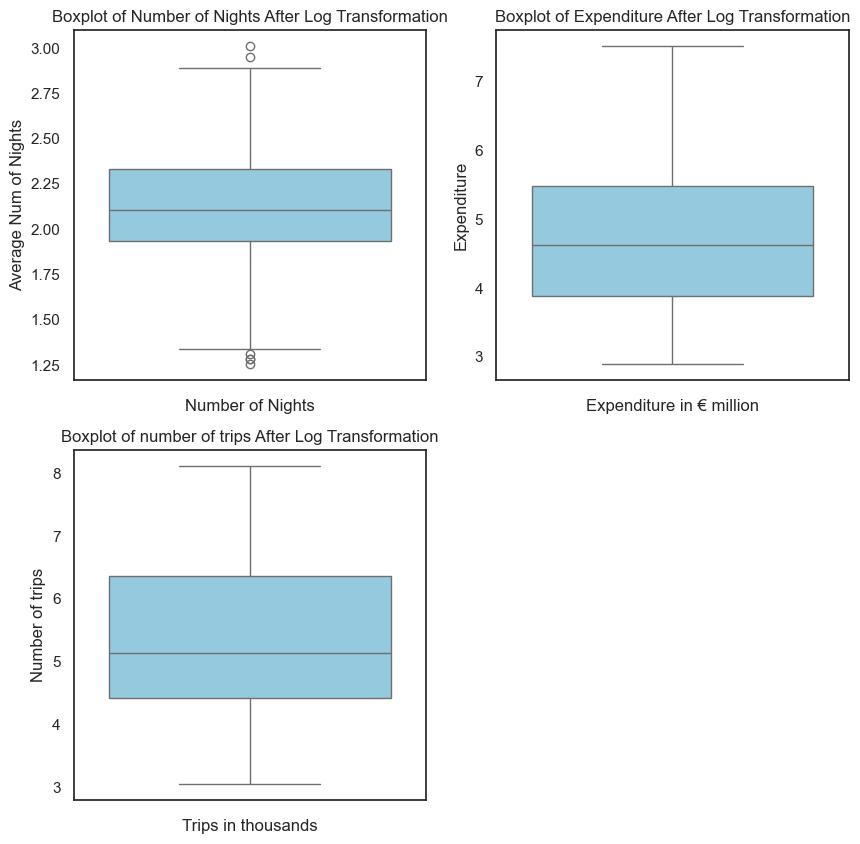

In [1770]:
# Set the style of the visualizations
sns.set_style("white")

# Create a figure with subplots
plt.figure(figsize=(10, 10))

# Boxplot for number of nights
plt.subplot(2, 2, 1) 
sns.boxplot( data= log_tf_data['Average Num of Nights'], color='skyblue')
plt.title('Boxplot of Number of Nights After Log Transformation')
plt.xlabel('Number of Nights')

# Boxplot for expenditure 
plt.subplot(2, 2, 2) 
sns.boxplot(data= log_tf_data['Expenditure'], color= 'skyblue')
plt.title('Boxplot of Expenditure After Log Transformation')
plt.xlabel('Expenditure in € million')


# Boxplot for number of trips
plt.subplot(2, 2, 3) 
sns.boxplot(data= log_tf_data['Number of trips'], color= 'skyblue')
plt.title('Boxplot of number of trips After Log Transformation')
plt.xlabel('Trips in thousands')

plt.show()

**Interpretation**: the effect of the outliers has been reduced as it can be seen on the boxplot of expenditure and trips. However, the remaining outliers in number of nights feature should be capped to third standard deviation, making outliers fall into 99.7% of data. The advantage of capping data is that it prevents the loss of important data and it follows that normal distribution's (68-95-99.7 Rule).

### **EDA and Statistics: Plotting normal distribution**

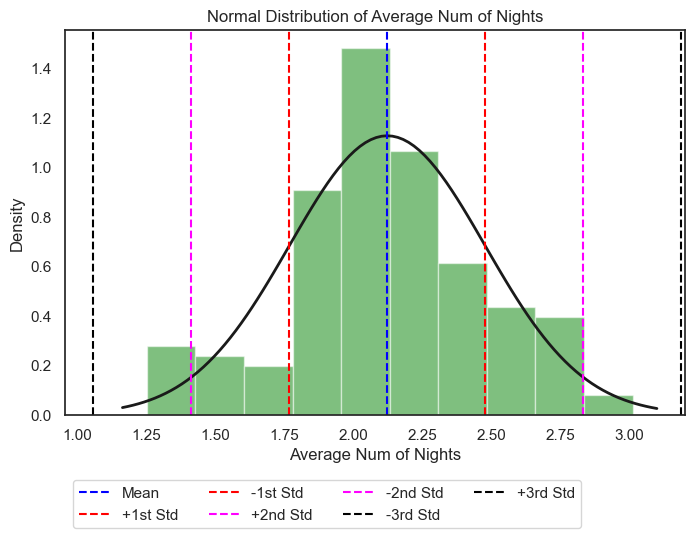

In [1773]:
from scipy import stats

# Checking normal distribution for average number of nights
normalise_nights = log_tf_data['Average Num of Nights']

std_dev = np.std(normalise_nights, ddof=1)
mean = np.mean(normalise_nights) 
                  
# Plotting histogram and overlaying normal distribution
plt.figure(figsize=(8, 5))
plt.hist(normalise_nights, bins=10, density=True, alpha=0.5, color='green')

# Fit a normal distribution
mu, std = stats.norm.fit(normalise_nights)

# Plot the normal distribution curve
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

#Add a verticle line for mean, standard deviation
plt.axvline(mean, color='blue', linestyle='--', label = 'Mean')
plt.axvline(mean + std_dev, color='red', linestyle='--', label = '+1st Std')
plt.axvline(mean - std_dev, color='red', linestyle='--', label = '-1st Std')
plt.axvline(mean + 2*std_dev, color='magenta', linestyle='--', label = '+2nd Std')
plt.axvline(mean - 2*std_dev, color='magenta', linestyle='--', label = '-2nd Std')
plt.axvline(mean - 3*std_dev, color='black', linestyle='--', label = '-3rd Std')
plt.axvline(mean + 3*std_dev, color='black', linestyle='--', label = '+3rd Std')

plt.title('Normal Distribution of Average Num of Nights')
plt.xlabel('Average Num of Nights')
plt.ylabel('Density')
plt.legend(loc='upper left', bbox_to_anchor=(0, -0.15), ncol=4)
plt.show()

**Interpretation:** The mean of the average number of nights is 2.1 nights. 68% of values or 1st standard deviation falls between 1.75 and 2.5 nights. 

95% of the data or 2nd standard deviation falls between 1.4 and 2.75. 99% of the data or 3rd standard deviation falls between 1 and 3.

#### Outliers capped to third standard deviation

In [1776]:
from scipy.stats.mstats import winsorize
log_tf_data['Average Num of Nights'] = winsorize(log_tf_data['Average Num of Nights'], limits=[0.05, 0.05])

**Programming:** winsorize function is imported from SciPy library. The function transform and caps the outliers from 'Average Num of Nights' feature to third standard deviation with limits=[0.05,0.05]

### Log Transformation after Winsorization

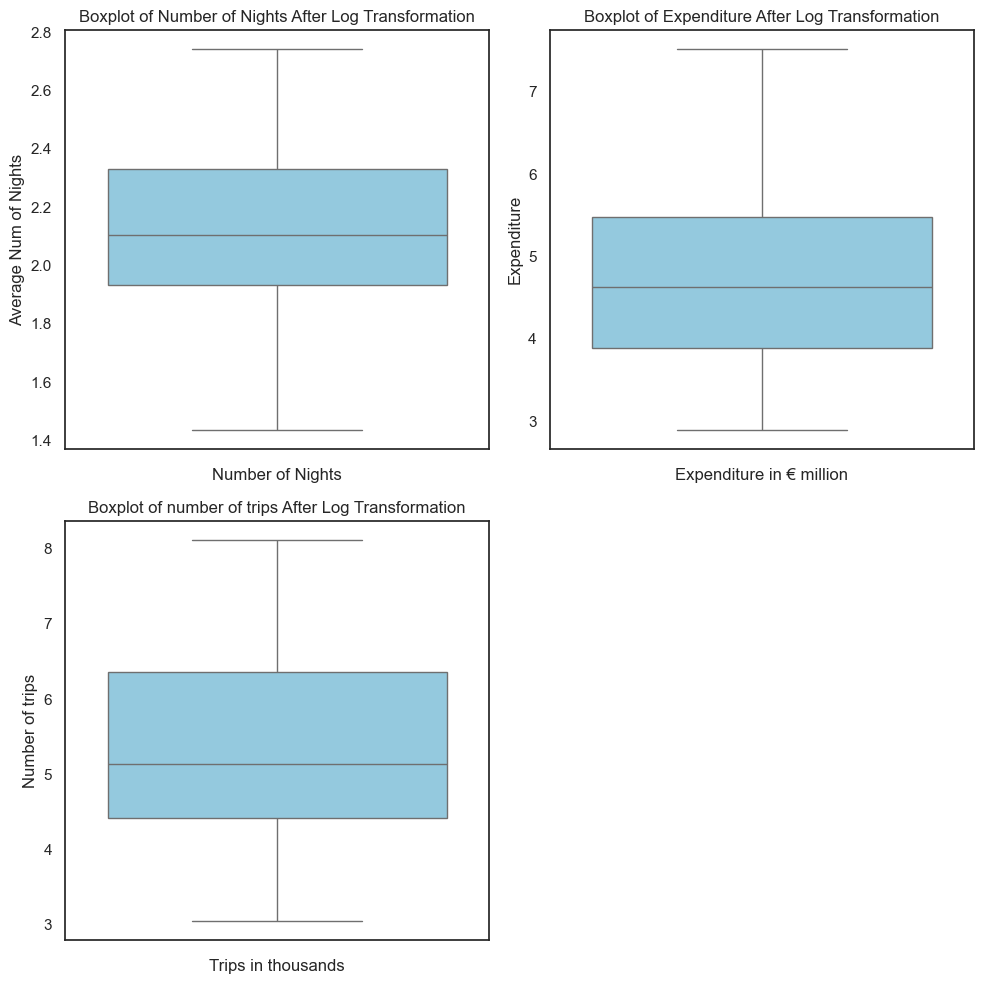

In [1779]:
# Set the style of the visualizations
sns.set_style("white")

# Create a figure with subplots
plt.figure(figsize=(10, 10))

# Boxplot for number of nights
plt.subplot(2, 2, 1) 
sns.boxplot( data= log_tf_data['Average Num of Nights'], color='skyblue')
plt.title('Boxplot of Number of Nights After Log Transformation')
plt.xlabel('Number of Nights')

# Boxplot for expenditure 
plt.subplot(2, 2, 2) 
sns.boxplot(data= log_tf_data['Expenditure'], color= 'skyblue')
plt.title('Boxplot of Expenditure After Log Transformation')
plt.xlabel('Expenditure in € million')


# Boxplot for number of trips
plt.subplot(2, 2, 3) 
sns.boxplot(data= log_tf_data['Number of trips'], color= 'skyblue')
plt.title('Boxplot of number of trips After Log Transformation')
plt.xlabel('Trips in thousands')

plt.tight_layout()
plt.show()

**Interpretation**: 

Average Number of Nights: Outliers are capped between lower and upper bound. The newly winsorized data represents that 25th percentile of data falls within range of 1.9 nights on average. 50th percentile of data is into 2.1 nights on average and 75th percentile of data says that average number of nights spent in Ireland is 2.3. The maximum threshold can be seen around average 2.7 nights, whereas the minimum threshold exists around average 1.5 nights. The median, 50th percentile slightly close to 25th percentile, the spread of data remain slightly right-skewed.

Expenditure: After log transformation, 25th percentile of the boxplot begins nearly 4 million Euros, 4.5 million Euros by oversea traveller expenditure in Ireland can be seen in the 50th percentile of the data, and 75th percentile of the expenditure data is 5.5 million Euros. The lower bound of the data is approximately 3 million in Euros, while the upper bound is 8 million Euros.  Although the distribution is positively-skewed, the median is halfway to the middle of 25th percentile and 50th percentile, which means that the distribution is closer to the normal distribution. 

Number of trips: 25th percentile of the boxplot begins with 4.5 thousands trips. The 50th percentile of the data represents 5.1 thounsands trips, and nearly 6.5 thousands trips are in 75th percentile of the trip data. The lower bound of the data falls approximately into 3,000 trips, while the upper bound is 8,000 trips.  The distribution remains positively-skewed because the median is closer to the 25th percentile or Quartile 1.

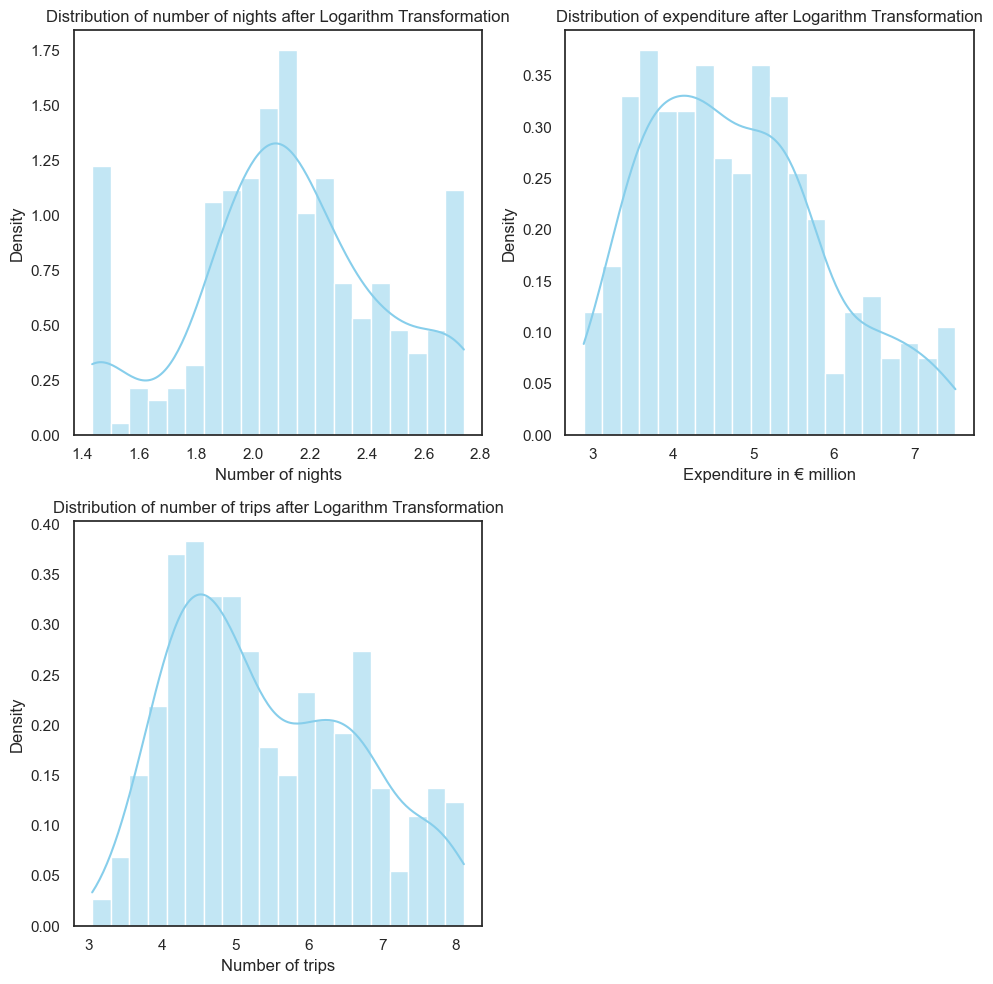

In [1781]:
sns.set(style="white")
plt.figure(figsize=(10, 10))

# Plot for expenditure Length
plt.subplot(2, 2, 1)  # (rows, columns, panel number)
sns.histplot(log_tf_data['Average Num of Nights'], bins=20, kde=True, color='skyblue', stat="density", )
plt.title('Distribution of number of nights after Logarithm Transformation')
plt.xlabel('Number of nights')
plt.ylabel('Density')

# Plot for expenditure Length
plt.subplot(2, 2, 2)  # (rows, columns, panel number)
sns.histplot(log_tf_data['Expenditure'], bins=20, kde=True, color='skyblue', stat="density", )
plt.title('Distribution of expenditure after Logarithm Transformation')
plt.xlabel('Expenditure in € million')
plt.ylabel('Density')

# Plot for expenditure Length
plt.subplot(2, 2, 3)  # (rows, columns, panel number)
sns.histplot(log_tf_data['Number of trips'], bins=20, kde=True, color='skyblue', stat="density", )
plt.title('Distribution of number of trips after Logarithm Transformation')
plt.xlabel('Number of trips')
plt.ylabel('Density')


# Show the plots
plt.tight_layout()
plt.show()

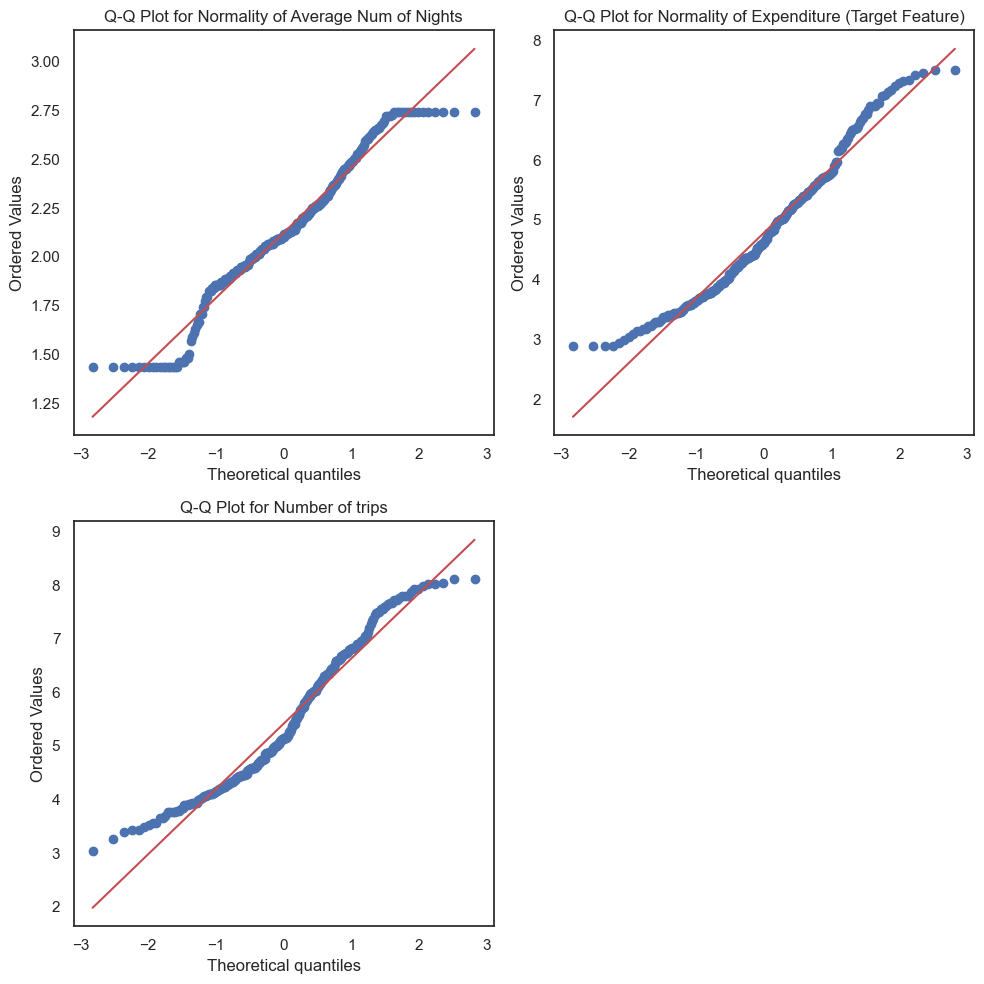

In [1782]:
#checking normality
import scipy.stats as stats

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)  # (rows, columns, panel number)
stats.probplot(log_tf_data['Average Num of Nights'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality of Average Num of Nights')

plt.subplot(2, 2, 2)  # (rows, columns, panel number)
stats.probplot(log_tf_data['Expenditure'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality of Expenditure (Target Feature)')

plt.subplot(2, 2, 3)  # (rows, columns, panel number)
stats.probplot(log_tf_data['Number of trips'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Number of trips')

plt.tight_layout()
plt.show()

**Interpretation:** All plots are close to achieving normality of theoretical quantiles. However, the S shapes suggest that the skewness still exists in all plots.  This is due to low and high extreme values in the dataset.

**Programming:** Q-Q plot (Quantile-Quantile Plot)'s purpose is to check the normality of data against theretical quantiles. The library scipy.stat is imported from Scipy library. 

plt.figure set the width and size of the figures. plt.subplot is display and compare the plots side by side. stats.probplot generates a probability plot of sample data against the quantiles of a specified theoretical distribution (the normal distribution by default)[(SciPy community, 2025)](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html). dist="norm" sets to display normal distribution's quantiles. plot=plt to access matplotlib.pyplot module with given dataset. plt.title sets the title for the Q-Q plots

### Checking outliers after log transformation and winzorization

#### **Detecting outliers using Z-score method 

In [1787]:
from scipy import stats

# Example 1
night_outliers = np.array(log_tf_data['Average Num of Nights'])
z_scores1 = stats.zscore(night_outliers)
outliers_zscore1 = night_outliers[(z_scores1 > 3) | (z_scores1 < -3)]
print(f"Outlier score of Average number of nights: {outliers_zscore1}")

expenditure_outliers = np.array(log_tf_data['Expenditure'])
z_scores1 = stats.zscore(expenditure_outliers)
outliers_zscore1 = expenditure_outliers[(z_scores1 > 3) | (z_scores1 < -3)]
print(f"Outlier score of Average number of nights: {outliers_zscore1}")

trip_outliers = np.array(log_tf_data['Number of trips'])
z_scores1 = stats.zscore(trip_outliers)
outliers_zscore1 = trip_outliers[(z_scores1 > 3) | (z_scores1 < -3)]
print(f"Outlier score of Average number of nights: {outliers_zscore1}")

Outlier score of Average number of nights: []
Outlier score of Average number of nights: []
Outlier score of Average number of nights: []


#### **Detecting outliers using IQR method 

In [1789]:
# Function to detect outliers using IQR
def detect_outliers_iqr(abnormal):
    Q1 = np.percentile(abnormal, 25)
    Q3 = np.percentile(abnormal, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = abnormal[(abnormal < lower_bound) | (abnormal > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_night = np.array(log_tf_data['Average Num of Nights'])
outlier_exp = np.array(log_tf_data['Expenditure'])
outlier_trips = np.array(log_tf_data['Number of trips'])

outliers_n, lower_bound_n, upper_bound_n = detect_outliers_iqr(outlier_night)
outliers_e, lower_bound_e, upper_bound_e = detect_outliers_iqr(outlier_exp)
outliers_t, lower_bound_t, upper_bound_t = detect_outliers_iqr(outlier_trips)

print(f"Outlier: Average number of nights:{outliers_n}")
print(f"Lower Bound_Nights: {lower_bound_n:.2f}")
print(f"Upper Bound_Nights: {upper_bound_n:.2f}\n")

print(f"Outlier: Expenditure:{outliers_e}")
print(f"Lower Bound_Expenditure: {lower_bound_e:.2f}")
print(f"Upper Bound_Expenditure: {upper_bound_e:.2f}\n")

print(f"Outlier: Number of trips:{outliers_t}")
print(f"Lower Bound_Trips: {lower_bound_t:.2f}")
print(f"Upper Bound_Trips: {upper_bound_t:.2f}\n")

Outlier: Average number of nights:[]
Lower Bound_Nights: 1.33
Upper Bound_Nights: 2.93

Outlier: Expenditure:[]
Lower Bound_Expenditure: 1.50
Upper Bound_Expenditure: 7.87

Outlier: Number of trips:[]
Lower Bound_Trips: 1.51
Upper Bound_Trips: 9.27



**Programming:** detect_outlier_iqr function is used as a block of reusable code for detecting outliers for each feature. 

Inside the function name, data argument is declared.  Q1 variable name is defined to calculate 25th percentile. Q3 variable name is defined to calculate 75th percentile. IQR variable will calculate the difference between Q3 and Q1. 

lower_bound is calcuated by multiplying k value (1.5) with the value of IQR and substracting with Q1. upper_bound is calcuated by multiplying k value (1.5) with the value of IQR and adding with Q3. 

The data that are below lower bound and above upper bound are outliers. outliers variable is declared inside the function by selecting data below lower_bound and above upper_bound with [] square to extract dataframe. The function is to return the outliers, lower_bound, and upper_bound

outlier_night, outlier_exp, outlier_trips are created to turn log transformed feature into array. Turning array to each feature makes IQR calculation faster for Python function. 

After calculation, the following variable names are stored to invoke the function and calcuate the outliers, lower and upper bound for each feature:  

+ outliers_n, lower_bound_n, upper_bound_n 
+ outliers_e, lower_bound_e, upper_bound_e 
+ outliers_t, lower_bound_t, upper_bound_t

Series of f strings are called to print the result. 

##### **Skewness After Log Transformation**

## Skewness

Skewness measures the asymmetry of the probability distribution of a real-valued random variable.

### Interpretation:
- **Positive Skewness** (\( > 0 \)): Indicates that the tail on the right side of the distribution is longer or fatter than the left side. This often suggests that there are a few high-value outliers. For example, income distribution in a population often shows positive skewness due to a small number of very high incomes.
- **Negative Skewness** (\( < 0 \)): Indicates that the tail on the left side of the distribution is longer or fatter than the right side. This means there are a few low-value outliers. For example, the age of retirement could show negative skewness if a significant number of individuals retire earlier than average.
- **Zero Skewness**: Indicates a symmetrical distribution, such as a normal distribution.

### Formula:
$$
\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum \left( \frac{x_i - \bar{x}}{s} \right)^3
$$

### Limitations:
- Skewness alone does not indicate the presence of outliers; further analysis is often needed.
- Interpretation can be subjective; a skewness value close to zero may still indicate a practical asymmetry in some contexts.


In [1793]:
features = ['Average Num of Nights', 'Expenditure', 'Number of trips']
for i in features:
    skew = log_tf_data[i].skew()
    print(f"Skewness for {i}: {skew:.2f}")

Skewness for Average Num of Nights: -0.13
Skewness for Expenditure: 0.51
Skewness for Number of trips: 0.42


1. Skewness of Average Num of Nights: -0.13

A mild negative skewness value indicates that the distribution of 'Average Num of Nights' is slightly left-skewed (or negatively skewed). This means that the left tail of the distribution is longer or fatter than the right tail. The mild negative skewness suggests that the distribution is near normal distribution as data points is around mean.


2. Skewness of Expenditure: 0.51

The positive skewness value for expenditure says that the distribution is also positively-skewed. This means that the right tail of the distribution is longer or fatter than the left tail. As majority of people less, high spender are clustered around the right end.

3. Skewness of Number of trips: 0.42

Similarly, the number of trips data has moderately right-skewed data distribution. As more people taking few and fewer than the average tends to be on the left on the histrogram, the number of trips taken by anomaly travellers exists on the right higher end.  

##### **Kurtosis After Log Transformation** 

## Kurtosis

Kurtosis measures the "tailedness" of a probability distribution and indicates the presence of outliers in the dataset.

### Interpretation:
- **High Kurtosis** (> 3): Indicates that the dataset has heavy tails or outliers. This means that extreme values are more frequent than expected in a normal distribution. For example, financial datasets often show high kurtosis due to the presence of extreme losses or gains.
- **Low Kurtosis** (< 3): Indicates that the dataset has lighter tails than a normal distribution. This implies that extreme values are less frequent, which is common in datasets with bounded or limited range.

### Formula:
$$
\text{Kurtosis} = \frac{n(n+1)}{(n-1)(n-2)(n-3)} \sum \left( \frac{x_i - \bar{x}}{s} \right)^4 - \frac{3(n-1)^2}{(n-2)(n-3)}
$$

### Limitations:
- Kurtosis can be affected by outliers themselves, leading to misleading interpretations.
- Interpretation can vary; what is considered "high" or "low" kurtosis may depend on the context of the data.


Depending on the degree, distributions have three types of kurtosis [(DataCamp,2023)](https://www.datacamp.com/tutorial/understanding-skewness-and-kurtosis):

+ Mesokurtic distribution (kurtosis = 3, excess kurtosis = 0): perfect normal distribution or very close to it.
+ Leptokurtic distribution (kurtosis > 3, excess kurtosis > 0): sharp peak, heavy tails
+ Platykurtic distribution (kurtosis < 3, excess kurtosis < 0): flat peak, light tails 


In [1798]:
from scipy.stats import kurtosis

features = ['Average Num of Nights', 'Expenditure', 'Number of trips']
for i in features:
    k = kurtosis(log_tf_data[i])
    print(f"Kurtosis for {i}: {k:.2f}")

Kurtosis for Average Num of Nights: -0.28
Kurtosis for Expenditure: -0.43
Kurtosis for Number of trips: -0.85


**Interpretation of Kurtosis Values**

1. Kurtosis for Average Num of Nights: -0.28

Normal distribution has zero kurtosis. This negative kurtosis value indicates that the distribution of Average Num of Nights is platykurtic. The distribution is broader than normal distribution. Sight negative skewness with less values around the mean on is on this spread of data.

2. Kurtosis of Expenditure: -0.43

The negative kurtosis value represents that the distribution is flatter than normal distribution and than the distribution of Average Num of Nights. It is more lighter tails than normal distribution. Travellers who spend heavily are not extreme outliers.

3. Kurtosis for Number of trips: -0.85

The distribution has the highest negative kurtosis among all features. It possesses extremely light tails and a lower likelihood of extreme events. It can be infered that the number of trips that people had gone varied across dataset. 

### 2.1 Treating outliers: Square Root Transformation

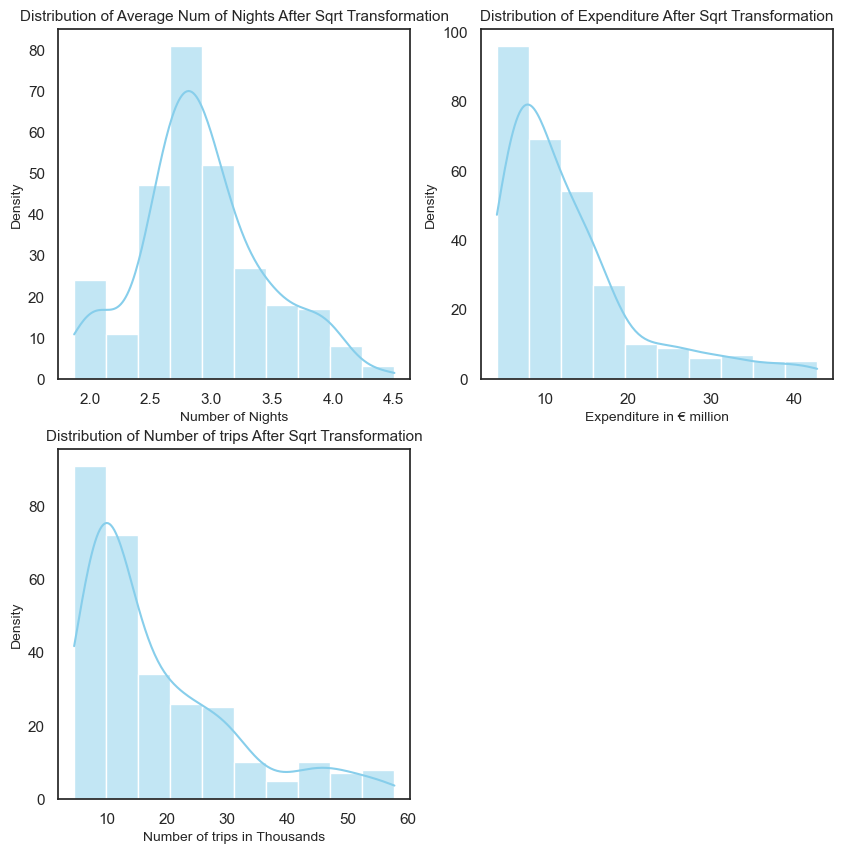

In [1801]:
sqrt_transform = reshape_data.copy()

# Create a figure with subplots
plt.figure(figsize=(10, 10))

#Histogram for Average Number of Nights
plt.subplot(2, 2, 1) # (rows, columns, panel number)
sqrt_transform['Average Num of Nights'] = np.sqrt(reshape_data['Average Num of Nights'])
sns.histplot(data = sqrt_transform['Average Num of Nights'], bins = 10, kde= True, color='skyblue')
plt.xlabel('Number of Nights' , fontsize = 10)
plt.ylabel('Density', fontsize =10)
plt.title('Distribution of Average Num of Nights After Sqrt Transformation', fontsize=11)

#Histogram for Expenditure
plt.subplot(2, 2, 2) # (rows, columns, panel number)
sqrt_transform['Expenditure'] = np.sqrt(reshape_data['Expenditure'])
sns.histplot(data = sqrt_transform['Expenditure'], bins = 10, kde= True, color='skyblue')
plt.xlabel('Expenditure in € million', fontsize = 10)
plt.ylabel('Density', fontsize =10)
plt.title('Distribution of Expenditure After Sqrt Transformation', fontsize=11)

#Histogram for Average Number of Trips
plt.subplot(2, 2, 3) # (rows, columns, panel number)
sqrt_transform['Number of trips'] = np.sqrt(reshape_data['Number of trips'])
sns.histplot(data = sqrt_transform['Number of trips'], bins = 10, kde= True, color='skyblue')
plt.xlabel('Number of trips in Thousands', fontsize=10)
plt.ylabel('Density', fontsize = 10)
plt.title('Distribution of Number of trips After Sqrt Transformation', fontsize=11)

plt.show()

**Interpretation**: Three histograms: Average Num of Nights, Expenditure, and Number of trips are plotted after square root transformation.

On the plot of Average Num of Nights, the distribution is closer to a normal distribution compared to the two other plots. However, the long tail on the right remains visible after transformation. Transformation affects the small value; the small value on the left side of the histogram influences the shape.

On the expenditure histrogram, the skewness remained right-skewed and skewness is reduced. The normality does not achieve after transformation. The spread of data is skewed to the right because of the extremely high value in expenditure dataset.

On the trip histrogram, the rigth skewness remains in shape. The distribution does not fully normalize to the normal distribution.

Therefore, it can be concluded that square root transformation reduce the influcene of outliers. However, it does not fully transform to achieve normal distribution and the effect of transformation is lesser than log transformation method.

**Programming**: 'sqrt_transform' variable is to store dataframe which copies the 'reshape_data' using .copy() method. .copy() method ensures the original dataset is not affected by the new dataset, 'log_tf_data'.

After square root transformation. the data is plotted to see the spread of data. sns.set(style='white') sets the background to white. sns.histplot is to plot the histogram of the data and the values are thrown to 10 bins to give the spread of data. kde=True, Kernel Density Estimate is to plot the shape of the data and show the smoothness of the curve.

#### Treating Outliers: Displaying Boxplot After Square Root Transformation

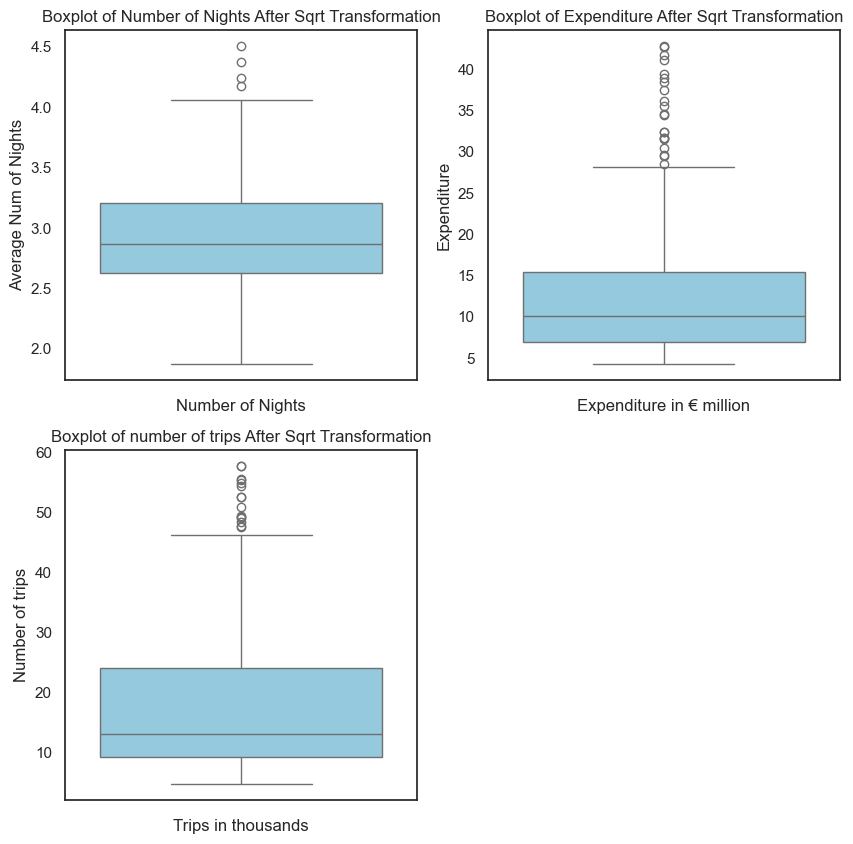

In [1805]:
# Set the style of the visualizations
sns.set_style("white")

# Create a figure with subplots
plt.figure(figsize=(10, 10))

# Boxplot for number of nights
plt.subplot(2, 2, 1) 
sns.boxplot( data= sqrt_transform['Average Num of Nights'], color='skyblue')
plt.title('Boxplot of Number of Nights After Sqrt Transformation')
plt.xlabel('Number of Nights')

# Boxplot for expenditure 
plt.subplot(2, 2, 2) 
sns.boxplot(data= sqrt_transform['Expenditure'], color= 'skyblue')
plt.title('Boxplot of Expenditure After Sqrt Transformation')
plt.xlabel('Expenditure in € million')


# Boxplot for number of trips
plt.subplot(2, 2, 3) 
sns.boxplot(data= sqrt_transform['Number of trips'], color= 'skyblue')
plt.title('Boxplot of number of trips After Sqrt Transformation')
plt.xlabel('Trips in thousands')

plt.show()

**Interpretation**: The presence of outliers can be seen on all boxplot after square root transformation.

Boxplot of Average Number of Nights: 25th percentile of the boxplot begins with 2.6 nights on average, 50th percentile of the data represents 2.9 nights on average, and 75th percentile of the data falls into the range of 3.3 nights on average. The lower bound of the data is 2 nights on average, whereas the upper bound is 4 nights on average. Outliers can be observed beyond the upper bound. The distribution is right-skewed because the median is closer to the 25th percentile.

Boxplot of Expenditure: 25th percentile of the boxplot begins with 7.5 million Euros, 10 million Euros in oversea travel expenditure by non-residents can be seen in the 50th percentile of the data, and 75th percentile of the expenditure data is 15 million Euros. The lower bound of the data is approximately 5 million in Euros, while the upper bound is 27 million Euros. The distribution is positively-skewed because the median is closer to the 25th percentile or Quartile 1.

Boxplot of Number of trips: 25th percentile of the boxplot begins with 10,000 trips. The 50th percentile of the data represents 12,000 trips, and 25,000 trips are in 75th percentile of the trip data. The lower bound of the data falls approximately into 3,000 trips, while the upper bound is 48,000 trips. The distribution is positively-skewed because the median is closer to the 25th percentile or Quartile 1.

### 2.2 Treating outliers: Cube Root Transformation

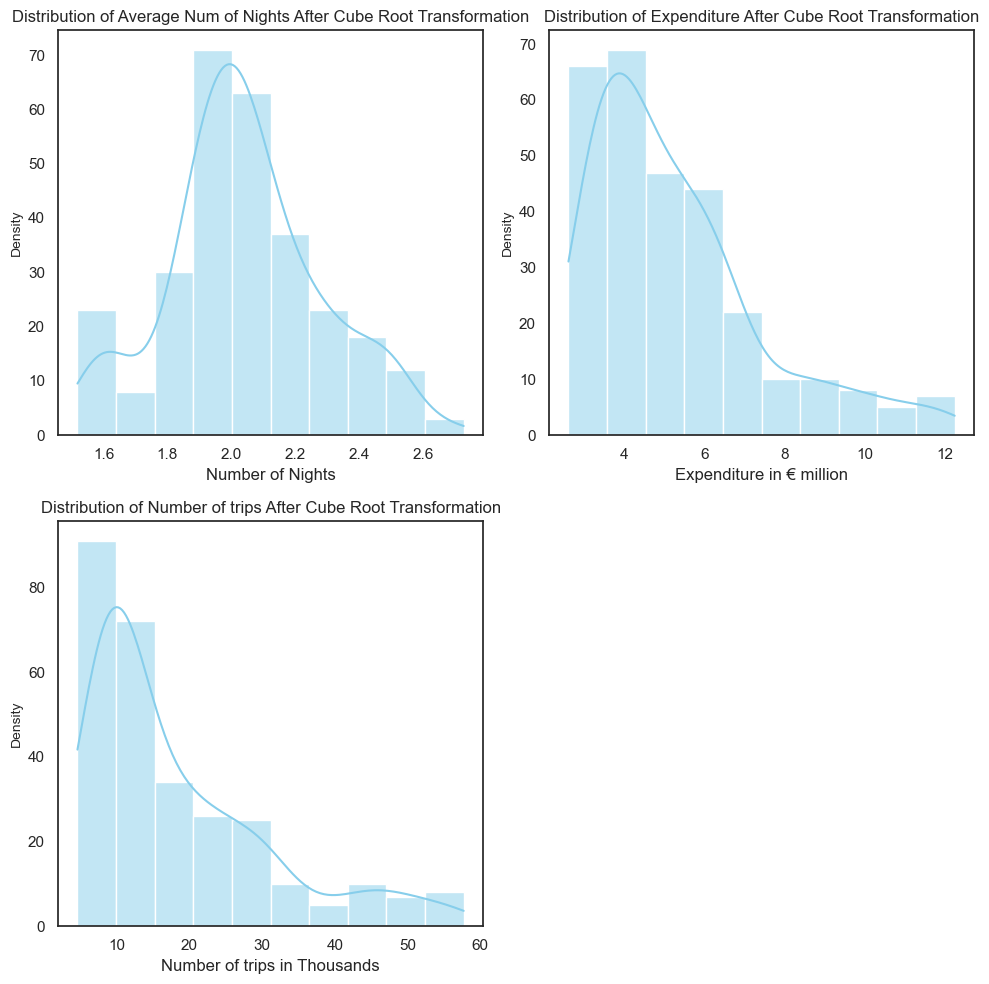

In [1808]:
cube_transform = reshape_data.copy()

# Create a figure with subplots
plt.figure(figsize=(10, 10))

#Histogram for Average Number of Nights
plt.subplot(2, 2, 1) # (rows, columns, panel number)

cube_transform['Average Num of Nights'] = np.cbrt(reshape_data['Average Num of Nights'])
sns.histplot(data = cube_transform['Average Num of Nights'], bins = 10, kde= True, color='skyblue')
plt.xlabel('Number of Nights' )
plt.ylabel('Density', fontsize =10)
plt.title('Distribution of Average Num of Nights After Cube Root Transformation')

#Histogram for Expenditure
plt.subplot(2, 2, 2) # (rows, columns, panel number)
cube_transform['Expenditure'] = np.cbrt(reshape_data['Expenditure'])
sns.histplot(data = cube_transform['Expenditure'], bins = 10, kde= True, color='skyblue')
plt.xlabel('Expenditure in € million')
plt.ylabel('Density', fontsize =10)
plt.title('Distribution of Expenditure After Cube Root Transformation')

#Histogram for Average Number of Trips
plt.subplot(2, 2, 3) # (rows, columns, panel number)
cube_transform['Number of trips'] = np.cbrt(reshape_data['Number of trips'])
sns.histplot(data = sqrt_transform['Number of trips'], bins = 10, kde= True, color='skyblue')
plt.xlabel('Number of trips in Thousands')
plt.ylabel('Density', fontsize = 10)
plt.title('Distribution of Number of trips After Cube Root Transformation')

plt.tight_layout()

plt.show()

**Interpretation**: Three histograms: Average Num of Nights, Expenditure, and Number of trips are plotted after square root transformation.

On the plot of Average Num of Nights, the distribution is close to a normal distribution compared to the two other plots. However, the thick tail on the right remains visible after transformation. Transformation affects the small value; the small values on the left side of the shape of the histogram. 

On the expenditure histogram, the skewness remained right-skewed and skewness is reduced. The normality is not achieved after transformation. The spread of data is skewed to the right because of the extremely high value in the expenditure dataset. The low spenders are clustered at the left side of the distribution.

On the trip histrogram, the right skewness remains in shape. The distribution does not fully normalize to the normal distribution.

Therefore, it can be concluded that cube root transformation reduces the influcene of outliers. However, it does not fully transform to achieve normal distribution, and the effect of the transformation is less than the log transformation method.

Therefore, this project decides to use log-transformed data (log_tf_data) for data preprocessing, machine learning, and prediction. 

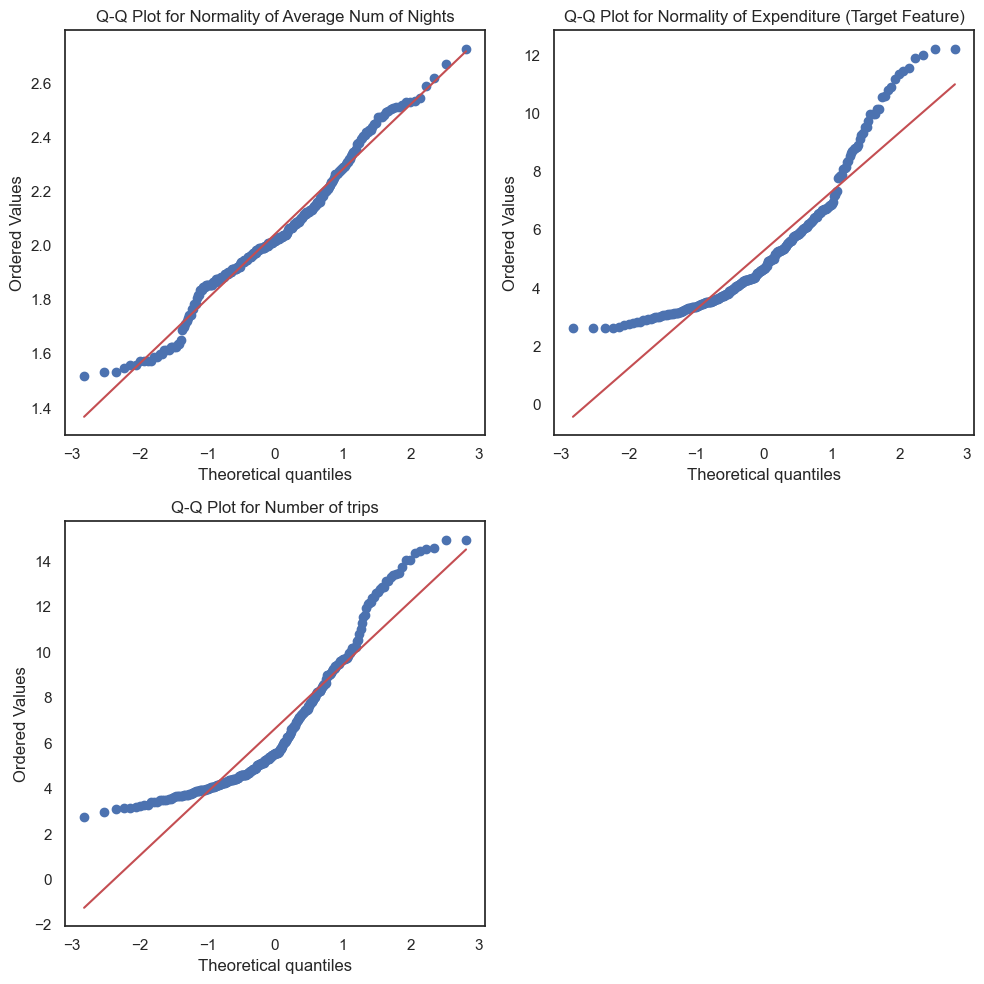

In [1810]:
#checking normality
import scipy.stats as stats

plt.figure(figsize=(10, 10))
plt.subplot(2, 2, 1)  # (rows, columns, panel number)
stats.probplot(cube_transform['Average Num of Nights'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality of Average Num of Nights')

plt.subplot(2, 2, 2)  # (rows, columns, panel number)
stats.probplot(cube_transform['Expenditure'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Normality of Expenditure (Target Feature)')

plt.subplot(2, 2, 3)  # (rows, columns, panel number)
stats.probplot(cube_transform['Number of trips'], dist="norm", plot=plt)
plt.title('Q-Q Plot for Number of trips')

plt.tight_layout()
plt.show()

**Interpretation:** Q-Q plots show how much the data points fall and overlap with the theoretical quantiles of normal distribution. 

QQ plot of Average Num of Nights: the points where the data point and theoretical quantiles met were -2, -1.5, from -1 to 1, and 2. The plot has more data points meeting the theoretical quantiles criteria. However, it does not fully represent the normal distribution. 

QQ plot of Expenditure: the points where the data point and theoretical quantiles met were at -1 and at 1. The value between 1 and -1 is close to the theoretical quantiles. However, all other points are away from normal distribution due to the extreme value presence in the dataset. 

QQ plot of Number of trips: the points where the data point and theoretical quantiles met were at -1, from 0.5 to 1. All other points are away from theoretical quantiles. 

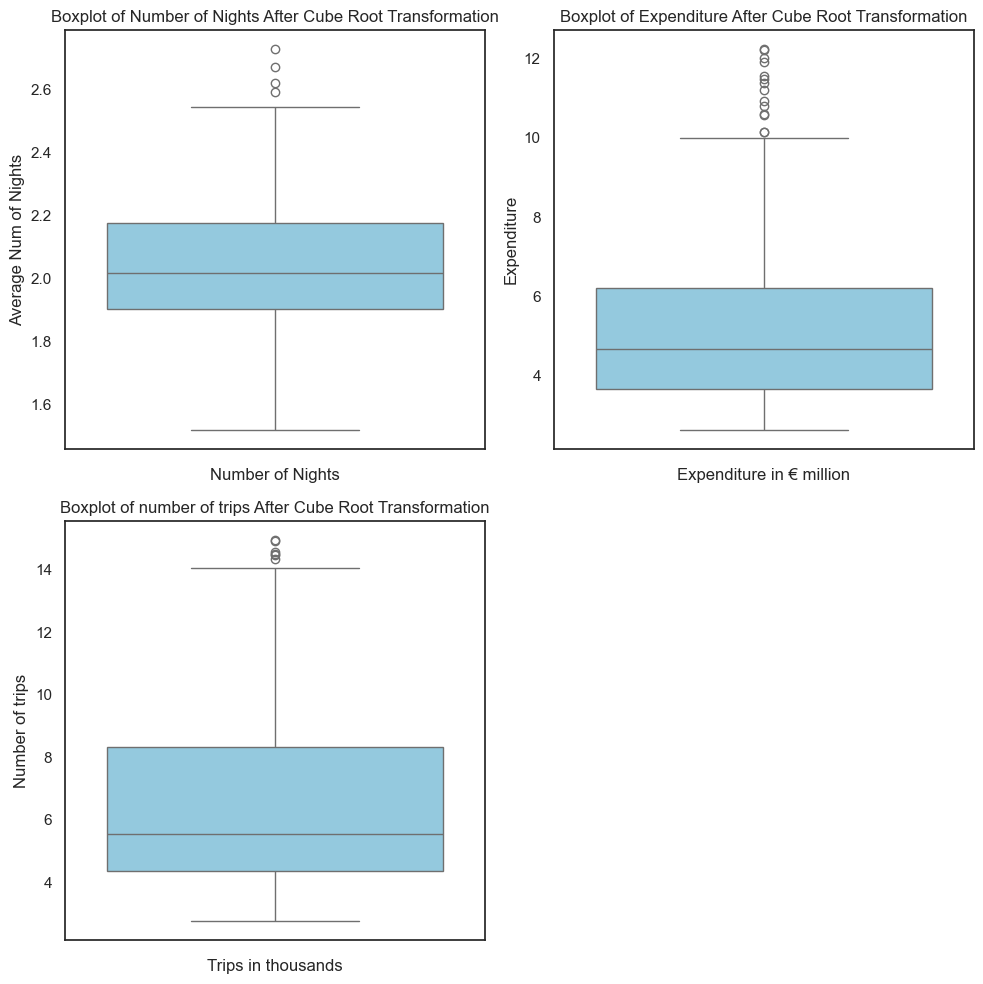

In [1812]:
# Set the style of the visualizations
sns.set_style("white")

# Create a figure with subplots
plt.figure(figsize=(10, 10))

# Boxplot for number of nights
plt.subplot(2, 2, 1) 
sns.boxplot(data= cube_transform['Average Num of Nights'], color='skyblue')
plt.title('Boxplot of Number of Nights After Cube Root Transformation')
plt.xlabel('Number of Nights')

# Boxplot for expenditure 
plt.subplot(2, 2, 2) 
sns.boxplot(data= cube_transform['Expenditure'], color= 'skyblue')
plt.title('Boxplot of Expenditure After Cube Root Transformation')
plt.xlabel('Expenditure in € million')


# Boxplot for number of trips
plt.subplot(2, 2, 3) 
sns.boxplot(data= cube_transform['Number of trips'], color= 'skyblue')
plt.title('Boxplot of number of trips After Cube Root Transformation')
plt.xlabel('Trips in thousands')

plt.tight_layout()

plt.show()

**Interpretation**: Outliers are present in all three features. The transformation does not fully reduce the influence of the outliers. However, the right skewness of data is reduced. This is because the mixture of specific categories like all countries tends to dominate the data and affect the spread of distribution.

### Cube Root Transformation after Winsorization

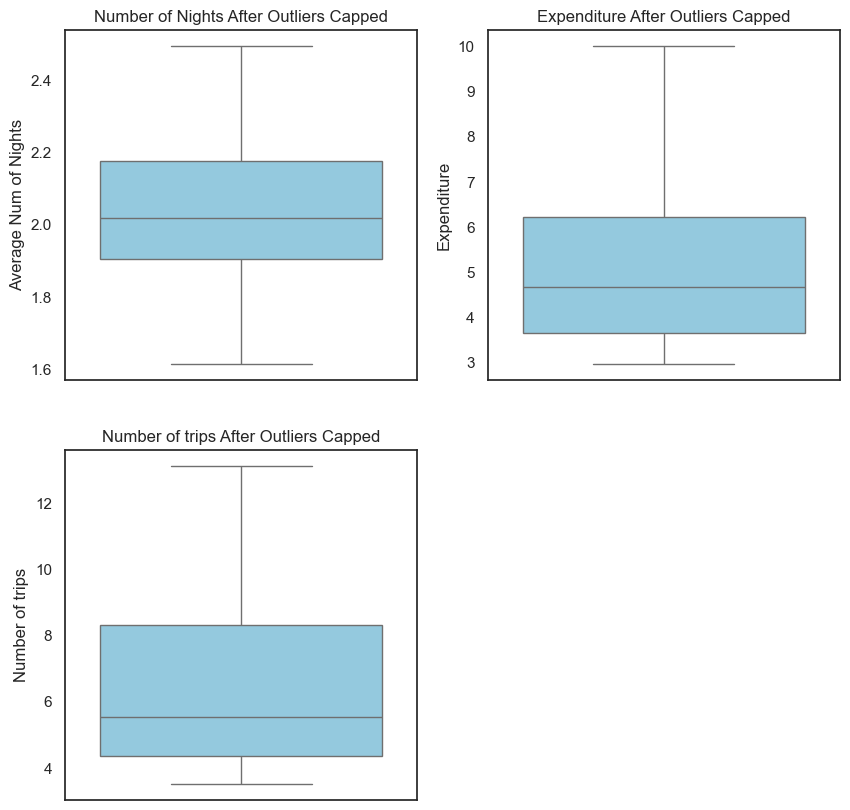

In [1815]:
from scipy.stats.mstats import winsorize
# Set the style of the visualizations
sns.set_style("white")

# Create a figure with subplots
plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)  # (rows, columns, panel number)
cube_transform['Average Num of Nights'] = winsorize(cube_transform['Average Num of Nights'], limits=[0.05, 0.05]) #limit cap the value within 5th and 95th percentile
sns.boxplot(y=cube_transform['Average Num of Nights'], color= 'skyblue')
plt.title("Number of Nights After Outliers Capped")


plt.subplot(2, 2, 2)  # (rows, columns, panel number)
cube_transform['Expenditure'] = winsorize(cube_transform['Expenditure'], limits=[0.05, 0.05])
sns.boxplot(y=cube_transform['Expenditure'], color= 'skyblue')
plt.title("Expenditure After Outliers Capped")

plt.subplot(2, 2, 3)  # (rows, columns, panel number)
cube_transform['Number of trips'] = winsorize(cube_transform['Number of trips'], limits=[0.05, 0.05])
sns.boxplot(y=cube_transform['Number of trips'], color= 'skyblue')
plt.title("Number of trips After Outliers Capped")


plt.show()

**Interpretation**:

Average Number of Nights: Outliers are capped between lower and upper bound. The newly winsorized data represents that the 25th percentile of data falls within range of 1.9 nights on average. 50th percentile of data is 2.1 nights on average and 75th percentile of data says that average number of nights spent in Ireland is 2.2. The maximum threshold can be seen at an average 2.7 nights, whereas the minimum threshold exists at an average of 1.7 nights. The median, 50th percentile slightly closer to the 25th percentile; the spread of data remains slightly right-skewed.

Expenditure: After cube root transformation, 25th percentile of the boxplot begins nearly 3.5 million Euros, 4.7 million Euros by overseas traveller expenditure in Ireland can be seen in the 50th percentile of the data, and the 75th percentile of the expenditure data is 6.3 million Euros. The lower bound of the data is approximately 3 million in Euros, while the upper bound is 10 million Euros. Although the distribution is positively-skewed, the median is closer to 25th percentile and the 50th percentile, which means that the distribution is moderately skewed.

Number of trips: 25th percentile of the boxplot begins with 4200 trips. The 50th percentile of the data represents 5700 trips, and nearly 8200 thousands trips are in the 75th percentile of the trip data. The lower bound of the data falls approximately into 3,000 trips, while the upper bound is 13,000 trips. The distribution remains positively-skewed because the median is closer to the 25th percentile or Quartile 1.


#### Detecting outliers using IQR method on Cube Root Transformed Data

In [1818]:
# Function to detect outliers using IQR
def detect_outliers_iqr(abnormal):
    Q1 = np.percentile(abnormal, 25)
    Q3 = np.percentile(abnormal, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = abnormal[(abnormal < lower_bound) | (abnormal > upper_bound)]
    return outliers, lower_bound, upper_bound

outlier_night = np.array(cube_transform['Average Num of Nights'])
outlier_exp = np.array(cube_transform['Expenditure'])
outlier_trips = np.array(cube_transform['Number of trips'])

outliers_n, lower_bound_n, upper_bound_n = detect_outliers_iqr(outlier_night)
outliers_e, lower_bound_e, upper_bound_e = detect_outliers_iqr(outlier_exp)
outliers_t, lower_bound_t, upper_bound_t = detect_outliers_iqr(outlier_trips)

print(f"Outlier: Average number of nights:{outliers_n}")
print(f"Lower Bound_Nights: {lower_bound_n:.2f}")
print(f"Upper Bound_Nights: {upper_bound_n:.2f}\n")

print(f"Outlier: Expenditure:{outliers_e}")
print(f"Lower Bound_Expenditure: {lower_bound_e:.2f}")
print(f"Upper Bound_Expenditure: {upper_bound_e:.2f}\n")

print(f"Outlier: Number of trips:{outliers_t}")
print(f"Lower Bound_Trips: {lower_bound_t:.2f}")
print(f"Upper Bound_Trips: {upper_bound_t:.2f}\n")

Outlier: Average number of nights:[]
Lower Bound_Nights: 1.50
Upper Bound_Nights: 2.58

Outlier: Expenditure:[]
Lower Bound_Expenditure: -0.18
Upper Bound_Expenditure: 10.05

Outlier: Number of trips:[]
Lower Bound_Trips: -1.58
Upper Bound_Trips: 14.27



**Programming**: detect_outlier_iqr function is used as a block of reusable code for detecting outliers for each feature.

Inside the function name, the 'abnormal' argument is declared. Q1 variable name is defined to calculate the 25th percentile. Q3 variable name is defined to calculate the 75th percentile. The IQR variable will calculate the difference between Q3 and Q1.

lower_bound is calculated by multiplying the k value (1.5) with the value of IQR and subtracting from Q1. upper_bound is calculated by multiplying the k value (1.5) by the value of IQR and adding to Q3.

The data that are below the lower bound and above the upper bound are outliers. The outliers variable is declared inside the function by selecting data below lower_bound and above upper_bound with [] square brackets to extract a dataframe. The function is to return the outliers, lower_bound, and upper_bound

outlier_night, outlier_exp, outlier_trips are created to turn the log-transformed feature into an array. Turning the array to each feature makes the IQR calculation faster for the Python function.

After calculation, the following variable names are stored to invoke the function and calculate the outliers, lower and upper bound for each feature:

+ outliers_n, lower_bound_n, upper_bound_n
+ outliers_e, lower_bound_e, upper_bound_e
+ outliers_t, lower_bound_t, upper_bound_t

A series of f strings are called to print the result.

Note: The project decides to take on the log transformed data the transformation make it closer to normal distribution.

### **Machine Learning on Regression Task** 

In [1822]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#### **Applying Random Forest Regression on log transformed data without feature scaling**

When the maximum and min values of the data ranges are small, such as a range from 1.4 to 8 in this dataset, the scaling is not essential. Additionally, the Random Forest model is not dependent upon scaling features like ridge, support vector machine. Therefore, scaling features are omitted.

In [1825]:
# Prepare data
X1 = log_tf_data[['Average Num of Nights', 'Number of trips']] #Independent Variable
y1 = log_tf_data['Expenditure']  # Dependent Variable: Target feature

**Programming**: X variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'log_tf_data' dataframe.

y variable is assigned with the target feature, 'Expenditure' to predict the expenditure based on 'Number of trips'and 'Average Num of Nights'


In [1827]:
#Split the data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((288, 2), (288,), (230, 2), (58, 2), (230,), (58,))

Programming: Independent and dependent features are split into training and test subsets to pre-proccess the data ready for machine learing.

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of data goes to training and 20 percent of data goes to testing.

random_state = 42 is set to reproduce same train and test subset.

In [1829]:
#Train and fit the model
random_forest = RandomForestRegressor(n_estimators=50, random_state=42)
random_forest.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50, random_state=42)

*Programming*: random_forest creates the condition for Random Forest machine learning model with number of decision trees, n_estimators set at 50.

random_state=42 is to produce consistent results in splitting the data. .fit() method is used to train the model with scaled training data of independent features and unscaled training data for dependent feature.


In [1831]:
# Predict and evaluate
y_train_pred = random_forest.predict(X_train)
y_test_pred = random_forest.predict(X_test)

print("Model evaluation without scaling on log_transformed data:")
print("\n===Training Data===")
print(f"R²_train: {r2_score(y_train_pred, y_train_pred):.2f}")
print(f"MAE_train: {mean_absolute_error(y_train_pred, y_train_pred):.2f}")
print(f"MSE_train: {mean_squared_error(y_train_pred, y_train_pred):.2f}\n")


print("===Test Data===")
print(f"R²_test: {r2_score(y_test_pred, y_test_pred):.2f}")
print(f"MAE_test: {mean_absolute_error(y_test_pred, y_test_pred):.2f}")
print(f"MSE_test: {mean_squared_error(y_test_pred, y_test_pred):.2f}")

Model evaluation without scaling on log_transformed data:

===Training Data===
R²_train: 1.00
MAE_train: 0.00
MSE_train: 0.00

===Test Data===
R²_test: 1.00
MAE_test: 0.00
MSE_test: 0.00


**Interpretation**: 0 mean square error and 0 mean absolute error suggest that there will no errors for predicting new data.

A good R² score lies between 0 and 1. Getting R² score 1 means that training and test data are prefectly predicting the target variable, 'Expenditure'. 

However, the perfect score is not likely to translate into real-world data and will not be able to understand new data. The implication of achieving 1 R² score has the potential to overfit and fail to generalize to new data. 

**Programming**: The above code calculates the mean_absolute_error, mean_squared_errors and r2_score of training and testing data. 

#### Evaluating model performance with residual plots

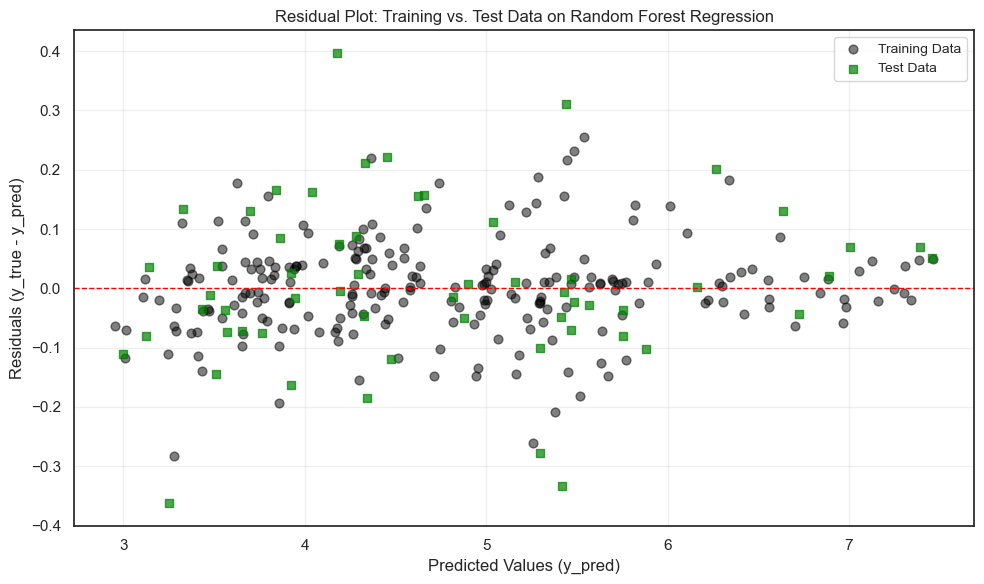

In [1835]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

#training data
plt.scatter(y_train_pred, train_residuals, 
            c='black', marker='o', 
            alpha=0.5, s=40,
            label='Training Data')

# test data 
plt.scatter(y_test_pred, test_residuals, 
            c='green', marker='s', 
            alpha=0.7, s=40,
            label='Test Data')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot: Training vs. Test Data on Random Forest Regression")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: Residual plot help to detect the quality of regression model. It shows the difference between the predicted values and the actual data.
The reiduals value falls within a range of ±0.4. The data points are scattered around zero, which is a good sign. The training data is closer to 0 than the test data point is more spread out on the residual graph. 

**Programming** train_residuals and test_residuals variables are declared to calculate the difference between actual data and predicted values.

plt.figure sets the width and height of the figure. plt.scatter is used to plot a scatterplot and takes parameters of the x-axis ('Predicted values') and y-axis ('Residuals').

c='black'sets for training data with shape of marker 'o'(circle), alpha is set as 0.5 for transparency, and s=40 for size. The label parameter names the residuals for training data.

c='green'sets for test data with shape of marker 's'(square), alpha is set as 0.7 for transparency, and s=40 for size. The label parameter names the residuals for test data.

axhline(y=0) to anchor residual analysis. color='red' draw red lines with linestyles such as dashed line. plt.title is for the title of the scatterplot. plt.xlabel() to label x-axis, plt.ylabel() to label y-axis. plt.legend() labels the residuals of training and test data. plt.grid(true) is to plot the graph with grid lines and transparency. plt.show() display the plot.                                                                                   

### **Applying GridSearchCV and Cross Vaildation on log-transformed data with default parameters**


In [1839]:
# Prepare data
X = log_tf_data[['Average Num of Nights', 'Number of trips']]  # Replace with your features
y = log_tf_data['Expenditure']  # Replace with your target variable

**Programming**: X variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'log_tf_data' dataframe.

y variable is assigned with the target feature, 'Expenditure' to predict the expenditure based on 'Number of trips'and 'Average Num of Nights'


In [1841]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((288, 2), (288,), (230, 2), (58, 2), (230,), (58,))

**Programming**: Independent and dependent features are split into training and test subsets to pre-process the data ready for machine learning.

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of the data goes to training and 20 percent of the data goes to testing.

random_state = 42 is set to reproduce the same train and test subset. 

In [1843]:
# Scale the data
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

When the maximum and min values of the data ranges are small, such as a range from 1.4 to 8, the scaling is not essential. Tuning hyperparmeters for GridSearchCV are, however, sensitive of the scale of data. Scaling needs to be performed. StandardScaler is used as the spread of log transformed data is close to normal distribution as discussed earlier in the Statistics part. 

**Programming:** standard feature scaling is used because the data distribution is slightly close to normal distribution after outlier treatment. The sc variable is called to instantiate the StandardScaler class under scikit-learn's data pre-processing module.

New variable names, 'X_train_scaled' and 'X_test_scaled', are declared to transform the independent and target features using standard scaling for X_train and X_test data.


In [1846]:
rf = RandomForestRegressor(random_state=42)

In [1847]:
param_grid = {
    'n_estimators': [100], 
    'criterion': ['squared_error'], 
    'max_depth': [None],  
    'min_samples_split': [2],  
    'min_samples_leaf': [1],  
    'max_features': [1.0],  
    'bootstrap': [True], 
    'min_impurity_decrease': [0.0]  
}

grid_search = GridSearchCV(estimator=rf, 
                          param_grid=param_grid,
                          cv=5,  
                          scoring='neg_mean_squared_error',
                          n_jobs=-1,  
                          verbose=1)

In [1848]:
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}.4f")

Best Parameters: {'bootstrap': True, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}.4f


In [1849]:
y_train_pred = grid_search.predict(X_train_scaled) 
y_test_pred = grid_search.predict(X_test_scaled) 

#Model performance
print("Random Forest Model performance after default GridSearchCV hyperparameter tuning:")
print("\n===Training Data===")
print(f"R²_train: {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE_train: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"MSE_train: {mean_squared_error(y_train, y_train_pred):.4f}")

print("\n===Test Data===")
print(f"R²_test: {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE_train: {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"MSE_test: {mean_squared_error(y_test, y_test_pred):.4f}")

Random Forest Model performance after default GridSearchCV hyperparameter tuning:

===Training Data===
R²_train: 0.9945
MAE_train: 0.0594
MSE_train: 0.0065

===Test Data===
R²_test: 0.9856
MAE_train: 0.1026
MSE_test: 0.0193


**Interpretation:** Training Data is 0.99 and test data is 0.98. The scores are close to 1. This means that overfitting issues exists. Parameter needs to be adjust to reduce overfitting

#### **Applying GridSearchCV and Cross Vaildation on log-transformed data**

It is important to generalize the model with hyperparameters because r square scoring 1 on both training and test data is rare. And, the model will be difficult to understand the unknown data.

In [1853]:
# Prepare data
X = log_tf_data[['Average Num of Nights', 'Number of trips']]  # Replace with your features
y = log_tf_data['Expenditure']  # Replace with your target variable

**Programming**: X variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'log_tf_data' dataframe. 

y variable is assigned with the target feature, 'Expenditure' to predict the expenditure based on 'Number of trips'and 'Average Num of Nights'

In [1855]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((288, 2), (288,), (230, 2), (58, 2), (230,), (58,))

**Programming**: Independent and dependent features are split into training and test subsets to pre-process the data ready for machine learning. 

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of the data goes to training and 20 percent of the data goes to testing.

random_state = 42 is set to reproduce the same train and test subset. 

In [1857]:
# Scale the data
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

When the maximum and min values of the data ranges are small, such as a range from 1.4 to 8, the scaling is not essential. Tuning hyperparmeters for GridSearchCV are, however, sensitive of the scale of data. Scaling needs to be performed. StandardScaler is used as the spread of log transformed data is close to normal distribution as discussed earlier in the Statistics part. 

**Programming**: standard feature scaling is used because the data distribution is slightly close to normal distribution after outlier treatment. The sc variable is called to instantiate the StandardScaler class under scikit-learn's data pre-processing module. 

New variable names, 'X_train_scaled' and 'X_test_scaled', are declared to transform the independent and target features using standard scaling for X_train and X_test data. 

In [1860]:
# Cross-validation 
rf = RandomForestRegressor(random_state=42)
scores = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print(f"Cross-Validation Negative MSE: {-scores.mean()}")

param_grid = {
    'n_estimators': [50, 100],           
    'max_depth': [3, 5],                 
    'min_samples_split': [20, 30],      
    'min_samples_leaf': [10, 15],        
    'max_features': ['sqrt', 0.3]        
}

# Grid search
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}.4f")

Cross-Validation Negative MSE: 0.048716418061895285
Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 100}.4f


**Interpretation**: GridSearch gives the following best parameters to reduce overfitting in the model. 

+ 'max_depth': 5
+ 'max_features': 'sqrt' 
+ 'min_samples_leaf': 10 
+ 'min_samples_split': 20
+ 'n_estimators': 100

After five-fold cross vaildation, the result of lower cross-validation negative MSE as 0.049. It means that model is good fit. 

**Programming**: rf variable is assigned to create a RandomForestRegressor function with random_state set as 4. The 'scores' variable is used to 
for accessing the function cross-validation score to ensure metric stability and optimize hyperparameters such as GridSearchCV. 

Five-fold validation is performed on the random forest regression model. X and y training data are used to conduct cross-validation, and metrics are evaluated based on negative mean squared error. 

param_grid is defined for generalization. n_estimators sets the number of trees in the forest. max_depth is used to define the maximum depth of each tree. The minimum split is to reduce overfitting. max_features is used to manage the randomness and diversity. 

grid_search is to find the best parameters in the defined param_grid. The function tunes the RandomForest Regressor model with five-fold cross-validation, and the performance metric is measured using negative mean square error for the regression problem.

In [1863]:
y_train_pred = grid_search.predict(X_train_scaled) 
y_test_pred = grid_search.predict(X_test_scaled) 

#Model performance
print("Random Forest Model performance after GridSearchCV hyperparameter tuning:")
print("\n===Training Data===")
print(f"R²_train: {r2_score(y_train, y_train_pred):.4f}")
print(f"MAE_train: {mean_absolute_error(y_train, y_train_pred):.4f}")
print(f"MSE_train: {mean_squared_error(y_train, y_train_pred):.4f}")

print("\n===Test Data===")
print(f"R²_test: {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE_train: {mean_absolute_error(y_test, y_test_pred):.4f}")
print(f"MSE_test: {mean_squared_error(y_test, y_test_pred):.4f}")

Random Forest Model performance after GridSearchCV hyperparameter tuning:

===Training Data===
R²_train: 0.9124
MAE_train: 0.2359
MSE_train: 0.1033

===Test Data===
R²_test: 0.8729
MAE_train: 0.2945
MSE_test: 0.1708


**Interpretation**: After hyperparameter tuning, the random forest machine learning model's performance improved. 

As the training data's R² score is larger than the R² score of the test, the model seems to be slightly overfitting. However, a 0.04 gap between training and test data is negligible, and a test metric above 85 percent is good. Similarly, the MAE and MSE of test data have more errors than training data. Making more adjustments to hyperparameters can reduce slight overfitting. 

**Programming**: The above code calculates the mean_absolute_error, mean_squared_errors and r2_score of training and testing data. 

The fundamental metrics are calculated to understand the model performance. 

#### Evaluating model performance with residual plots

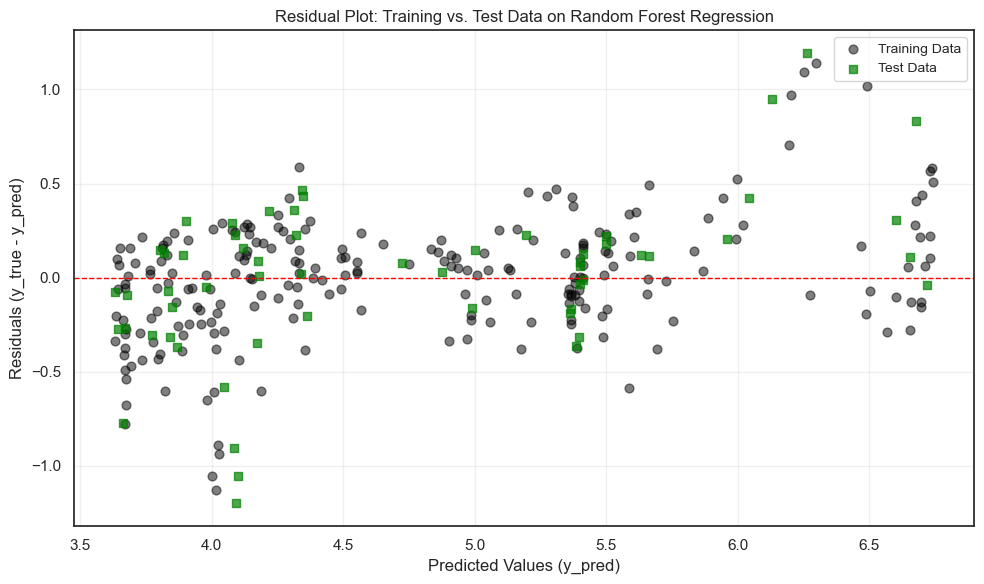

In [1867]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

#training data
plt.scatter(y_train_pred, train_residuals, 
            c='black', marker='o', 
            alpha=0.5, s=40,
            label='Training Data')

# test data 
plt.scatter(y_test_pred, test_residuals, 
            c='green', marker='s', 
            alpha=0.7, s=40,
            label='Test Data')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot: Training vs. Test Data on Random Forest Regression")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: The changes can be seen after hyperparameter tuning. The residuals fall ±1 and are more spread between 3.5 and 6.5 predicted values. 

The model performs very well when predicted values are between 3.5 and 6.0, as more residuals are randomly centered around zero. The model perform less when predicted values fall between 6.0 and 6.5. It can be due to outliers. Since the presence of outliers is significant in expenditure prediction, dropping outliers can be harmful to lose the important facts that the data holds.

**Programming** train_residuals and test_residuals variables are declared to calculate the difference between actual data and predicted values.

plt.figure sets the width and height of the figure. plt.scatter is used to plot a scatterplot and takes parameters of the x-axis ('Predicted values') and y-axis ('Residuals').

c='black'sets for training data with shape of marker 'o'(circle), alpha is set as 0.5 for transparency, and s=40 for size. The label parameter names the residuals for training data.

c='green'sets for test data with shape of marker 's'(square), alpha is set as 0.7 for transparency, and s=40 for size. The label parameter names the residuals for test data.

axhline(y=0) to anchor residual analysis. color='red' daw red lines with linestyles such as dashedline. plt.title is for the title of the scatterplot. plt.xlabel() to label x-axis, plt.ylabel() to label y-axis. plt.legend() labels the residuals of training and test data. plt.grid(true) is to plot the graph with grid lines and transparency. plt.show() display the plot.

### **Applying Linear Regression model on log transformed data using pipeline and standard scaler**

In [1871]:
X = log_tf_data[['Number of trips', 'Average Num of Nights']]  # Features
y = log_tf_data['Expenditure']  # Target

**Programming**: X variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'log_tf_data' dataframe. 

y variable is assigned with the target feature, 'Expenditure' to predict the expenditure based on 'Number of trips'and 'Average Num of Nights'

In [1873]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((288, 2), (288,), (230, 2), (58, 2), (230,), (58,))

**Programming**: Independent and dependent features are split into training and test subsets to pre-process the data ready for machine learning.

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of the data goes to training and 20 percent of the data goes to testing.

random_state = 42 is set to reproduce the same train and test set.

In [1875]:
# Create pipeline
pipe = make_pipeline(StandardScaler(),LinearRegression())

*Programming*: 'pipe' variable is created to ensure consistent preprocessing relating to scaling between training and test data and prevent leaking data.

StandardScaler is used as the spread of log transformed data is close to normal distribution, as discussed earlier in the Statistics part.

In [1877]:
pipe.fit(X_train, y_train) #fit and train the linear model

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])

In [1878]:
# Predictions
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

**Programming**: .predict() is used to generate predicitions using ElasticNet machine learning model on both training and testing data. 

In [1880]:
# Training metrics
train_mae = (mean_absolute_error(y_train, y_train_pred))
train_rmse = (mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Testing metrics
test_mae = (mean_absolute_error(y_train, y_train_pred))
test_rmse = (mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression model performance")
print("=== Training Data ===")
print(f"MAE: {train_mae:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"R² Score: {train_r2:.4f}\n")

print("=== Test Data ===")
print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R² Score: {test_r2:.4f}")

Linear Regression model performance
=== Training Data ===
MAE: 0.1790
RMSE: 0.0495
R² Score: 0.9580

=== Test Data ===
MAE: 0.1790
RMSE: 0.0434
R² Score: 0.9677


**Interpretation**: Linear regression model will predict the new data with ±0.18 euros away from the actual data. Mean absolute error of training and test are equal, which mean that model is good fit and no overfitting can be seen. 

R² Score of test data is better than R² Score of training data, both scores are a near-perfect fit. 0.97 of test data suggests that the model shows 97% of variance. RMSE scores of training and test data are close to each other. 

RMSE takes the square of absolute errors. This minor means that there may be a slight error in making a prediction between the actual and predicited values 

**Programming**: The above code calculates the mean_absolute_error, mean_squared_errors and r2_score of training and testing data. 

The fundamental metrics are calculated to understand the model's performance. 

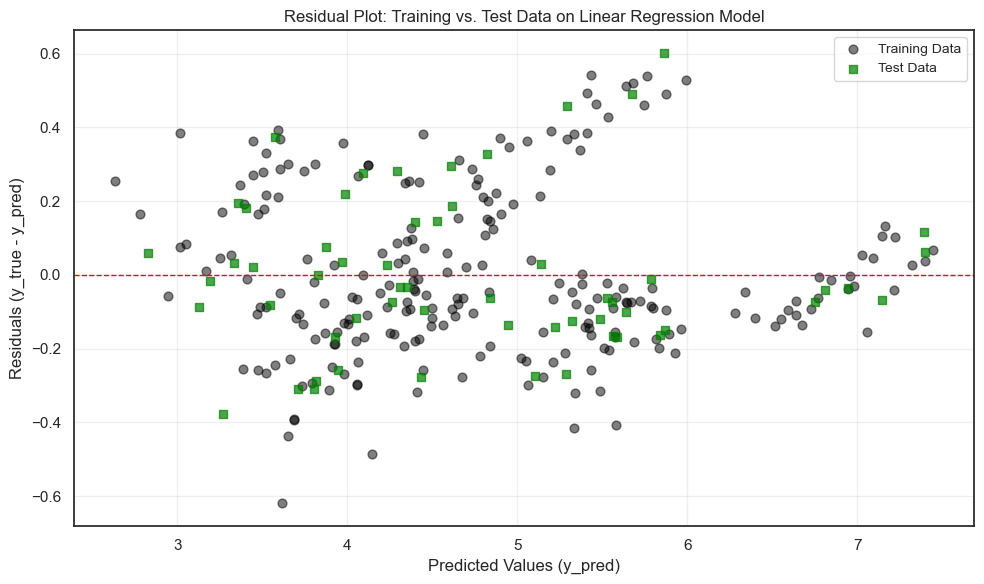

In [1883]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

#training data
plt.scatter(y_train_pred, train_residuals, 
            c='black', marker='o', 
            alpha=0.5, s=40,
            label='Training Data')

# test data 
plt.scatter(y_test_pred, test_residuals, 
            c='green', marker='s', 
            alpha=0.7, s=40,
            label='Test Data')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot: Training vs. Test Data on Linear Regression Model")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: residual values span ±0.6 and there is no significant patterns in the residuals that can be captured. 

Test data is performing well can be seen in the picture. Test data (green squares) are slightly closer to 0 than training data (black circles). Linear regression is capturing higher predicted values on both the training and test data. When predicted values fall between 3.5 and 6, the distance from zero become large. Since residual values ranges  ±0.6, the slight difference can be ignored. 

**Programming** train_residuals and test_residuals variables are declared to calculate the difference between actual data and predicted values.

plt.figure sets the width and height of the figure. plt.scatter is used to plot a scatterplot and takes parameters of the x-axis ('Predicted values') and y-axis ('Residuals').

c='black'sets for training data with shape of marker 'o'(circle), alpha is set as 0.5 for transparency, and s=40 for size. The label parameter names the residuals for training data.

c='green'sets for test data with shape of marker 's'(square), alpha is set as 0.7 for transparency, and s=40 for size. The label parameter names the residuals for test data.

axhline(y=0) to anchor residual analysis. color='red' daw red lines with linestyles such as dashedline. plt.title is for the title of the scatterplot. plt.xlabel() to label x-axis, plt.ylabel() to label y-axis. plt.legend() labels the residuals of training and test data. plt.grid(true) is to plot the graph with grid lines and transparency. plt.show() display the plot.

In [1886]:
# coefficient calculation

coefficients = pipe.named_steps['linearregression'].coef_
inter = pipe.named_steps['linearregression'].intercept_

co = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients
})

print("Feature Coefficients:")
print(co)
print(f"\nIntercept: {inter}") 


Feature Coefficients:
                 Feature  Coefficient
0        Number of trips     1.255661
1  Average Num of Nights     0.320670

Intercept: 4.794496313459667


**Interpretation**: Feature_1: 'Number of trips' is more highly correlated to target feature 'Expenditure' than 'Average Num of Nights'. This means that as the number of trips increases, the expenditure value will increase. If the number of trips decreases, the expenditure value will decrease. 

The linear regression model will predict new data strongly based on 'Number of trips' than 'Average Num of Nights'. Expenditure will be 4.8 euros when both 'Number of trips'and 'Average Num of Nights' is zero. 

**Programming**:  'coefficients' variable attempts to access the cofficient of trained Linear Regression model. 

'co'variable attempts to create a table to display the coefficient related to expenditure values. X.columns is used to access the features from X dataframe and stored as 'Feature' name as a feature. 'Coefficient 'feature stores the calculated coefficient. 

### **Applying ElasticNet Model on log transformed data without scaling features**

In [1890]:
X = log_tf_data[['Number of trips', 'Average Num of Nights']]  # Independent Features
y = log_tf_data['Expenditure']  # Target Features

**Programming**: X variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'log_tf_data' dataframe. 

y variable is assigned with the target feature, 'Expenditure' to predict the expenditure based on 'Number of trips'and 'Average Num of Nights'

In [1892]:
#Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((288, 2), (288,), (230, 2), (58, 2), (230,), (58,))

**Programming**: Independent and dependent features are split into training and test subsets to pre-process the data ready for machine learning. 

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of the data goes to training and 20 percent of the data goes to testing.

random_state = 42 is set to reproduce the same train and test subset. 

In [1894]:
# Scale the features
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)

Theoretically, when the maximum and min values of the data ranges are small, such as a range from 1.4 to 8, the scaling can be omitted.

In [1896]:
log_tf_data.max()

Area of Residence        United States and Canada
Quarter                                    2019Q4
Average Num of Nights                     2.74084
Expenditure                              7.513164
Number of trips                          8.111928
dtype: object

In [1897]:
log_tf_data.min()

Area of Residence        All Countries
Quarter                         2012Q1
Average Num of Nights         1.435085
Expenditure                   2.890372
Number of trips               3.044522
dtype: object

In [1898]:
e_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
e_net.fit(X_train, y_train)

ElasticNet(alpha=0.1, random_state=42)

**Programming**: e_net creates the condition for ElasticNet machine learning model with regularization strength, alpha = 0.1. 

random_state=42 is to produce consistent results in splitting the data. .fit() method is used to train the model with scaled training data of independent features and unscaled training data for dependent feature.

In [1900]:
# predict
y_train_pred = e_net.predict(X_train)
y_test_pred = e_net.predict(X_test)

**Programming**: .predict() is used to generate predicitions using ElasticNet machine learning model on both training and testing data. 

In [1902]:
# training set
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)

test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

**Programming**: Both training and test scores are calculated using R², mean absolute error, and mean square error functions.

R² determines the true value and y_prediction. MAE, mean absolute error, is the absolute error between predicted and actual values, while mean squared error is the mean of squared difference between actual and predicted values.

In [1904]:
score_report = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R² Score': [train_r2, test_r2],
    'MAE': [train_mae, test_mae],
    'MSE': [train_mse, test_mse]
})

**Programming**: score_report variable is created to store the calculated values of mse, mae, and R² of training and testing data.

pd.DataFrame creates a table that keeps the above-declared variables in a dictionary.

In [1906]:
print("Elastic Net Model Performance without feature scaling:")
print(score_report)

Elastic Net Model Performance without feature scaling:
  Dataset  R² Score       MAE       MSE
0   Train  0.906881  0.283417  0.109794
1    Test  0.897042  0.330493  0.138344


**Interpretation**: 0.90 R² Score in training dataset and 0.89 R² Score in test means that the model is working well with a minimum gap between the two data.. 

0.33 Euro MAE is in test, meaning that the model will predict unseen data with 0.33 euros away from the actual value. MSE test set is higher than MSE training data which is due to the higher possibility of outliers in the test data. 

In [1908]:
print("Model Coefficients:")
for i, co in enumerate(e_net.coef_):
    print(f"Feature {i+1}: {co:.4f}")
print(f"Intercept: {e_net.intercept_:.4f}")

Model Coefficients:
Feature 1: 0.7904
Feature 2: 0.0000
Intercept: 0.5146


**Interpretation**: Under the Elastic Net Model with standard scaler, the importance of Feature 2, 'Average Num of Nights' is completely ignored due to regularization. 

The higher coefficient value of Feature 1, 'Number of trips', shows that there is a very strong correlation with the target feature, 'Expenditure'. Baseline predicted expenditure is intercept, 4.7 euros, when both feature 1 and feature 2 are at zero. 

**Programming**: The model coefficient is calculated using .coef_ . Python's for loop is iterated using enumerate() which accesses index position. Each feature coefficient value related to target y is calculated. 
i+1 append the features and co: .4f return the result in four decimal places. 

.intercept_ is to calculate the base value of expenditure when both features are zero. 

#### Visualizing residual plot using matplotlib

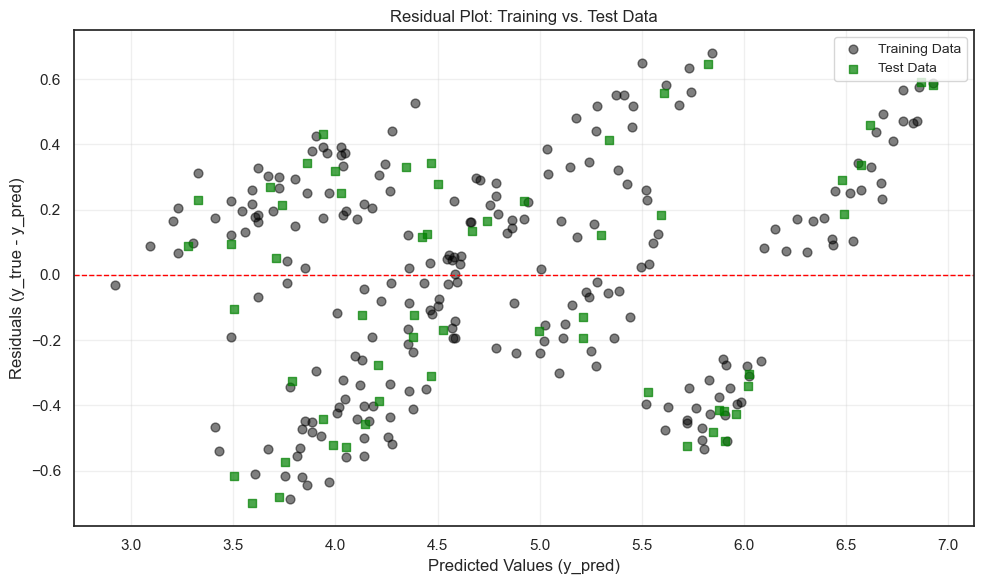

In [1912]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

#training data
plt.scatter(y_train_pred, train_residuals, 
            c='black', marker='o', 
            alpha=0.5, s=40,
            label='Training Data')

# test data 
plt.scatter(y_test_pred, test_residuals, 
            c='green', marker='s', 
            alpha=0.7, s=40,
            label='Test Data')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot: Training vs. Test Data")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: The majority of residuals from training and test data are centered around zero. The model may be missing non-linear relationship values that can be found around 6 to 7. 

The residuals for the test data appear to be slightly more spread out than the training data, particularly at higher predicted values. This could suggest mild overfitting, where the model performs better on training data than on unseen test data.

**Programming:** train_residuals and test_residuals variables are declared to calculate the difference between actual data and predicted values.

plt.figure sets the width and height of the figure. plt.scatter is used to plot a scatterplot and takes parameters of the x-axis ('Predicted values') and y-axis ('Residuals').

c='black'sets for training data with shape of marker 'o'(circle), alpha is set as 0.5 for transparency, and s=40 for size. The label parameter names the residuals for training data.

c='green'sets for test data with shape of marker 's'(square), alpha is set as 0.7 for transparency, and s=40 for size. The label parameter names the residuals for test data.

axhline(y=0) to anchor residual analysis. color='red' daw red lines with linestyles such as dashedline. plt.title is for the title of the scatterplot. plt.xlabel() to label x-axis, plt.ylabel() to label y-axis. plt.legend() labels the residuals of training and test data. plt.grid(true) is to plot the graph with grid lines and transparency. plt.show() display the plot.                                                                                   

### **Applying ElasticNet Model on log transformed data with standard scaler feature scaling**

In [1917]:
# Filtering independent variables and target feature
X2 = log_tf_data[['Number of trips', 'Average Num of Nights']]  # Features
y2 = log_tf_data['Expenditure']  # Target

**Programming**: X2 variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'cube_transform' dataframe. 

y2 variable is assigned with target feature, 'Expenditure' to predict the expenditure based on 'Number of trips'and 'Average Num of Nights'

In [1920]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

**Programming**: Independent and dependent features are split into training and test subsets to pre-proccess the data ready for machine learing. 

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of data goes to training and 20 percent of data goes to testing.

random_state = 42 is set to reproduce same train and test subset. 

In [1923]:
#Scaling the features
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

Theoretically, when the maximum and min values of the data ranges are small, such as a range from 1.4 to 8, the scaling is not essential. However, since the data is slightly close to normal distribution, the application of a standard scaler on the data significantly improved the model performance. Additionally, without scaling, larger numbers can dominate the dominates the penalty terms, leading to biased coefficient estimates.

**Programming**: standard feature scaling is used because the data has distribution is close to normal distribution post-outlier treatment. sc variable is called to instaniate the StandardScaler class under scikit-learn's data pre-processing module. 

New variable names, 'X_train_scaled' and 'X_test_scaled', are declared to transform the independent and target features using robust scaling. 

In [1927]:
log_tf_data.min()

Area of Residence        All Countries
Quarter                         2012Q1
Average Num of Nights         1.435085
Expenditure                   2.890372
Number of trips               3.044522
dtype: object

In [1929]:
log_tf_data.max()

Area of Residence        United States and Canada
Quarter                                    2019Q4
Average Num of Nights                     2.74084
Expenditure                              7.513164
Number of trips                          8.111928
dtype: object

In [1931]:
#Define the model
e_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42) 
e_net.fit(X_train_sc, y_train)

ElasticNet(alpha=0.1, random_state=42)

*Programming*: e_net creates the condition for ElasticNet machine learning model with regularization strength, alpha = 0.1 where l1_ratio is 0.5 to get equal mix between Lasso(1) and Ridge(0).  

random_state=42 is to produce consistent results in splitting the data. .fit() method is used to train the model with scaled training data of independent features and unscaled training data for dependent feature.

In [1934]:
# Make predictions
y_train_pred = e_net.predict(X_train_sc)
y_test_pred = e_net.predict(X_test_sc)

*Programming*: .predict() is used to generate predicitions using ElasticNet machine learning model on both training and testing data. 

In [1937]:
#training set
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)

#test set
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

**Programming**: Both training and test scores are calculated using r square, mean absoulte error and mean square error functions. 

R2 determines the true label and y_prediction. MAE, mean absolute error is the absolute error between predicted and actual values, while mean squared error is the mean of squared difference between actual and predicted values.

In [1940]:
score_report = pd.DataFrame({
    'Dataset': ['Train', 'Test'],
    'R² Score': [train_r2, test_r2],
    'MAE': [train_mae, test_mae],
    'MSE': [train_mse, test_mse]
})

**Programming**: score_report variable is created to store the calculated values of mse, mae, and R² of training and testing data.

pd.DataFrame creates the table that keeps the above-declared variables in a dictionary. 

In [1943]:
print("Elastic Net Model Performance on log transformed data:")
print(score_report)

Elastic Net Model Performance on log transformed data:
  Dataset  R² Score       MAE       MSE
0   Train  0.925552  0.250816  0.087780
1    Test  0.923283  0.279365  0.103084


**Interpretation**: 0.92 R² Score in testing dataset means that the model can predict 92 percent accurately on unknown data.

The tiny gap between 0.925 and 0.923 suggests that the model is generalising well and does not have overfitting issues. 

MAE training data is 0.25 euros away from the actual value, while the test data will predict 0.28 euros away from the actual value for unseen data. However, a larger MSE on the test dataset means the greater presence of outliers in the test dataset.

In [1946]:
print("Model Coefficients:")
for i, co in enumerate(e_net.coef_):
    print(f"Feature {i+1}: {co:.4f}")
print(f"Intercept: {e_net.intercept_:.4f}")

Model Coefficients:
Feature 1: 0.9985
Feature 2: 0.0905
Intercept: 4.7945


*Interpretation*: Under the Elastic Net Model with standard scaler, the importance of Feature 2, 'Average Num of Nights' is suppressed due to regularization. 

The higher coefficient value of Feature 1, 'Number of trips', shows that there is a very strong correlation with the target feature, 'Expenditure'. Baseline predicted expenditure is intercept, 4.7 euros, when both feature 1 and feature 2 are at zero. 

*Programming*: The model coefficient is calculated using .coef_ . Python's for loop is iterated using enumerate() that accesses index position. Each feature coefficient value related to target y is calculated. 
i+1 append the features and co: .4f return the result in four decimal places. 

.intercept_ is to calculate the base value of expenditure when both features are zero. 

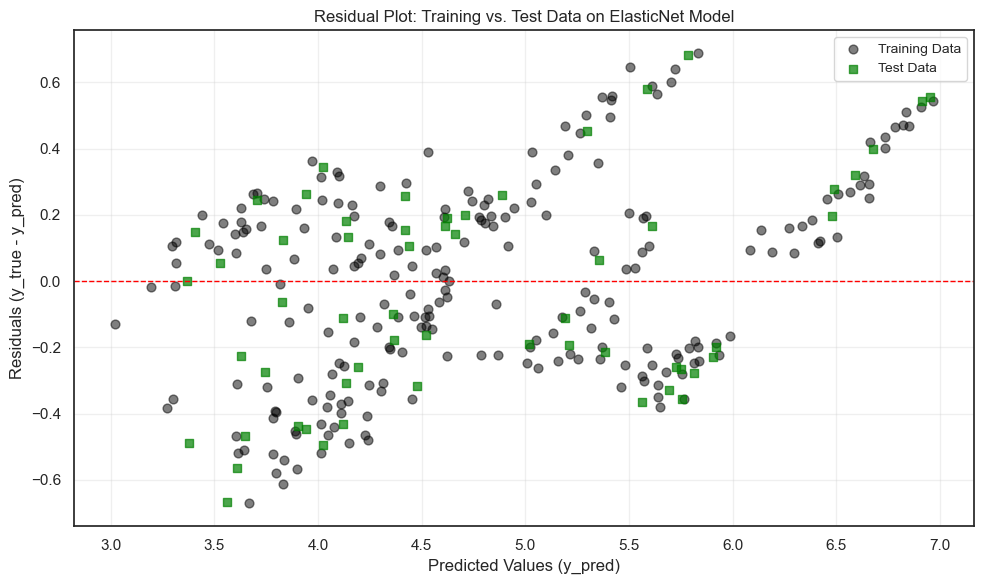

In [1950]:
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure(figsize=(10, 6))

#training data
plt.scatter(y_train_pred, train_residuals, 
            c='black', marker='o', 
            alpha=0.5, s=40,
            label='Training Data')

# test data 
plt.scatter(y_test_pred, test_residuals, 
            c='green', marker='s', 
            alpha=0.7, s=40,
            label='Test Data')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot: Training vs. Test Data on ElasticNet Model")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: The model shows the random scattering of residuals between training and test data around zero. Large errors can be seen around ±0.6. The plot shows the balanced spread of data between test and training data. 

Residuals show no patterns, and the model is not predicting data related to non-linear relationships. 

**Programming:** train_residuals and test_residuals variables are declared to calculate the difference between actual data and predicted values.

plt.figure sets the width and height of the figure. plt.scatter is used to plot a scatterplot and takes parameters of the x-axis ('Predicted values') and y-axis ('Residuals').

c='black'sets for training data with shape of marker 'o'(circle), alpha is set as 0.5 for transparency, and s=40 for size. The label parameter names the residuals for training data.

c='green'sets for test data with shape of marker 's'(square), alpha is set as 0.7 for transparency, and s=40 for size. The label parameter names the residuals for test data.

axhline(y=0) to anchor residual analysis. color='red' daw red lines with linestyles such as dashedline. plt.title is for the title of the scatterplot. plt.xlabel() to label x-axis, plt.ylabel() to label y-axis. plt.legend() labels the residuals of training and test data. plt.grid(true) is to plot the graph with grid lines and transparency. plt.show() display the plot.

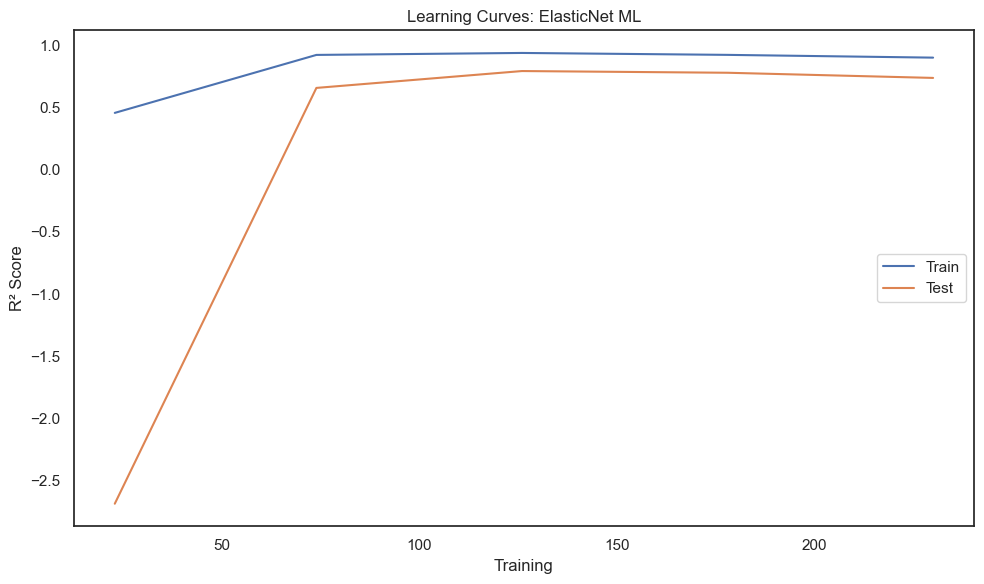

In [1954]:
from sklearn.model_selection import learning_curve
plt.figure(figsize=(10, 6))
train_sizes, train_scores, test_scores = learning_curve(e_net, X, y, cv=5)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Test')
plt.title("Learning Curves: ElasticNet ML")
plt.xlabel("Training")
plt.legend(loc='center right')
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

**Interpretation**: The blue line is the training data and the orange line is test data. The blue line is always near around 1 means that the training data is learning very well on the model.

The test data performance improved after 50, and adding more data the r square score improved and peaked at 0.5 and gradually increased around 100 training data, however remained above 0.5. 

### Cross validation assessment on ElasticNet Model

In [1958]:
scores = cross_val_score(e_net, X_train_sc, y_train, cv=5)
print(f'Cross-Validation Scores: {scores}')
print(f'Average Cross-Validation MSE: {scores.mean()}')

Cross-Validation Scores: [0.93428296 0.92429835 0.91531351 0.93614223 0.90795303]
Average Cross-Validation MSE: 0.9235980154065775


**Interpretation:** The model performance can be evaluated using cross-validation. No alarming gap between each cross-validation scores can be seen. Model may be subject to small data changes, as a 3/5 fold gives different results. 2/5 split gives similar data.

The average MSE across all cross-validation folds is 0.92 means that the model may have slightly over 9 percent error within target expenditure data range. 

### Making prediction on ElasticNet Model

In [1962]:
X = log_tf_data[['Number of trips', 'Average Num of Nights']]  # Features
y = log_tf_data['Expenditure']  # Target

make_predicition = Pipeline([
    ('scaler', StandardScaler()),  
    ('elasticnet', ElasticNet(alpha=0.1, l1_ratio=0.5))
          
])

make_predicition.fit(X_train_sc, y_train)

new_expenditure = [[1000, 8]]  # Example new data (2 features)
predictions = make_predicition.predict(new_expenditure)  # Auto-scales & transforms to 6 features
print(f"The estimated expenditure (1000 trips and 8 nights): {predictions} millions")

The estimated expenditure (1000 trips and 8 nights): [1004.05409015] millions


### **Applying Polynomial Regression model on log transformed data**

In [1965]:
# Assign the Independent and Dependent Features
X = log_tf_data[['Number of trips', 'Average Num of Nights']]  # Features
y = log_tf_data['Expenditure']  # Target

*Programming*: X variable is assigned with two independent features: 'Number of trips' and 'Average Num of Nights' from 'cube_transform' dataframe. 

y variable is assigned with the target feature, 'Expenditure', to predict the expenditure based on 'Number of trips ' and 'Average Num of Nights'

In [1968]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

*Programming*: Independent and dependent features are split into training and test subsets to pre-process the data ready for machine learning. 

train_test_split is one of the scikit-learn's functions under model_selection. The code subset into two parts: 80 percent of the data goes to training and 20 percent of data goes to testing.

random_state = 42 is set to reproduce the same train and test subset. 

In [1971]:
#Scaling the features
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

Theoretically, when the maximum and min values of the data ranges are small, such as a range from 1.4 to 8, the scaling is not essential. However, the standard and proper scaling can be beneficial to polynomial regression, unlike linear regression. Without proper scaling, unscaled features can skew the penalty applied to coefficients.

*Programming*: standard feature scaling is used because the data has distribution is close to normal distribution post-outlier treatment. 'sc' variable is called to instaniate the StandardScaler class under scikit-learn's data pre-processing module. 

New variable names, 'X_train_sc' and 'X_test_sc', are declared to transform the independent and target features using robust scaling. 

#### Model Development

In [1976]:
lin = LinearRegression()
poly = PolynomialFeatures(degree=2)

*Programming*: lin call the LinearRegression() function and poly variable is created to call the PolynomialFeatures with degree 2. Since the polynomial regression takes multiple linear regression, polynomial regression can capture non-linear relationship.

In [1979]:
X_train_poly = poly.fit_transform(X_train_sc)
X_test_poly = poly.transform(X_test_sc) 
poly.fit(X_train_poly,y_train)
lin.fit(X_train_poly,y_train)

LinearRegression()

Polynominal and linear regression models are fit together to capture non-linear relationship.

In [1982]:
y_pred_test = lin.predict(X_test_poly)
y_pred_train = lin.predict(X_train_poly)

In [1984]:
print("Polynomial Regression Model Performance:")
print("===Training Data===")
print(f"MAE_train: {mean_absolute_error(y_train,y_pred_train):.4f}")
print(f"MSE_train: {mean_squared_error(y_train,y_pred_train):.4f}")
print(f"R² Score_train: {r2_score(y_train,y_pred_train):.4f}\n")

print("===Test Data===")
print(f"MAE_test: {mean_absolute_error(y_test,y_pred_test):.4f}")
print(f"MSE_test: {mean_squared_error(y_test,y_pred_test):.4f}")
print(f"R² Score_test: {r2_score(y_test,y_pred_test):.4f}\n")

Polynomial Regression Model Performance:
===Training Data===
MAE_train: 0.1785
MSE_train: 0.0490
R² Score_train: 0.9584

===Test Data===
MAE_test: 0.1548
MSE_test: 0.0420
R² Score_test: 0.9688



**Interpretation**: Polynomial regression model will predict the new data with ±0.15 euros away from the actual data. Mean absolute error of training and test are almost equal, which means that model is a good fit and no overfitting can be seen. Test errors are lower than training.

R² Score of test data is better than R² Score of training data, both scores are a near-perfect fit. 0.97 of the test data suggests that the model shows 97% of variance. RMSE scores of training and test data are close to each other. 

RMSE takes the square of absolute errors. Test RMSE is lower than Train RMSE. It can be concluded that model perform better on unseen data. 

### Cross Validation Assessment: Assessing lucky split or not

In [1988]:
scores = cross_val_score(lin, X_train_poly, y_train, cv=5)
print(f'Cross-Validation Scores: {scores}')
print(f'Average Cross-Validation MSE: {scores.mean()}')

Cross-Validation Scores: [0.95698362 0.96190268 0.94504728 0.95852717 0.96152564]
Average Cross-Validation MSE: 0.9567972761578645


**Interpretation**: The model performance can be evaluated using cross-validation. No alarming gap between each cross-validation scores can be seen. Model may be subject to small data changes, as a 1/5 fold gives a different result.v4/5 split gives similar data. 

The average MSE across all cross-validation folds is 0.95 means that the model may have over 9 percent error within target expenditure data range. 

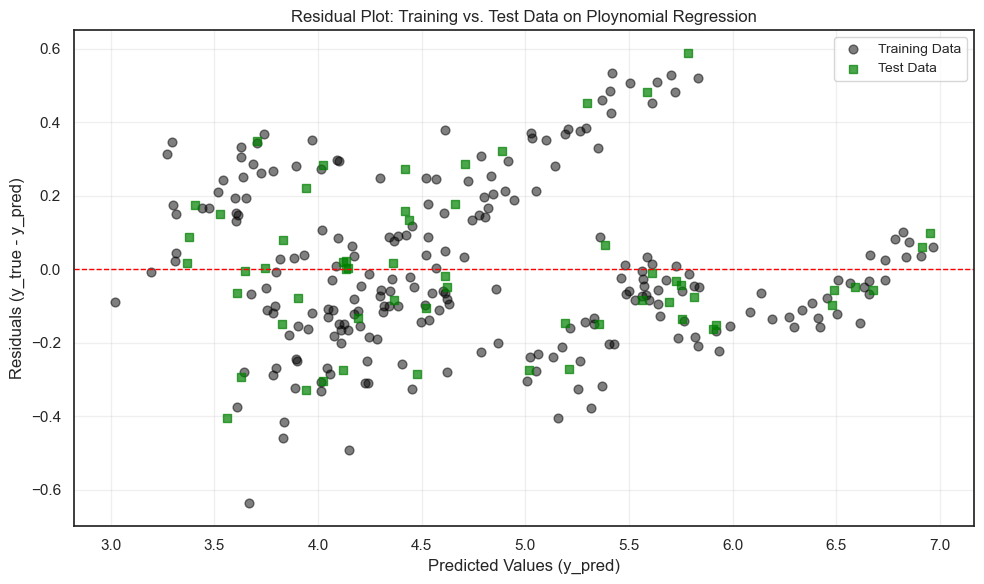

In [1991]:
train_residuals = y_train - y_pred_train
test_residuals = y_test - y_pred_test

plt.figure(figsize=(10, 6))

#training data
plt.scatter(y_train_pred, train_residuals, 
            c='black', marker='o', 
            alpha=0.5, s=40,
            label='Training Data')

# test data 
plt.scatter(y_test_pred, test_residuals, 
            c='green', marker='s', 
            alpha=0.7, s=40,
            label='Test Data')

plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel("Predicted Values (y_pred)")
plt.ylabel("Residuals (y_true - y_pred)")
plt.title("Residual Plot: Training vs. Test Data on Ploynomial Regression")
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**: residual values span ±0.6 and there is no significant patterns in the residuals that can be captured. 

Test data is performing well can be seen in the picture. Test data (green squares) are slightly closer to 0 than training data (black circles). Polynomial regression is capturing higher predicted values on both the training and test data. When predicted values fall between 3.5 and 6, the residual scores is high.  Since residual values ranges  ±0.6, the slight difference can be ignored. 

**Programming** train_residuals and test_residuals variables are declared to calculate the difference between actual data and predicted values.

plt.figure sets the width and height of the figure. plt.scatter is used to plot a scatterplot and takes parameters of the x-axis ('Predicted values') and y-axis ('Residuals').

c='black'sets for training data with shape of marker 'o'(circle), alpha is set as 0.5 for transparency, and s=40 for size. The label parameter names the residuals for training data.

c='green'sets for test data with shape of marker 's'(square), alpha is set as 0.7 for transparency, and s=40 for size. The label parameter names the residuals for test data.

axhline(y=0) to anchor residual analysis. color='red' daw red lines with linestyles such as dashedline. plt.title is for the title of the scatterplot. plt.xlabel() to label x-axis, plt.ylabel() to label y-axis. plt.legend() labels the residuals of training and test data. plt.grid(true) is to plot the graph with grid lines and transparency. plt.show() display the plot.

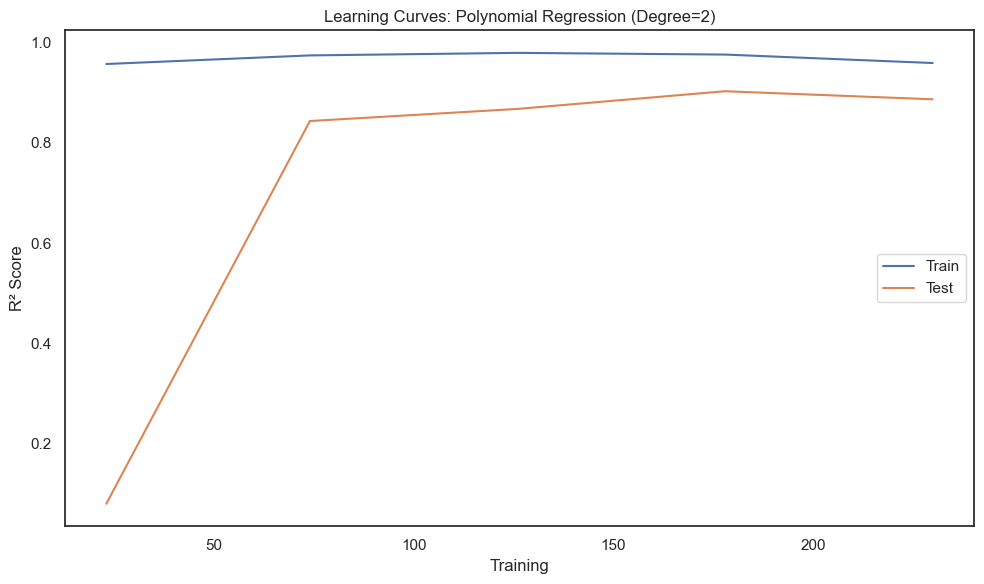

In [1995]:
from sklearn.model_selection import learning_curve
plt.figure(figsize=(10, 6))
train_sizes, train_scores, test_scores = learning_curve(lin, X, y, cv=5)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
plt.plot(train_sizes, np.mean(test_scores, axis=1), label='Test')
plt.title("Learning Curves: Polynomial Regression (Degree=2)")
plt.xlabel("Training")
plt.legend(loc='center right')
plt.ylabel("R² Score")

plt.tight_layout()
plt.show()

**Interpretation:** The blue line is the training data and the orange line is test data. The blue line is always near around 1 means that the training data is learning very well on the model. 

The test data performance improved after 50, and adding more data the r square score improved and peaked at 0.88 and it slightly dropped, however remained above 0.8. This means that test data is performing well and understanding new data. 

### Making prediction on Polynomial Feature

In [1999]:
X = log_tf_data[['Number of trips', 'Average Num of Nights']]  # Features
y = log_tf_data['Expenditure']  # Target

make_predicition = Pipeline([
    ('scaler', StandardScaler()),        
    ('poly', PolynomialFeatures(degree=2)),  
    ('linear', LinearRegression())       
])

make_predicition.fit(X_train, y_train)

new_expenditure = [[1000, 8]]  # Example new data (2 features)
predictions = make_predicition.predict(new_expenditure)  # Auto-scales & transforms to 6 features
print(f"The estimated expenditure (1000 trips and 8 nights): {predictions} millions")

The estimated expenditure (1000 trips and 8 nights): [581.19862878] millions


## **Conclusion**

Among three models, polynomial regression performed the best. The model seems to catch both linear and non-linear relationship. Although RandomForest Regressor after applying GridSearchCV and using pipeline in Linear Regression is good, the test performance seems to lower than training data which is likely to be error prone in test when more data are added. 